# Fractal — part 1 of 8

This notebook was automatically split from a larger notebook.

# Higuchi Fractal Dimension

<div style="font-size: 13px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; flex-wrap: nowrap; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="flex: 1; margin-right: 10px;">
        <h2>Introduction</h2>
        <p>
            This code calculates the Higuchi Fractal Dimension (HFD) of EEG signals for multiple channels.
            Fractal dimensions are used to quantify the complexity of a data series, which is particularly useful in neuroscience for understanding the complexity of brain activity.
        </p>
    </div>
    <!-- Column 2 -->
    <div style="flex: 1; margin-left: 10px;">
        <p>
            The code uses the Higuchi Fractal Dimension algorithm, which is computationally efficient and particularly useful for analyzing time series data. It works by evaluating the length of the curve created by the data points at different scales.
        </p>
        \[
        L_k = \frac{N-1}{\left\lfloor \frac{N-m}{k} \right\rfloor k} \sum_{m=0}^{k-1} \left[ \sum_{i=1}^{\left\lfloor \frac{N-m}{k} \right\rfloor} \left| x[m+i \cdot k] - x[m+i \cdot k - k] \right| \right]
        \]
        \[
        HFD = \frac{\log(L_{k2}/L_{k1})}{\log(k2/k1)}
        \]
        <p>
            Here, \( L_k \) is the length of the curve for a given \( k \) (delay or time offset). \( N \) is the length of the data, \( x \) is the time series data, and \( m \) is the initial time point for each \( k \).
        </p>
        <p>
            Finally, the HFD values for each channel are stored in the list <code>hfd_values</code>.
        </p>
    </div>
</div>


Running Higuchi FD in FAST mode
k_max=8, decimate=2, max_samples=60000
Loaded EEG segment: 106944 samples x 32 channels
Segment: [814.571, 921.515] sec
After FAST mode preprocessing:
  Segment shape: 53472 samples x 32 channels
  Effective sampling rate: 500.00 Hz
  Effective duration: 106.94 sec

Higuchi Fractal Dimensions:
   channel  higuchi_fd
0      CP2    2.137240
1      CP1    2.132699
2       Pz    2.123431
3       Cz    2.123212
4       C4    2.115203
5      FC2    2.113607
6      FC1    2.109976
7       C3    2.106099
8       P4    2.104325
9       P3    2.100115
10      F4    2.095759
11      Fz    2.093466
12     FC6    2.092513
13     POz    2.078851
14      Oz    2.076733
15      O1    2.074586
16      F8    2.073830
17      F3    2.068764
18     FC5    2.063035
19      T8    2.060701
20     CP6    2.058392
21      O2    2.058183
22     Fpz    2.057143
23     Fp2    2.053003
24     CP5    2.050337
25      M1    2.047045
26      F7    2.044079
27     Fp1    2.038040
28   

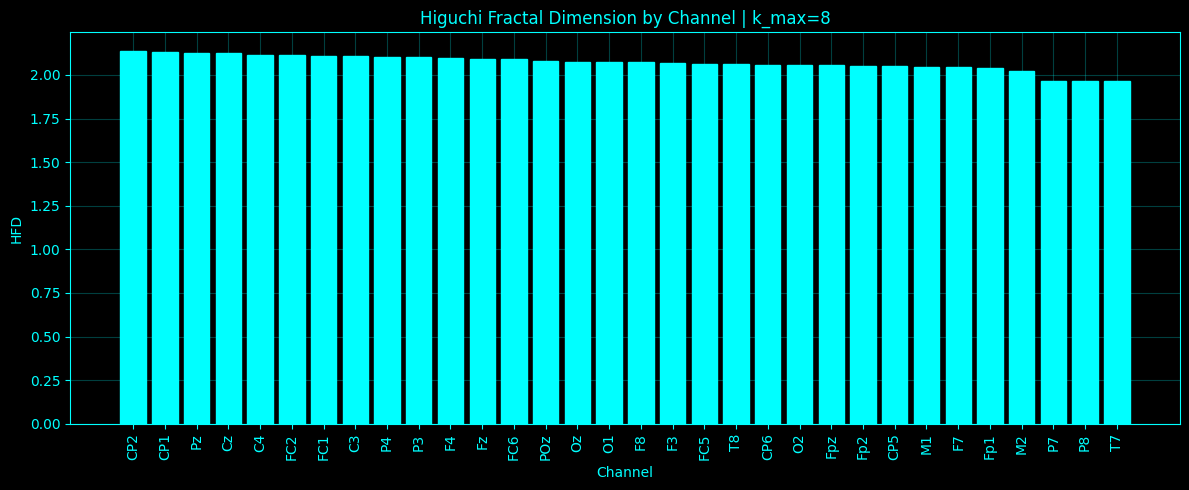

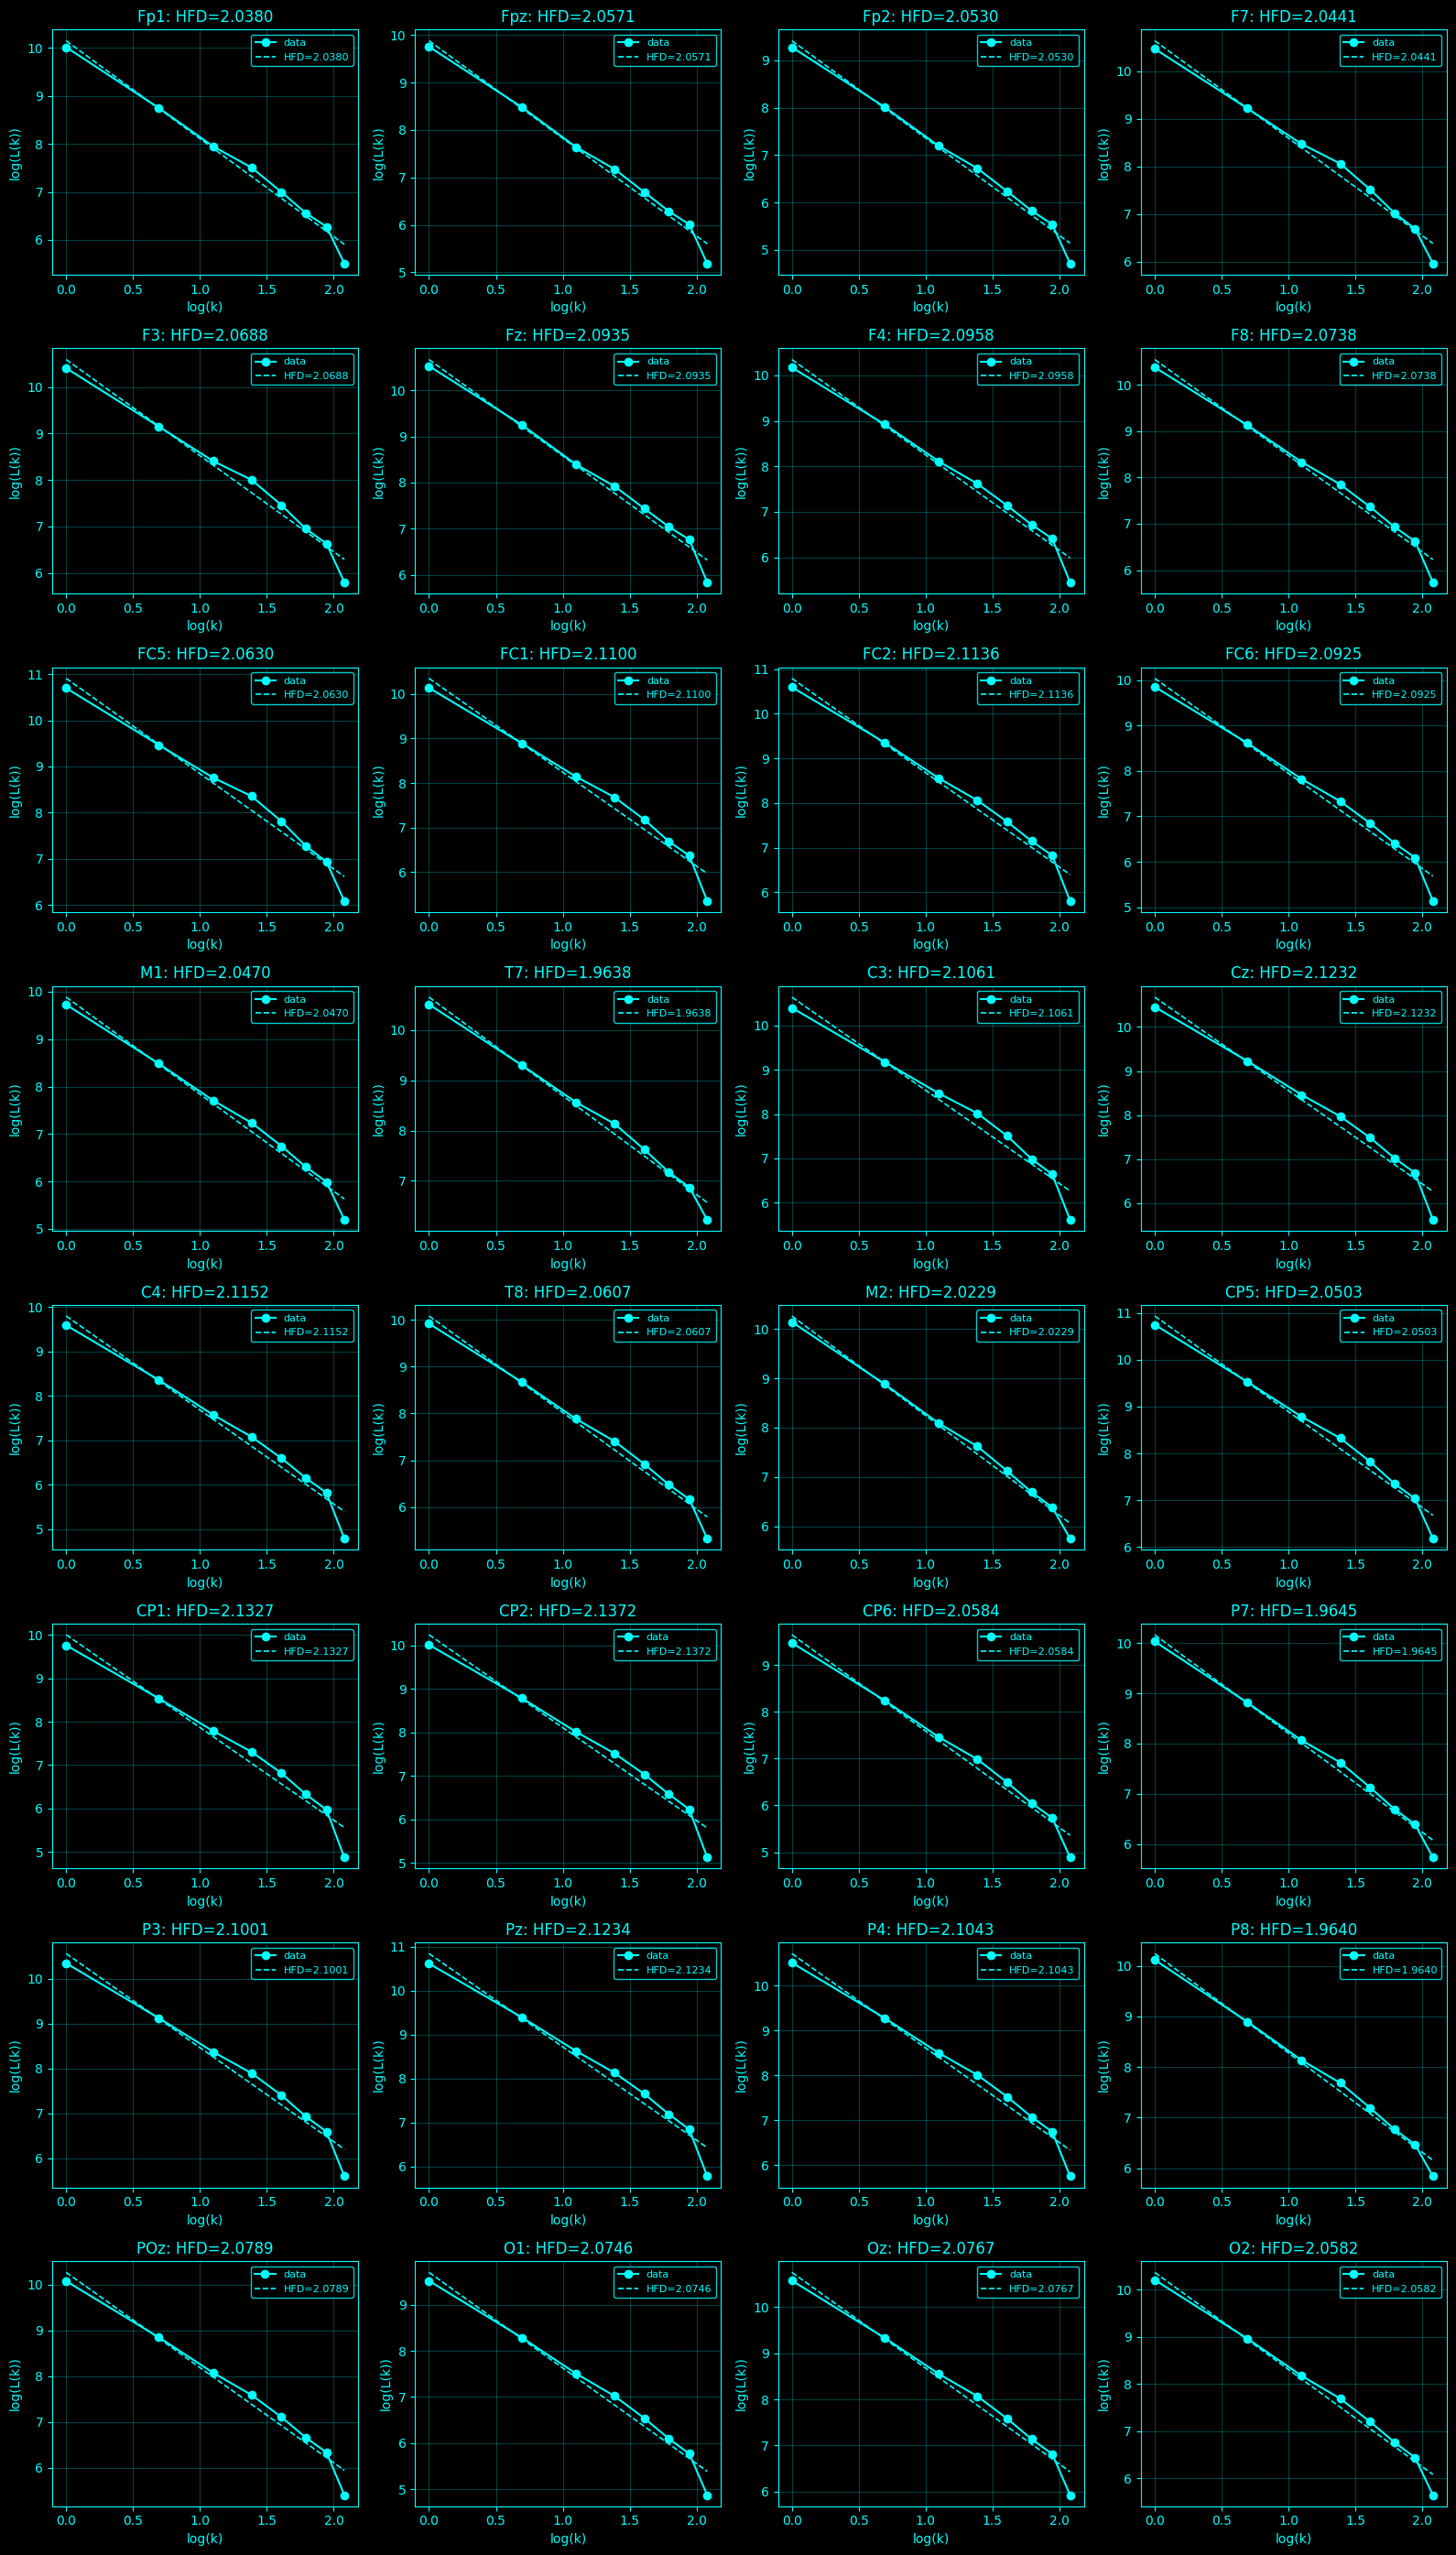

All-channel Higuchi fit plot saved to: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_higuchi/all_channels_higuchi_fits.png


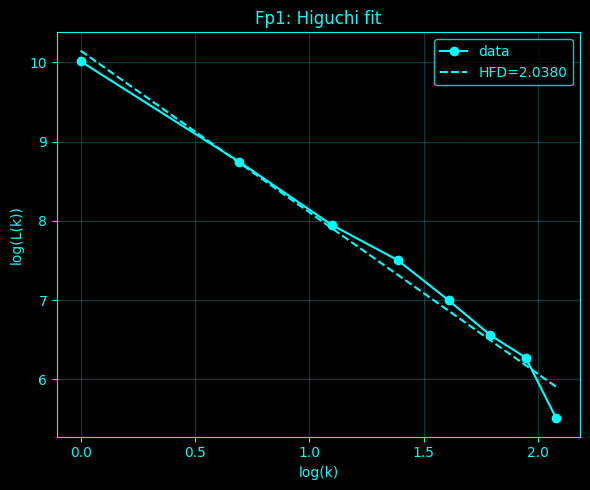

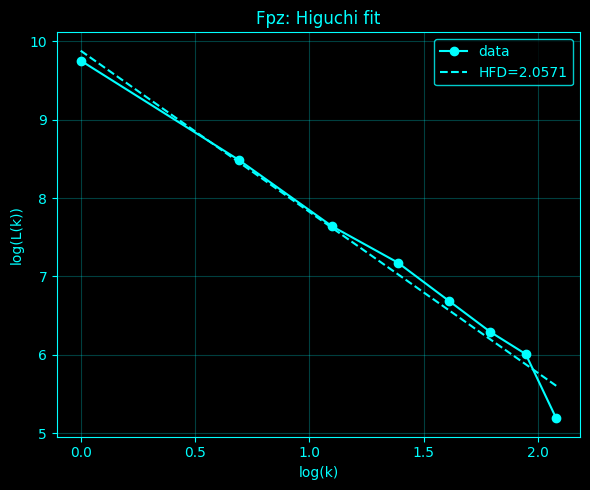

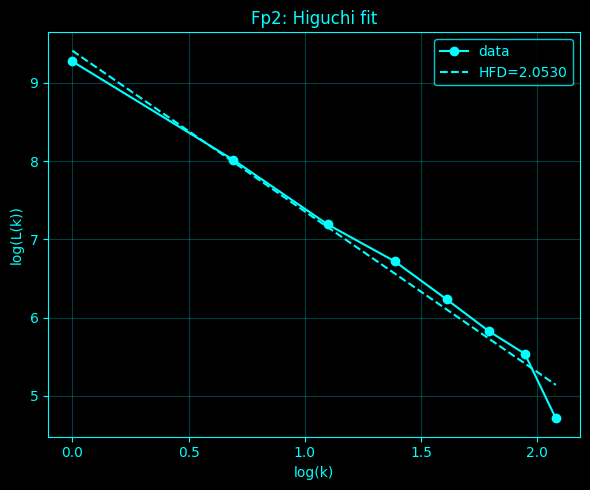

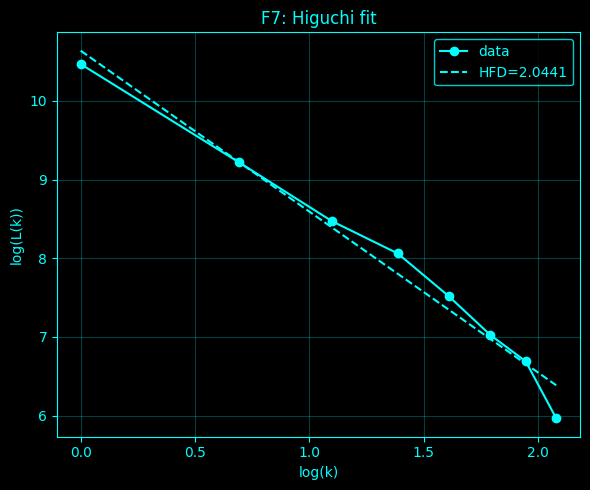

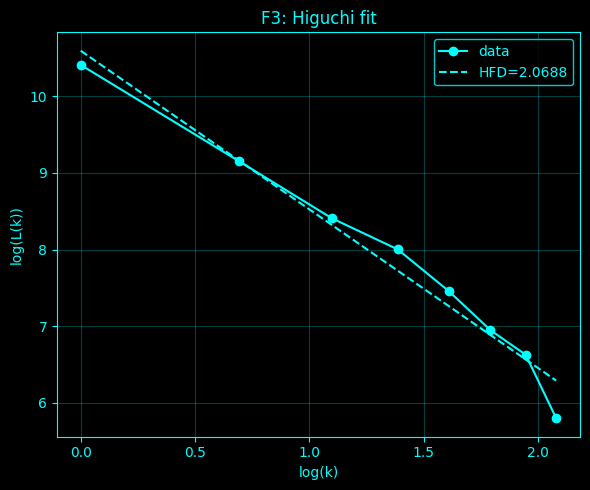

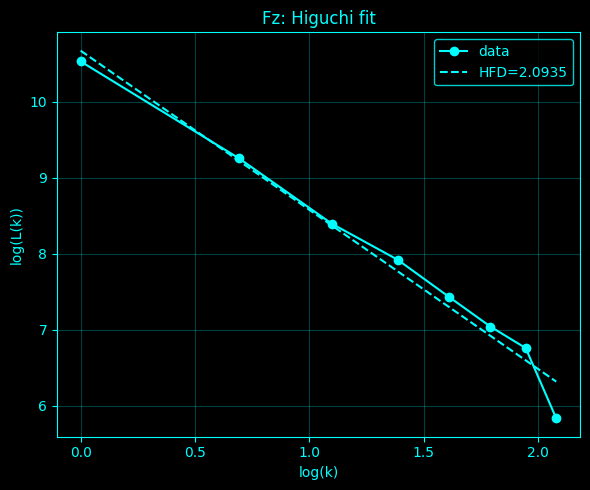

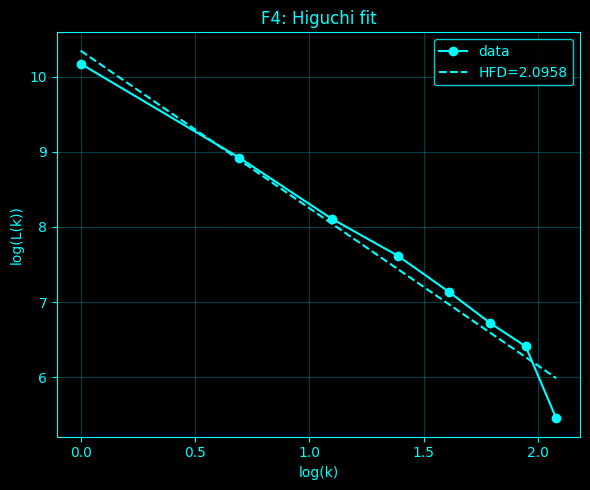

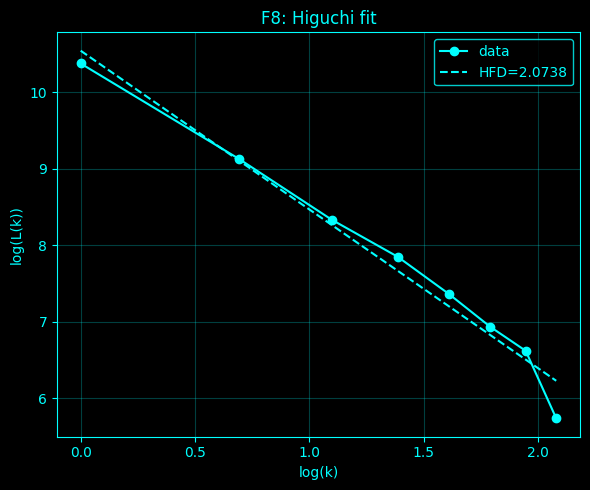

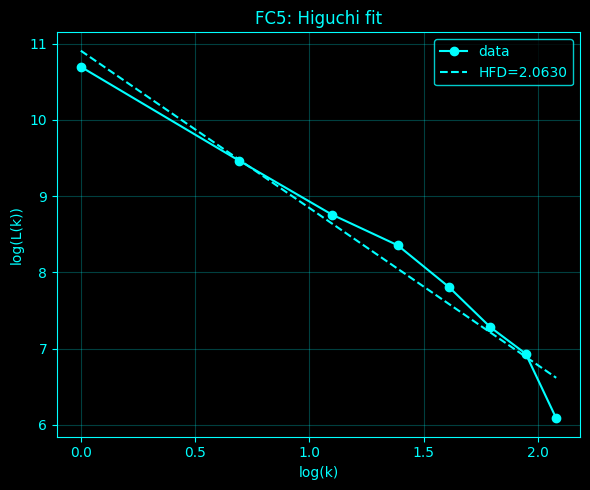

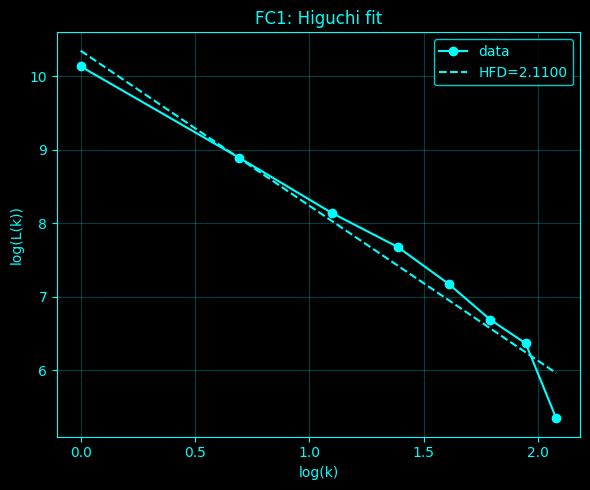

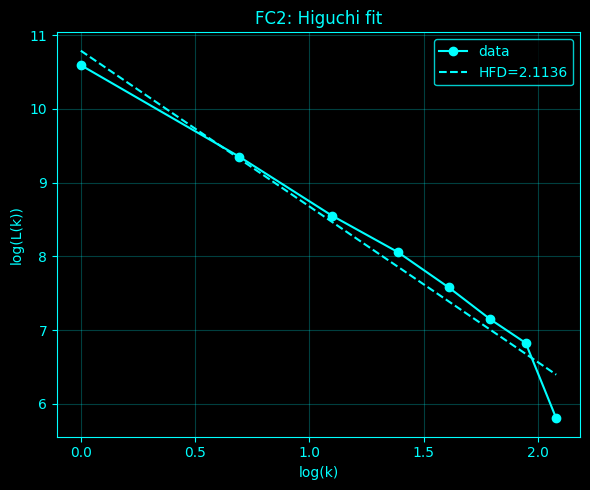

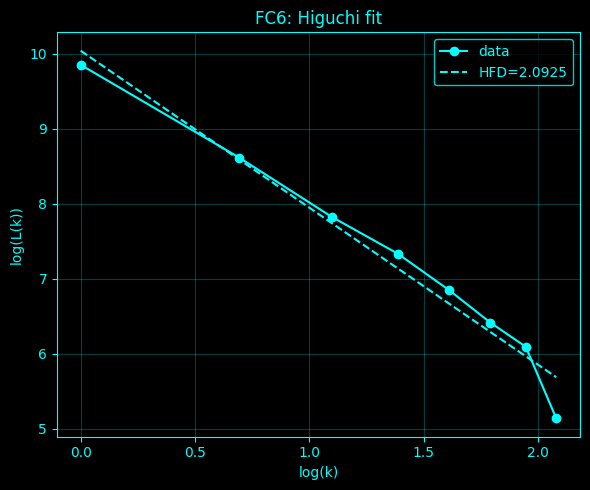

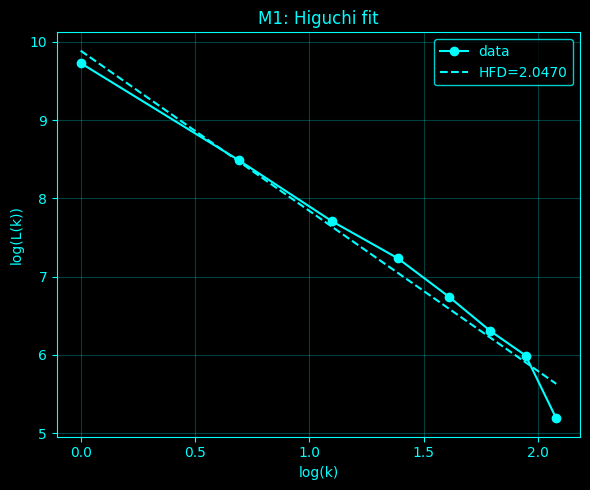

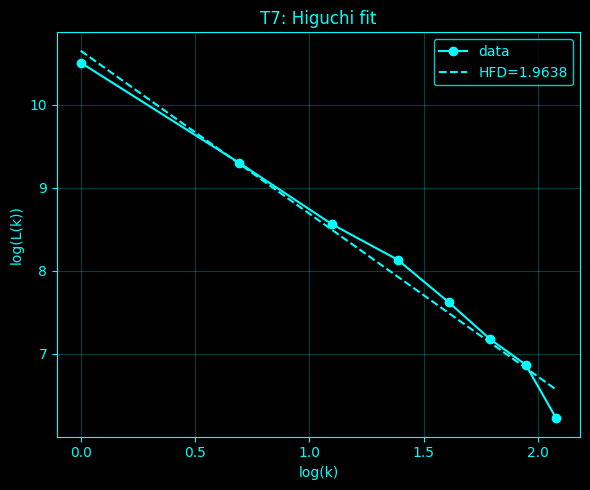

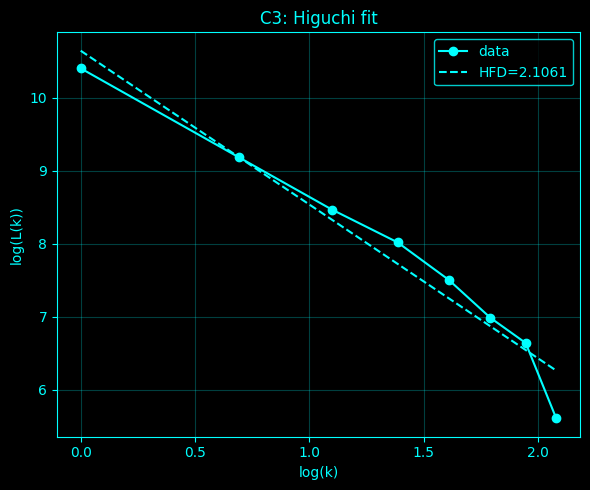

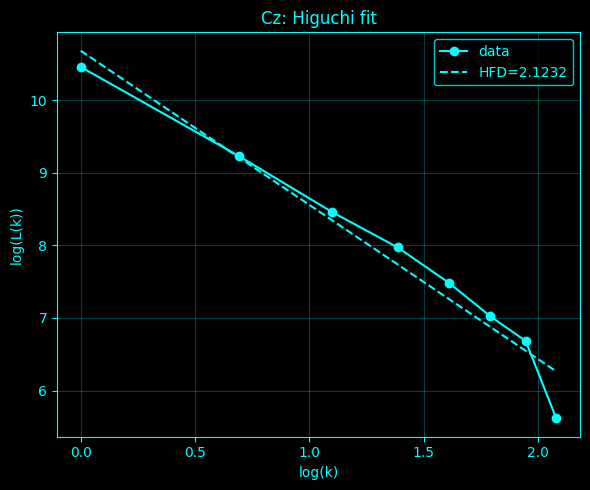

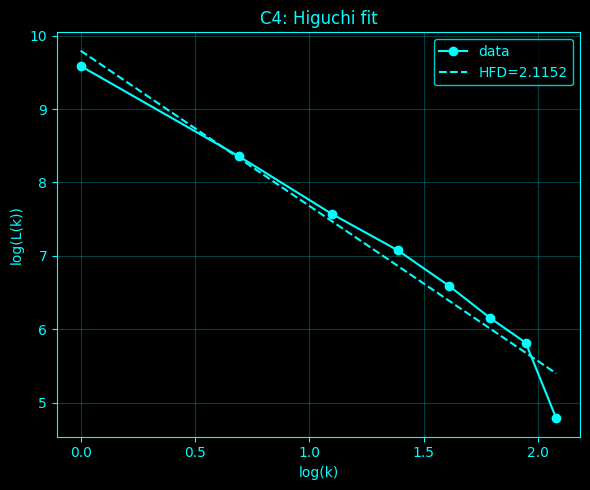

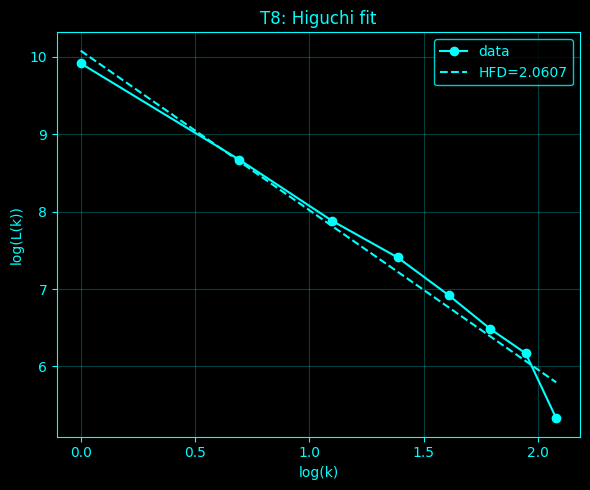

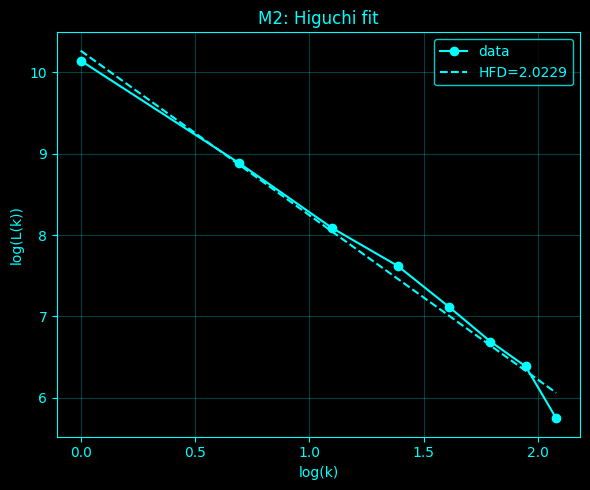

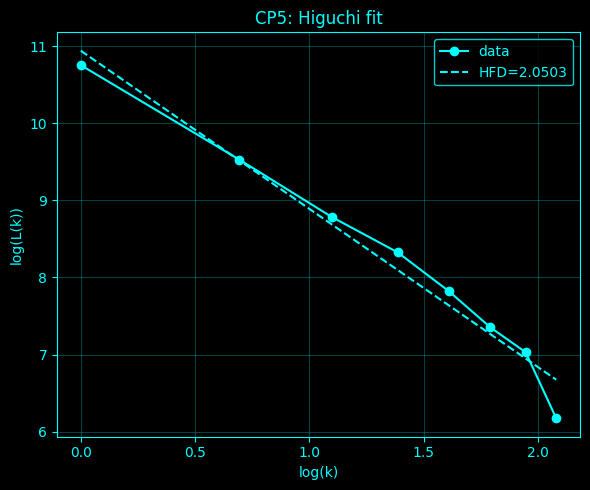

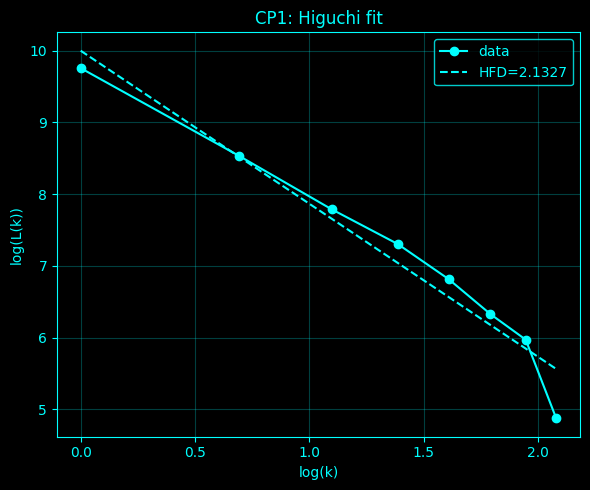

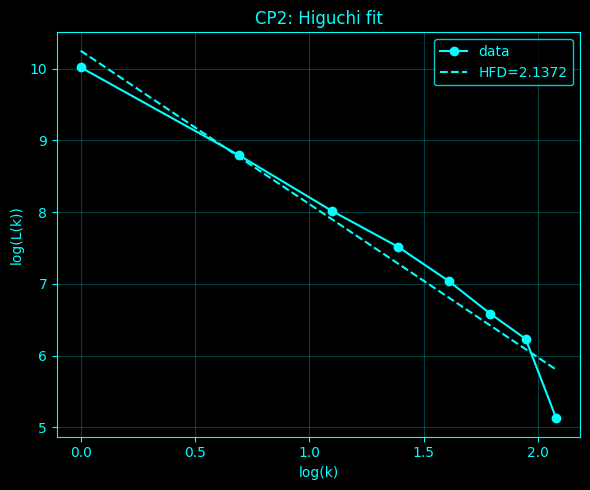

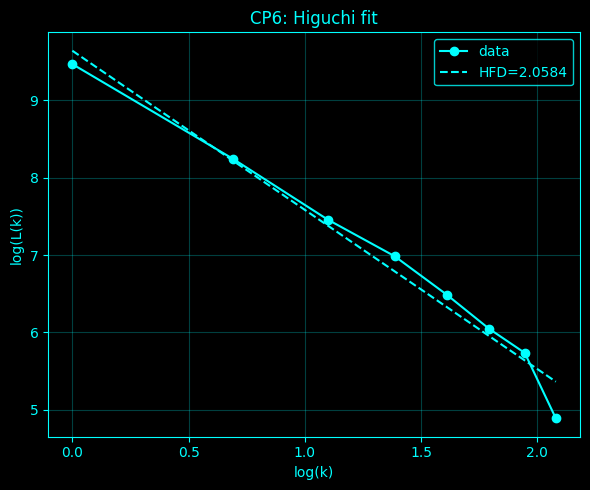

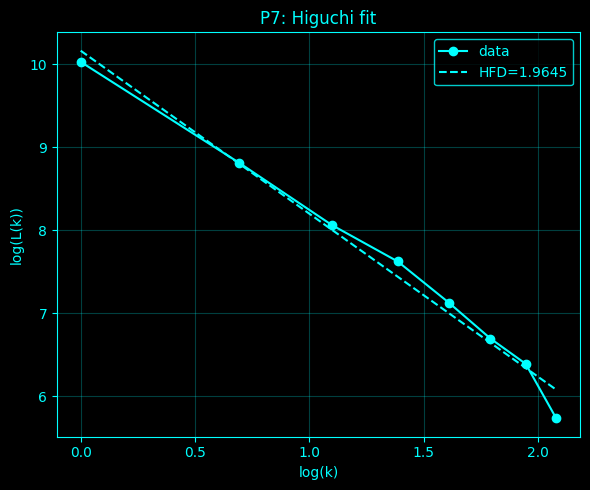

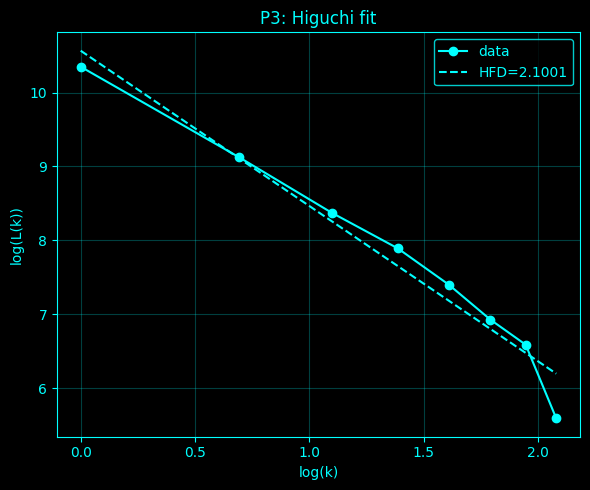

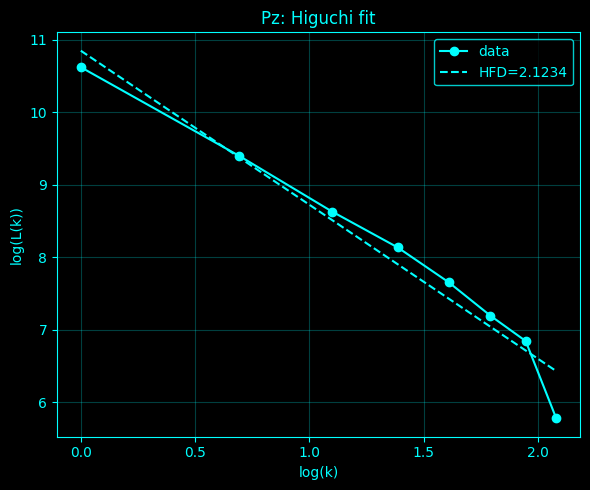

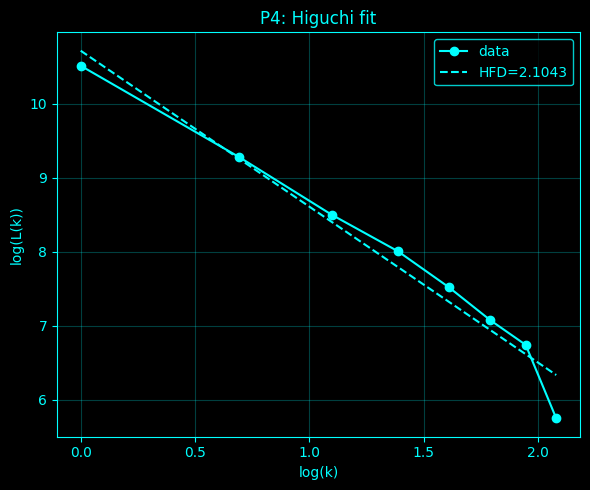

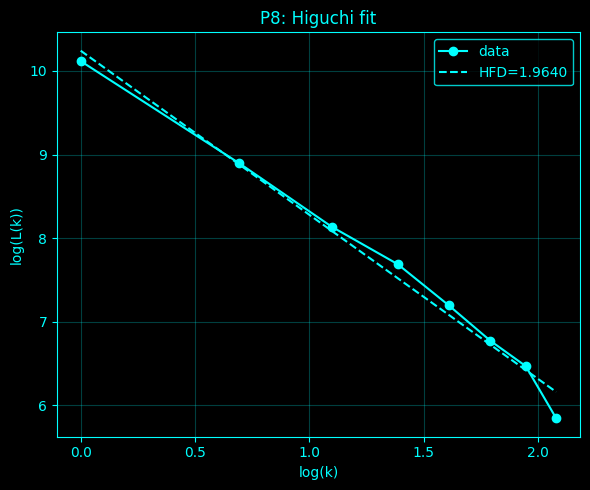

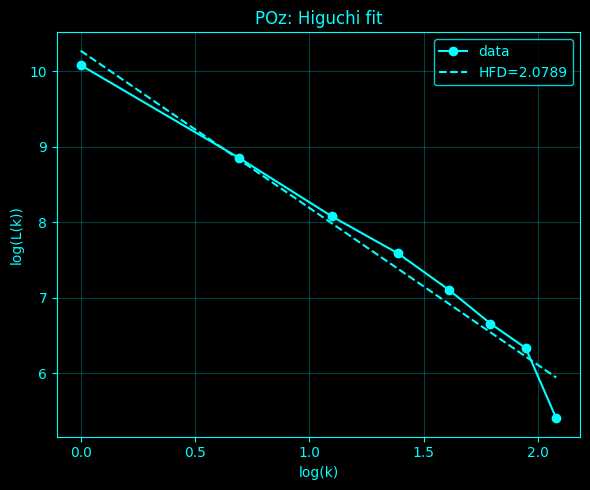

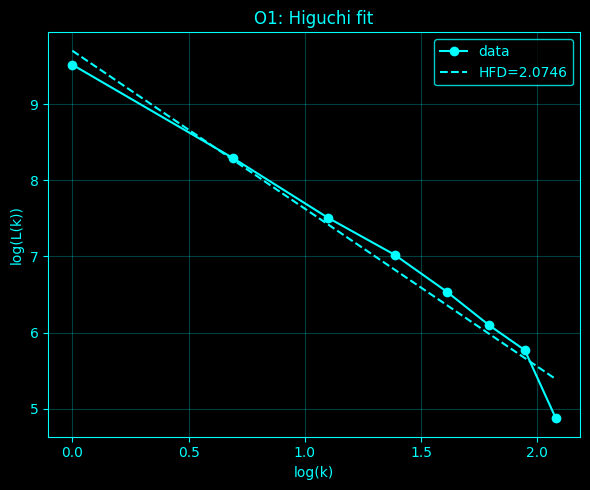

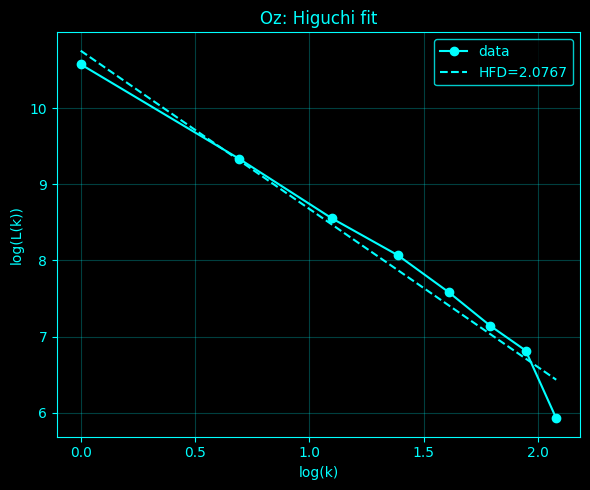

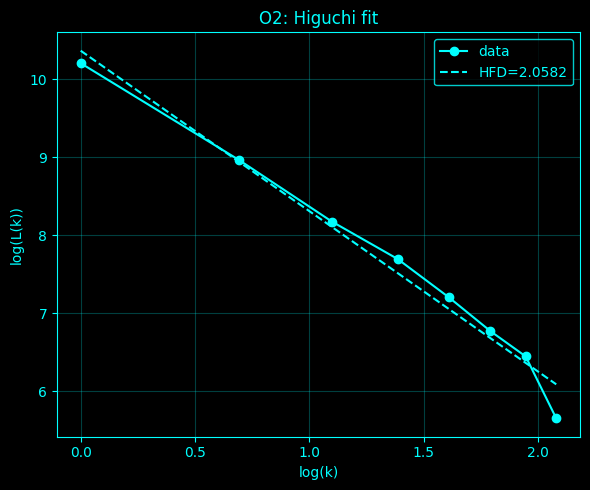

Per-channel Higuchi fit plots saved to: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_higuchi/per_channel_higuchi_fits


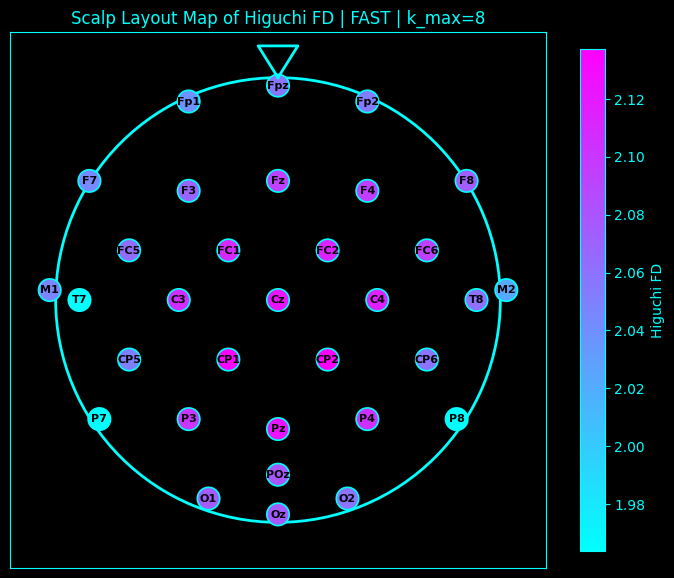

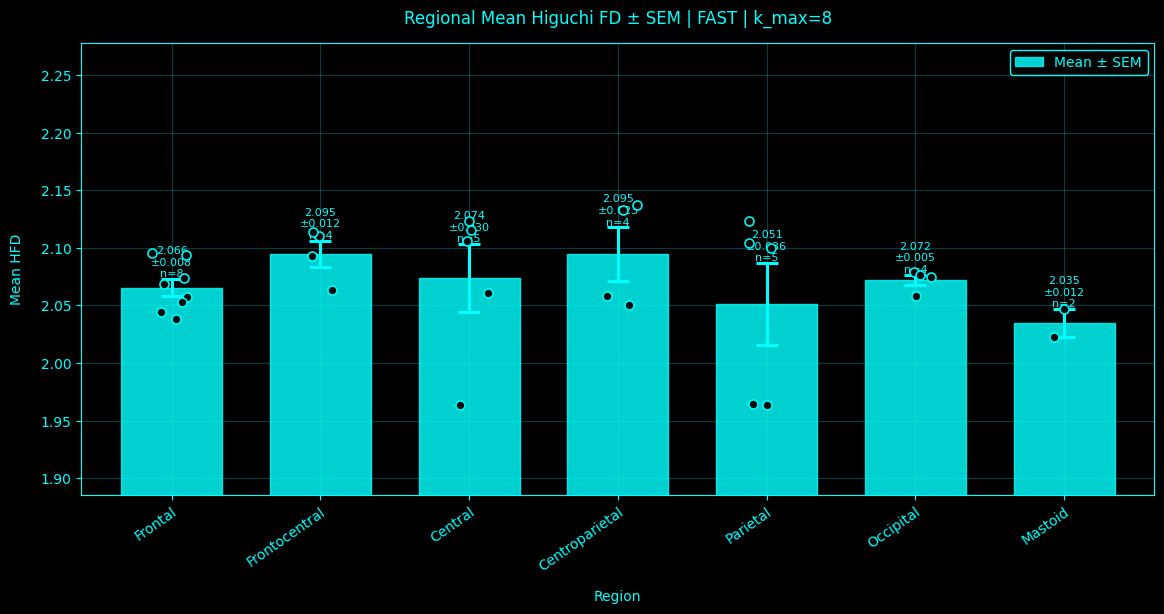

Regional summary plot saved to: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_higuchi/expert_plots_fast/regional_higuchi_fd_summary.png
Regional summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_higuchi/expert_plots_fast/regional_higuchi_fd_summary.csv
Regional channel-point CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_higuchi/expert_plots_fast/regional_higuchi_fd_channel_points.csv


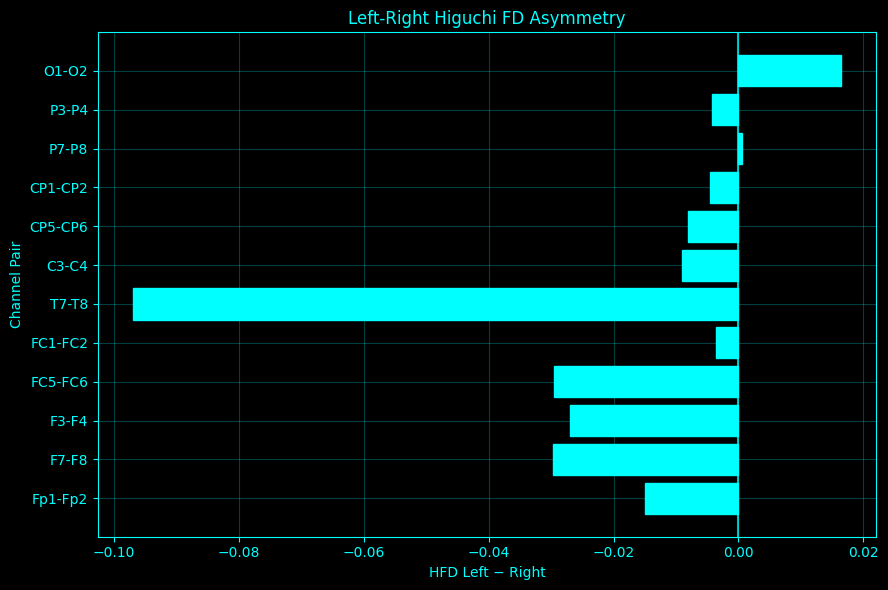

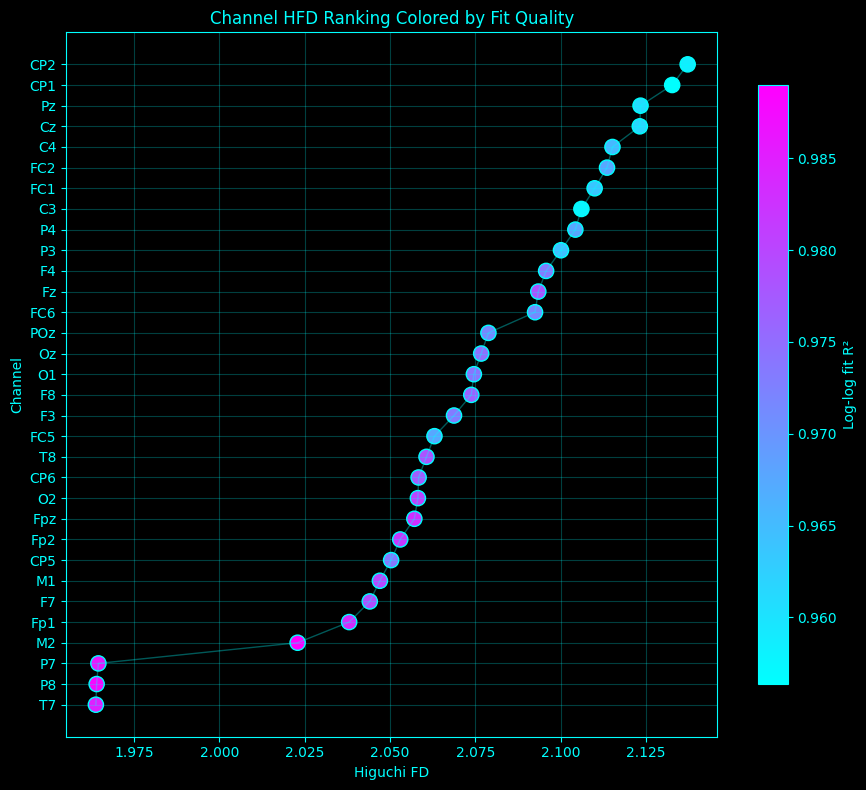

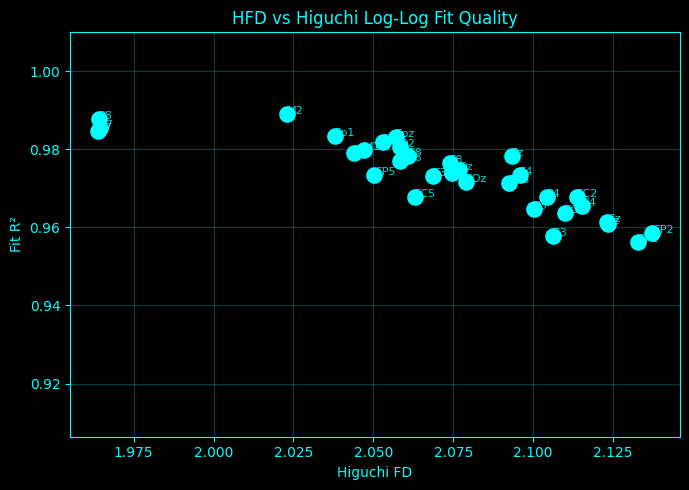

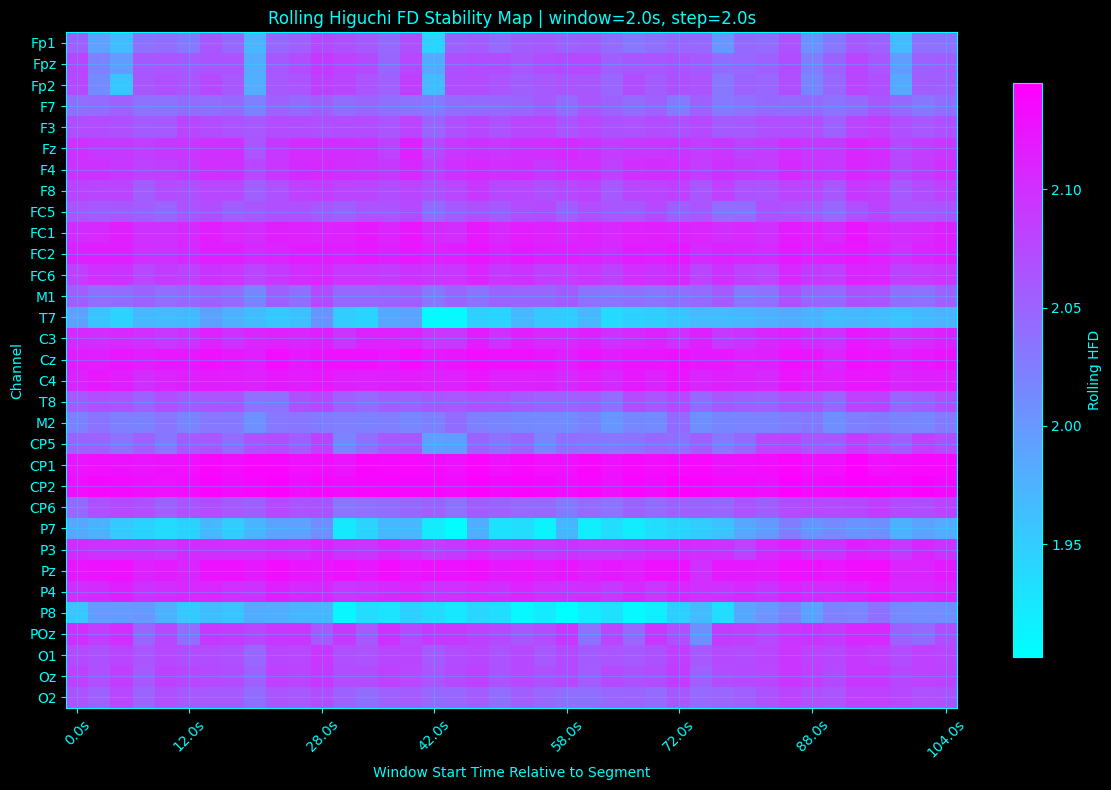

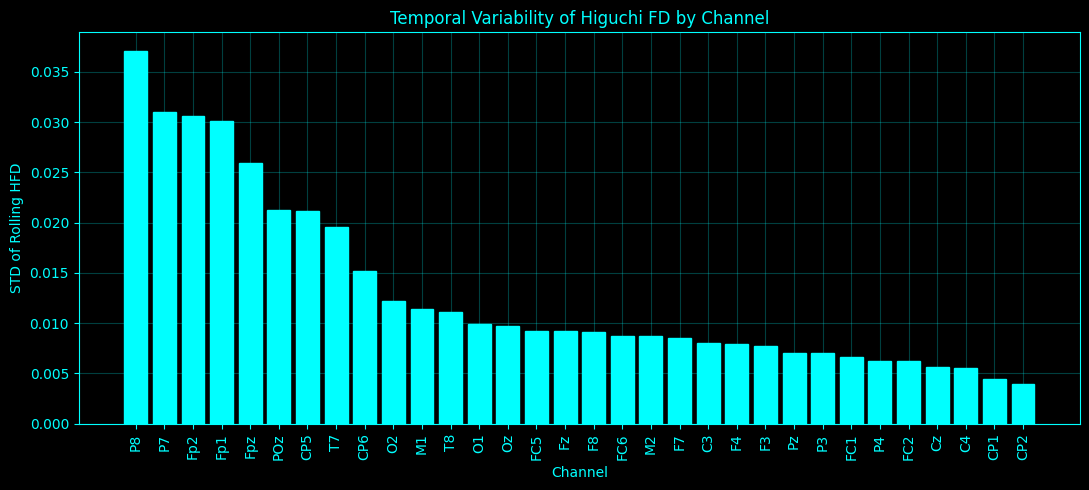

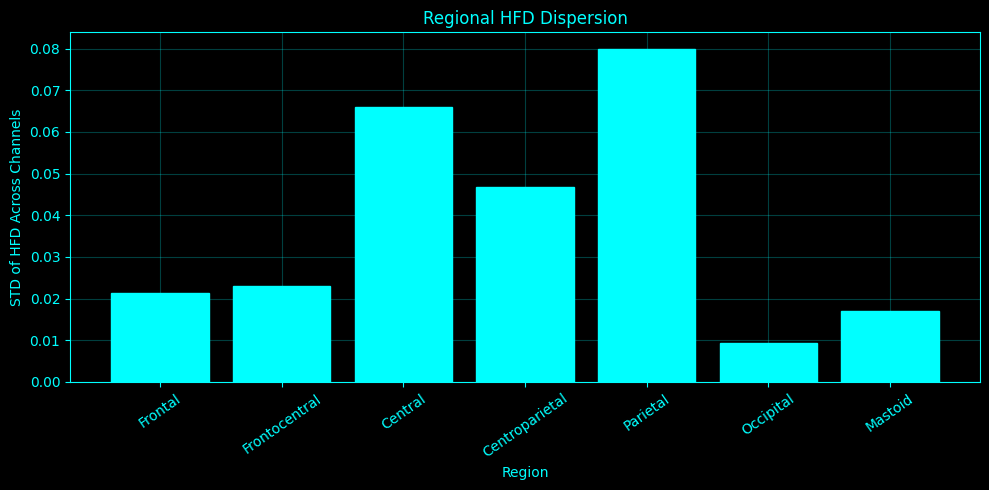

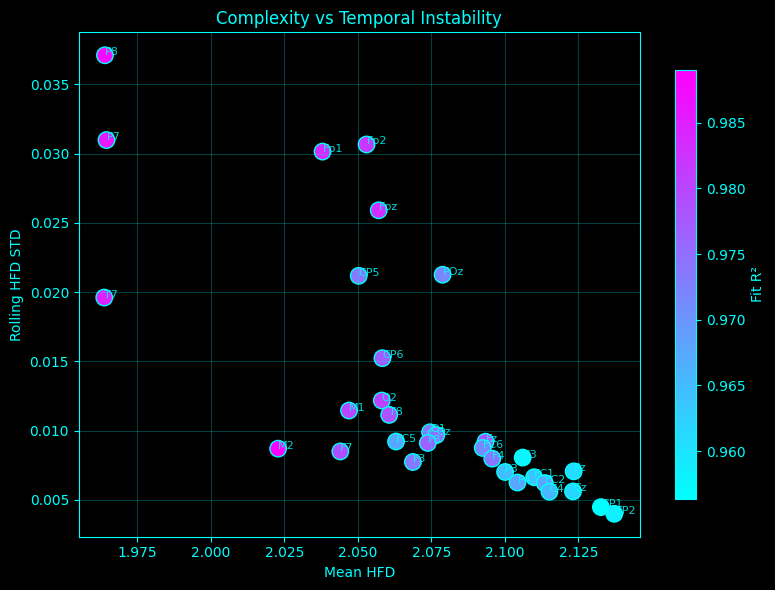


Expert plots saved to: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_higuchi/expert_plots_fast
Regional summary: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_higuchi/expert_plots_fast/regional_higuchi_fd_summary.csv
Asymmetry CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_higuchi/expert_plots_fast/left_right_higuchi_fd_asymmetry.csv
Rolling HFD CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_higuchi/expert_plots_fast/rolling_higuchi_fd_by_channel.csv
Temporal variability CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_higuchi/expert_plots_fast/rolling_higuchi_fd_temporal_variability.csv

Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_higuchi
Summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_higuchi/higuchi_fd_summary.csv
Fit diagnostics CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimens

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
out_dir = os.path.join(base_dir, "fractal_dimension_higuchi")
os.makedirs(out_dir, exist_ok=True)

# Same segment used in your recent analyses
sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_idx = int(start_time * sampling_rate)
end_idx   = int(end_time * sampling_rate)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# -------------------------------------------------------
# SPEED MODE
# -------------------------------------------------------
# Options:
#   "normal"    = highest fidelity
#   "fast"      = faster, mild downsampling/truncation
#   "ultrafast" = fastest exploratory scan
MODE = "fast"

MODE_CONFIGS = {
    "normal": {
        "k_max": 10,
        "decimate": 1,
        "max_samples": None,
        "rolling_window_sec": 2.0,
        "rolling_step_sec": 1.0,
        "rolling_max_windows": 80,
        "expert_plots": True,
    },
    "fast": {
        "k_max": 8,
        "decimate": 2,
        "max_samples": 60000,
        "rolling_window_sec": 2.0,
        "rolling_step_sec": 2.0,
        "rolling_max_windows": 40,
        "expert_plots": True,
    },
    "ultrafast": {
        "k_max": 6,
        "decimate": 5,
        "max_samples": 20000,
        "rolling_window_sec": 1.0,
        "rolling_step_sec": 3.0,
        "rolling_max_windows": 18,
        "expert_plots": True,
    },
}

if MODE not in MODE_CONFIGS:
    raise ValueError(f"Unknown MODE={MODE}. Use one of: {list(MODE_CONFIGS)}")

mode_cfg = MODE_CONFIGS[MODE]

k_max = mode_cfg["k_max"]
decimate = mode_cfg["decimate"]
max_samples = mode_cfg["max_samples"]

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

print(f"\nRunning Higuchi FD in {MODE.upper()} mode")
print(f"k_max={k_max}, decimate={decimate}, max_samples={max_samples}")

# -------------------------------------------------------
# STYLE HELPER
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.25, color=ACCENT)
    ax.tick_params(colors=ACCENT)

    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# LOAD EEG
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)

if EEG_data.ndim != 2:
    raise ValueError(f"Expected 2D EEG array, got shape {EEG_data.shape}")

# Handle either (time, channels) or (channels, time)
if EEG_data.shape[1] == len(eeg_channels):
    EEG_segment = EEG_data[start_idx:end_idx, :]
elif EEG_data.shape[0] == len(eeg_channels):
    EEG_segment = EEG_data[:, start_idx:end_idx].T
else:
    raise ValueError(f"Unexpected EEG shape: {EEG_data.shape}")

n_time, n_channels = EEG_segment.shape
print(f"Loaded EEG segment: {n_time} samples x {n_channels} channels")
print(f"Segment: [{start_time}, {end_time}] sec")

# -------------------------------------------------------
# APPLY SPEED MODE PREPROCESSING
# -------------------------------------------------------
effective_sampling_rate = sampling_rate

if decimate > 1:
    EEG_segment = EEG_segment[::decimate, :]
    effective_sampling_rate = sampling_rate / decimate

if max_samples is not None and EEG_segment.shape[0] > max_samples:
    EEG_segment = EEG_segment[:max_samples, :]

n_time, n_channels = EEG_segment.shape

print(f"After {MODE.upper()} mode preprocessing:")
print(f"  Segment shape: {n_time} samples x {n_channels} channels")
print(f"  Effective sampling rate: {effective_sampling_rate:.2f} Hz")
print(f"  Effective duration: {n_time / effective_sampling_rate:.2f} sec")

# -------------------------------------------------------
# HIGUCHI FRACTAL DIMENSION
# -------------------------------------------------------
def higuchi_fd(x, k_max=10):
    """
    Compute Higuchi Fractal Dimension for a 1D time series.

    Notes:
    L(k) ~ k^{-D}
    so if we fit log(L(k)) vs log(k), then D = -slope
    """
    x = np.asarray(x, dtype=float)
    N = len(x)

    if N < k_max + 2:
        return np.nan, None, None

    Lk = []
    k_vals = np.arange(1, k_max + 1)

    for k in k_vals:
        Lm_vals = []

        for m in range(k):
            n_max = (N - m - 1) // k

            if n_max < 1:
                continue

            idx1 = m + np.arange(1, n_max + 1) * k
            idx0 = m + np.arange(0, n_max) * k

            diffs = np.abs(x[idx1] - x[idx0]).sum()

            # Standard Higuchi normalization
            Lmk = diffs * (N - 1) / (n_max * k * k)
            Lm_vals.append(Lmk)

        if len(Lm_vals) == 0:
            Lk.append(np.nan)
        else:
            Lk.append(np.mean(Lm_vals))

    Lk = np.asarray(Lk, dtype=float)

    mask = np.isfinite(Lk) & (Lk > 0)

    if np.sum(mask) < 2:
        return np.nan, k_vals, Lk

    slope = np.polyfit(np.log(k_vals[mask]), np.log(Lk[mask]), 1)[0]
    hfd = -slope

    return hfd, k_vals, Lk

# -------------------------------------------------------
# FIT DIAGNOSTICS HELPER
# -------------------------------------------------------
def higuchi_fit_diagnostics(k_vals, Lk):
    """
    Returns slope, intercept, HFD, R², RMSE for log-log Higuchi fit.
    """
    if k_vals is None or Lk is None:
        return {
            "slope": np.nan,
            "intercept": np.nan,
            "hfd": np.nan,
            "r2": np.nan,
            "rmse": np.nan,
        }

    mask = np.isfinite(Lk) & (Lk > 0)

    if np.sum(mask) < 2:
        return {
            "slope": np.nan,
            "intercept": np.nan,
            "hfd": np.nan,
            "r2": np.nan,
            "rmse": np.nan,
        }

    logk = np.log(k_vals[mask])
    logL = np.log(Lk[mask])

    slope, intercept = np.polyfit(logk, logL, 1)
    pred = slope * logk + intercept

    resid = logL - pred
    ss_res = np.sum(resid ** 2)
    ss_tot = np.sum((logL - np.mean(logL)) ** 2)

    r2 = 1.0 - ss_res / (ss_tot + 1e-12)
    rmse = np.sqrt(np.mean(resid ** 2))
    hfd = -slope

    return {
        "slope": slope,
        "intercept": intercept,
        "hfd": hfd,
        "r2": r2,
        "rmse": rmse,
    }

# -------------------------------------------------------
# RUN HFD PER CHANNEL
# -------------------------------------------------------
rows = []
curves = {}

for ch_idx, ch_name in enumerate(eeg_channels):
    x = EEG_segment[:, ch_idx].astype(float)
    x = (x - np.mean(x)) / (np.std(x) + 1e-12)

    hfd, k_vals, Lk = higuchi_fd(x, k_max=k_max)

    rows.append({
        "channel": ch_name,
        "higuchi_fd": hfd
    })

    curves[ch_name] = {
        "k_vals": k_vals,
        "Lk": Lk
    }

results_df = (
    pd.DataFrame(rows)
    .sort_values("higuchi_fd", ascending=False)
    .reset_index(drop=True)
)

csv_path = os.path.join(out_dir, "higuchi_fd_summary.csv")
results_df.to_csv(csv_path, index=False)

print("\nHiguchi Fractal Dimensions:")
print(results_df)

# -------------------------------------------------------
# EXPERT DIAGNOSTIC TABLE
# -------------------------------------------------------
fit_rows = []

for ch_name in eeg_channels:
    d = curves[ch_name]
    diag = higuchi_fit_diagnostics(d["k_vals"], d["Lk"])

    fit_rows.append({
        "channel": ch_name,
        "higuchi_fd": diag["hfd"],
        "fit_slope": diag["slope"],
        "fit_intercept": diag["intercept"],
        "fit_r2": diag["r2"],
        "fit_rmse": diag["rmse"],
    })

fit_df = pd.DataFrame(fit_rows)

fit_csv_path = os.path.join(out_dir, "higuchi_fd_fit_diagnostics.csv")
fit_df.to_csv(fit_csv_path, index=False)

print(f"\nFit diagnostics CSV: {fit_csv_path}")

# -------------------------------------------------------
# PLOT 1: BAR PLOT OF HFD BY CHANNEL
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
style_ax(ax)

ax.bar(
    results_df["channel"],
    results_df["higuchi_fd"],
    color=ACCENT,
    edgecolor=ACCENT
)

ax.set_title(f"Higuchi Fractal Dimension by Channel | k_max={k_max}")
ax.set_xlabel("Channel")
ax.set_ylabel("HFD")
ax.tick_params(axis="x", rotation=90)

bar_path = os.path.join(out_dir, "higuchi_fd_barplot.png")
plt.tight_layout()
plt.savefig(bar_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 2: LOG-L(k) FIT FOR ALL CHANNELS
# -------------------------------------------------------
n_cols = 4
n_rows = int(np.ceil(len(eeg_channels) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 3.5 * n_rows),
    facecolor=BG
)

axes = axes.flatten()

for ax_idx, ch_name in enumerate(eeg_channels):
    ax = axes[ax_idx]
    style_ax(ax)

    if ch_name not in curves or curves[ch_name]["k_vals"] is None:
        ax.set_title(f"{ch_name}: no data")
        ax.axis("off")
        continue

    k_vals = curves[ch_name]["k_vals"]
    Lk = curves[ch_name]["Lk"]

    mask = np.isfinite(Lk) & (Lk > 0)

    if np.sum(mask) < 2:
        ax.set_title(f"{ch_name}: insufficient data")
        ax.axis("off")
        continue

    logk = np.log(k_vals[mask])
    logL = np.log(Lk[mask])

    slope, intercept = np.polyfit(logk, logL, 1)
    fit_line = slope * logk + intercept
    hfd = -slope

    ax.plot(
        logk,
        logL,
        marker="o",
        color=ACCENT,
        markerfacecolor=ACCENT,
        markeredgecolor=ACCENT,
        linewidth=1.5,
        label="data"
    )

    ax.plot(
        logk,
        fit_line,
        color=ACCENT,
        linestyle="--",
        linewidth=1.2,
        label=f"HFD={hfd:.4f}"
    )

    ax.set_title(f"{ch_name}: HFD={hfd:.4f}")
    ax.set_xlabel("log(k)")
    ax.set_ylabel("log(L(k))")
    ax.legend(fontsize=8)

# Turn off unused axes if any
for j in range(len(eeg_channels), len(axes)):
    axes[j].axis("off")

all_fits_path = os.path.join(out_dir, "all_channels_higuchi_fits.png")
plt.tight_layout()
plt.savefig(all_fits_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

print(f"All-channel Higuchi fit plot saved to: {all_fits_path}")

# -------------------------------------------------------
# OPTIONAL: SAVE ONE FIT PLOT PER CHANNEL
# -------------------------------------------------------
per_channel_dir = os.path.join(out_dir, "per_channel_higuchi_fits")
os.makedirs(per_channel_dir, exist_ok=True)

for ch_name in eeg_channels:
    if ch_name not in curves or curves[ch_name]["k_vals"] is None:
        continue

    k_vals = curves[ch_name]["k_vals"]
    Lk = curves[ch_name]["Lk"]

    mask = np.isfinite(Lk) & (Lk > 0)

    if np.sum(mask) < 2:
        continue

    logk = np.log(k_vals[mask])
    logL = np.log(Lk[mask])

    slope, intercept = np.polyfit(logk, logL, 1)
    fit_line = slope * logk + intercept
    hfd = -slope

    fig, ax = plt.subplots(figsize=(6, 5), facecolor=BG)
    style_ax(ax)

    ax.plot(
        logk,
        logL,
        marker="o",
        color=ACCENT,
        markerfacecolor=ACCENT,
        markeredgecolor=ACCENT,
        label="data"
    )

    ax.plot(
        logk,
        fit_line,
        color=ACCENT,
        linestyle="--",
        label=f"HFD={hfd:.4f}"
    )

    ax.set_title(f"{ch_name}: Higuchi fit")
    ax.set_xlabel("log(k)")
    ax.set_ylabel("log(L(k))")
    ax.legend()

    fit_path = os.path.join(per_channel_dir, f"{ch_name}_higuchi_fit.png")
    plt.tight_layout()
    plt.savefig(fit_path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close()

print(f"Per-channel Higuchi fit plots saved to: {per_channel_dir}")

# -------------------------------------------------------
# SAVE ALL CURVES
# -------------------------------------------------------
npz_path = os.path.join(out_dir, "higuchi_fd_curves.npz")

save_dict = {}

for ch_name, d in curves.items():
    if d["k_vals"] is not None:
        save_dict[f"{ch_name}_k_vals"] = d["k_vals"]
        save_dict[f"{ch_name}_Lk"] = d["Lk"]

np.savez(npz_path, **save_dict)

# -------------------------------------------------------
# EXPERT-LEVEL ADDITIONAL PLOTS
# Existing plots above are unchanged.
# -------------------------------------------------------
if mode_cfg["expert_plots"]:

    expert_dir = os.path.join(out_dir, f"expert_plots_{MODE}")
    os.makedirs(expert_dir, exist_ok=True)

    hfd_map = dict(zip(results_df["channel"], results_df["higuchi_fd"]))

    # ---------------------------------------------------
    # PLOT 3: SCALP-LAYOUT HFD MAP
    # ---------------------------------------------------
    scalp_xy = {
        "Fp1": (-0.45, 1.00), "Fpz": (0.00, 1.08), "Fp2": (0.45, 1.00),
        "F7": (-0.95, 0.60), "F3": (-0.45, 0.55), "Fz": (0.00, 0.60),
        "F4": (0.45, 0.55), "F8": (0.95, 0.60),

        "FC5": (-0.75, 0.25), "FC1": (-0.25, 0.25),
        "FC2": (0.25, 0.25), "FC6": (0.75, 0.25),

        "M1": (-1.15, 0.05), "T7": (-1.00, 0.00), "C3": (-0.50, 0.00),
        "Cz": (0.00, 0.00), "C4": (0.50, 0.00), "T8": (1.00, 0.00),
        "M2": (1.15, 0.05),

        "CP5": (-0.75, -0.30), "CP1": (-0.25, -0.30),
        "CP2": (0.25, -0.30), "CP6": (0.75, -0.30),

        "P7": (-0.90, -0.60), "P3": (-0.45, -0.60), "Pz": (0.00, -0.65),
        "P4": (0.45, -0.60), "P8": (0.90, -0.60),

        "POz": (0.00, -0.88),
        "O1": (-0.35, -1.00), "Oz": (0.00, -1.08), "O2": (0.35, -1.00),
    }

    xs, ys, vals, labels = [], [], [], []

    for ch in eeg_channels:
        if ch in scalp_xy and ch in hfd_map and np.isfinite(hfd_map[ch]):
            xs.append(scalp_xy[ch][0])
            ys.append(scalp_xy[ch][1])
            vals.append(hfd_map[ch])
            labels.append(ch)

    fig, ax = plt.subplots(figsize=(7, 7), facecolor=BG)
    style_ax(ax)

    head = plt.Circle((0, 0), 1.12, fill=False, color=ACCENT, linewidth=2)
    ax.add_patch(head)

    nose_x = [0.00, -0.10, 0.10, 0.00]
    nose_y = [1.12, 1.28, 1.28, 1.12]
    ax.plot(nose_x, nose_y, color=ACCENT, linewidth=2)

    sc = ax.scatter(
        xs,
        ys,
        c=vals,
        s=260,
        cmap="cool",
        edgecolor=ACCENT,
        linewidth=1.2
    )

    for x0, y0, label in zip(xs, ys, labels):
        ax.text(
            x0,
            y0,
            label,
            ha="center",
            va="center",
            fontsize=8,
            color=BG,
            fontweight="bold"
        )

    cbar = plt.colorbar(sc, ax=ax, shrink=0.75)
    cbar.set_label("Higuchi FD", color=ACCENT)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)

    ax.set_title(f"Scalp Layout Map of Higuchi FD | {MODE.upper()} | k_max={k_max}")
    ax.set_xlim(-1.35, 1.35)
    ax.set_ylim(-1.35, 1.35)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

    scalp_path = os.path.join(expert_dir, "higuchi_fd_scalp_layout_map.png")
    plt.tight_layout()
    plt.savefig(scalp_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 4: REGIONAL HFD SUMMARY — FIXED
    # ---------------------------------------------------
    regions = {
        "Frontal": ["Fp1", "Fpz", "Fp2", "F7", "F3", "Fz", "F4", "F8"],
        "Frontocentral": ["FC5", "FC1", "FC2", "FC6"],
        "Central": ["T7", "C3", "Cz", "C4", "T8"],
        "Centroparietal": ["CP5", "CP1", "CP2", "CP6"],
        "Parietal": ["P7", "P3", "Pz", "P4", "P8"],
        "Occipital": ["POz", "O1", "Oz", "O2"],
        "Mastoid": ["M1", "M2"],
    }
    
    region_rows = []
    region_points = []
    
    for region_name, chans in regions.items():
        vals_region = []
    
        for ch in chans:
            if ch in hfd_map and np.isfinite(hfd_map[ch]):
                vals_region.append(hfd_map[ch])
                region_points.append({
                    "region": region_name,
                    "channel": ch,
                    "hfd": hfd_map[ch],
                })
    
        if len(vals_region) == 0:
            continue
    
        vals_region = np.asarray(vals_region, dtype=float)
    
        region_rows.append({
            "region": region_name,
            "mean_hfd": np.mean(vals_region),
            "std_hfd": np.std(vals_region, ddof=1) if len(vals_region) > 1 else 0.0,
            "sem_hfd": (
                np.std(vals_region, ddof=1) / np.sqrt(len(vals_region))
                if len(vals_region) > 1 else 0.0
            ),
            "n_channels": len(vals_region),
        })
    
    region_df = pd.DataFrame(region_rows)
    region_points_df = pd.DataFrame(region_points)
    
    region_csv_path = os.path.join(expert_dir, "regional_higuchi_fd_summary.csv")
    region_df.to_csv(region_csv_path, index=False)
    
    region_points_csv_path = os.path.join(expert_dir, "regional_higuchi_fd_channel_points.csv")
    region_points_df.to_csv(region_points_csv_path, index=False)
    
    fig, ax = plt.subplots(figsize=(12, 6.5), facecolor=BG)
    style_ax(ax)
    
    x = np.arange(len(region_df))
    
    bars = ax.bar(
        x,
        region_df["mean_hfd"],
        yerr=region_df["sem_hfd"],
        color=ACCENT,
        edgecolor=ACCENT,
        alpha=0.82,
        width=0.68,
        capsize=8,
        error_kw={
            "elinewidth": 2.2,
            "capthick": 2.2,
            "ecolor": ACCENT,
            "alpha": 1.0,
        },
        label="Mean ± SEM"
    )
    
    # Overlay individual channel values with deterministic jitter
    rng = np.random.default_rng(7)
    
    for i, region_name in enumerate(region_df["region"]):
        vals = region_points_df.loc[
            region_points_df["region"] == region_name,
            "hfd"
        ].to_numpy(dtype=float)
    
        if len(vals) == 0:
            continue
    
        jitter = rng.uniform(-0.13, 0.13, size=len(vals))
    
        ax.scatter(
            np.full(len(vals), i) + jitter,
            vals,
            s=42,
            facecolors=BG,
            edgecolors=ACCENT,
            linewidths=1.2,
            alpha=0.95,
            zorder=4
        )
    
    # Add compact value labels above bars
    for i, row in region_df.iterrows():
        y = row["mean_hfd"]
        sem = row["sem_hfd"]
    
        ax.text(
            i,
            y + sem,
            f"{y:.3f}\n±{sem:.3f}\nn={int(row['n_channels'])}",
            ha="center",
            va="bottom",
            fontsize=8,
            color=ACCENT
        )
    
    # Better y-axis scaling: do not start at zero because all HFD values are near ~2
    all_region_vals = region_points_df["hfd"].to_numpy(dtype=float)
    all_sem_upper = region_df["mean_hfd"].to_numpy(dtype=float) + region_df["sem_hfd"].to_numpy(dtype=float)
    all_sem_lower = region_df["mean_hfd"].to_numpy(dtype=float) - region_df["sem_hfd"].to_numpy(dtype=float)
    
    y_min = np.nanmin(np.concatenate([all_region_vals, all_sem_lower]))
    y_max = np.nanmax(np.concatenate([all_region_vals, all_sem_upper]))
    
    y_range = y_max - y_min
    if not np.isfinite(y_range) or y_range <= 0:
        y_range = 0.05
    
    pad = max(0.025, y_range * 0.45)
    
    ax.set_ylim(y_min - pad, y_max + pad * 1.8)
    
    ax.set_title(f"Regional Mean Higuchi FD ± SEM | {MODE.upper()} | k_max={k_max}", pad=14)
    ax.set_xlabel("Region", labelpad=12)
    ax.set_ylabel("Mean HFD", labelpad=12)
    
    ax.set_xticks(x)
    ax.set_xticklabels(
        region_df["region"],
        rotation=35,
        ha="right",
        rotation_mode="anchor"
    )
    
    ax.margins(x=0.04)
    ax.legend(loc="best", framealpha=1.0)
    
    region_path = os.path.join(expert_dir, "regional_higuchi_fd_summary.png")
    plt.tight_layout(pad=2.0)
    plt.savefig(region_path, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close()
    
    print(f"Regional summary plot saved to: {region_path}")
    print(f"Regional summary CSV: {region_csv_path}")
    print(f"Regional channel-point CSV: {region_points_csv_path}")

    # ---------------------------------------------------
    # PLOT 5: LEFT-RIGHT ASYMMETRY
    # ---------------------------------------------------
    lr_pairs = [
        ("Fp1", "Fp2"),
        ("F7", "F8"),
        ("F3", "F4"),
        ("FC5", "FC6"),
        ("FC1", "FC2"),
        ("T7", "T8"),
        ("C3", "C4"),
        ("CP5", "CP6"),
        ("CP1", "CP2"),
        ("P7", "P8"),
        ("P3", "P4"),
        ("O1", "O2"),
    ]

    asym_rows = []

    for left_ch, right_ch in lr_pairs:
        if left_ch in hfd_map and right_ch in hfd_map:
            left_val = hfd_map[left_ch]
            right_val = hfd_map[right_ch]

            if np.isfinite(left_val) and np.isfinite(right_val):
                asym_rows.append({
                    "pair": f"{left_ch}-{right_ch}",
                    "left_channel": left_ch,
                    "right_channel": right_ch,
                    "left_hfd": left_val,
                    "right_hfd": right_val,
                    "asymmetry_left_minus_right": left_val - right_val,
                })

    asym_df = pd.DataFrame(asym_rows)
    asym_csv_path = os.path.join(expert_dir, "left_right_higuchi_fd_asymmetry.csv")
    asym_df.to_csv(asym_csv_path, index=False)

    fig, ax = plt.subplots(figsize=(9, 6), facecolor=BG)
    style_ax(ax)

    ax.axvline(0, color=ACCENT, linewidth=1.5, alpha=0.75)

    ax.barh(
        asym_df["pair"],
        asym_df["asymmetry_left_minus_right"],
        color=ACCENT,
        edgecolor=ACCENT
    )

    ax.set_title("Left-Right Higuchi FD Asymmetry")
    ax.set_xlabel("HFD Left − Right")
    ax.set_ylabel("Channel Pair")

    asym_path = os.path.join(expert_dir, "left_right_higuchi_fd_asymmetry.png")
    plt.tight_layout()
    plt.savefig(asym_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 6: HFD RANKING WITH FIT QUALITY
    # ---------------------------------------------------
    rank_df = fit_df.copy()
    rank_df = rank_df.sort_values("higuchi_fd", ascending=True).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(9, 8), facecolor=BG)
    style_ax(ax)

    sc = ax.scatter(
        rank_df["higuchi_fd"],
        rank_df["channel"],
        c=rank_df["fit_r2"],
        s=120,
        cmap="cool",
        edgecolor=ACCENT,
        linewidth=1.0
    )

    ax.plot(
        rank_df["higuchi_fd"],
        rank_df["channel"],
        color=ACCENT,
        alpha=0.35,
        linewidth=1.0
    )

    cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
    cbar.set_label("Log-log fit R²", color=ACCENT)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)

    ax.set_title("Channel HFD Ranking Colored by Fit Quality")
    ax.set_xlabel("Higuchi FD")
    ax.set_ylabel("Channel")

    ranking_path = os.path.join(expert_dir, "higuchi_fd_ranking_fit_quality.png")
    plt.tight_layout()
    plt.savefig(ranking_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 7: HFD VS FIT R² DIAGNOSTIC
    # ---------------------------------------------------
    fig, ax = plt.subplots(figsize=(7, 5), facecolor=BG)
    style_ax(ax)

    ax.scatter(
        fit_df["higuchi_fd"],
        fit_df["fit_r2"],
        s=120,
        color=ACCENT,
        edgecolor=ACCENT
    )

    for _, row in fit_df.iterrows():
        if np.isfinite(row["higuchi_fd"]) and np.isfinite(row["fit_r2"]):
            ax.text(
                row["higuchi_fd"],
                row["fit_r2"],
                row["channel"],
                fontsize=8,
                color=ACCENT,
                alpha=0.85
            )

    ax.set_title("HFD vs Higuchi Log-Log Fit Quality")
    ax.set_xlabel("Higuchi FD")
    ax.set_ylabel("Fit R²")

    r2_min = np.nanmin(fit_df["fit_r2"])
    r2_max = np.nanmax(fit_df["fit_r2"])

    if np.isfinite(r2_min) and np.isfinite(r2_max):
        ax.set_ylim(
            max(0, r2_min - 0.05),
            min(1.01, r2_max + 0.05)
        )

    quality_path = os.path.join(expert_dir, "higuchi_fd_vs_fit_r2.png")
    plt.tight_layout()
    plt.savefig(quality_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 8: TEMPORAL STABILITY HEATMAP
    # ---------------------------------------------------
    rolling_window_samples = int(mode_cfg["rolling_window_sec"] * effective_sampling_rate)
    rolling_step_samples = int(mode_cfg["rolling_step_sec"] * effective_sampling_rate)

    rolling_window_samples = max(rolling_window_samples, k_max + 5)
    rolling_step_samples = max(rolling_step_samples, 1)

    possible_starts = np.arange(
        0,
        max(1, n_time - rolling_window_samples + 1),
        rolling_step_samples
    )

    if len(possible_starts) > mode_cfg["rolling_max_windows"]:
        chosen_idx = np.linspace(
            0,
            len(possible_starts) - 1,
            mode_cfg["rolling_max_windows"]
        ).astype(int)

        possible_starts = possible_starts[chosen_idx]

    rolling_hfd = np.full((len(eeg_channels), len(possible_starts)), np.nan)

    for w_idx, s0 in enumerate(possible_starts):
        s1 = s0 + rolling_window_samples

        for ch_idx, ch_name in enumerate(eeg_channels):
            xw = EEG_segment[s0:s1, ch_idx].astype(float)
            xw = (xw - np.mean(xw)) / (np.std(xw) + 1e-12)

            hfd_w, _, _ = higuchi_fd(xw, k_max=k_max)
            rolling_hfd[ch_idx, w_idx] = hfd_w

    rolling_times = possible_starts / effective_sampling_rate

    rolling_df = pd.DataFrame(
        rolling_hfd,
        index=eeg_channels,
        columns=[f"{t:.3f}s" for t in rolling_times]
    )

    rolling_csv_path = os.path.join(expert_dir, "rolling_higuchi_fd_by_channel.csv")
    rolling_df.to_csv(rolling_csv_path)

    fig, ax = plt.subplots(figsize=(12, 8), facecolor=BG)
    style_ax(ax)

    im = ax.imshow(
        rolling_hfd,
        aspect="auto",
        interpolation="nearest",
        cmap="cool"
    )

    ax.set_title(
        f"Rolling Higuchi FD Stability Map | "
        f"window={mode_cfg['rolling_window_sec']}s, step={mode_cfg['rolling_step_sec']}s"
    )

    ax.set_xlabel("Window Start Time Relative to Segment")
    ax.set_ylabel("Channel")

    ax.set_yticks(np.arange(len(eeg_channels)))
    ax.set_yticklabels(eeg_channels)

    if len(rolling_times) > 0:
        xtick_idx = np.linspace(
            0,
            len(rolling_times) - 1,
            min(8, len(rolling_times))
        ).astype(int)

        ax.set_xticks(xtick_idx)
        ax.set_xticklabels(
            [f"{rolling_times[i]:.1f}s" for i in xtick_idx],
            rotation=45
        )

    cbar = plt.colorbar(im, ax=ax, shrink=0.85)
    cbar.set_label("Rolling HFD", color=ACCENT)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)

    rolling_path = os.path.join(expert_dir, "rolling_higuchi_fd_heatmap.png")
    plt.tight_layout()
    plt.savefig(rolling_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 9: TEMPORAL VARIABILITY BY CHANNEL
    # ---------------------------------------------------
    temporal_var = np.nanstd(rolling_hfd, axis=1)

    temporal_df = pd.DataFrame({
        "channel": eeg_channels,
        "rolling_hfd_std": temporal_var,
        "mean_hfd": [hfd_map[ch] for ch in eeg_channels],
    }).sort_values("rolling_hfd_std", ascending=False)

    temporal_csv_path = os.path.join(expert_dir, "rolling_higuchi_fd_temporal_variability.csv")
    temporal_df.to_csv(temporal_csv_path, index=False)

    fig, ax = plt.subplots(figsize=(11, 5), facecolor=BG)
    style_ax(ax)

    ax.bar(
        temporal_df["channel"],
        temporal_df["rolling_hfd_std"],
        color=ACCENT,
        edgecolor=ACCENT
    )

    ax.set_title("Temporal Variability of Higuchi FD by Channel")
    ax.set_xlabel("Channel")
    ax.set_ylabel("STD of Rolling HFD")
    ax.tick_params(axis="x", rotation=90)

    temporal_path = os.path.join(expert_dir, "rolling_higuchi_fd_temporal_variability.png")
    plt.tight_layout()
    plt.savefig(temporal_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 10: REGIONAL DISPERSION / HETEROGENEITY
    # ---------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 5), facecolor=BG)
    style_ax(ax)

    ax.bar(
        region_df["region"],
        region_df["std_hfd"],
        color=ACCENT,
        edgecolor=ACCENT
    )

    ax.set_title("Regional HFD Dispersion")
    ax.set_xlabel("Region")
    ax.set_ylabel("STD of HFD Across Channels")
    ax.tick_params(axis="x", rotation=35)

    dispersion_path = os.path.join(expert_dir, "regional_higuchi_fd_dispersion.png")
    plt.tight_layout()
    plt.savefig(dispersion_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 11: CHANNEL COMPLEXITY VS TEMPORAL INSTABILITY
    # ---------------------------------------------------
    merged_temporal = temporal_df.merge(
        fit_df[["channel", "fit_r2", "fit_rmse"]],
        on="channel",
        how="left"
    )

    fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
    style_ax(ax)

    sc = ax.scatter(
        merged_temporal["mean_hfd"],
        merged_temporal["rolling_hfd_std"],
        c=merged_temporal["fit_r2"],
        s=140,
        cmap="cool",
        edgecolor=ACCENT,
        linewidth=1.0
    )

    for _, row in merged_temporal.iterrows():
        if np.isfinite(row["mean_hfd"]) and np.isfinite(row["rolling_hfd_std"]):
            ax.text(
                row["mean_hfd"],
                row["rolling_hfd_std"],
                row["channel"],
                fontsize=8,
                color=ACCENT,
                alpha=0.85
            )

    cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
    cbar.set_label("Fit R²", color=ACCENT)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)

    ax.set_title("Complexity vs Temporal Instability")
    ax.set_xlabel("Mean HFD")
    ax.set_ylabel("Rolling HFD STD")

    instability_path = os.path.join(expert_dir, "higuchi_complexity_vs_temporal_instability.png")
    plt.tight_layout()
    plt.savefig(instability_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"\nExpert plots saved to: {expert_dir}")
    print(f"Regional summary: {region_csv_path}")
    print(f"Asymmetry CSV: {asym_csv_path}")
    print(f"Rolling HFD CSV: {rolling_csv_path}")
    print(f"Temporal variability CSV: {temporal_csv_path}")

print(f"\nSaved outputs to: {out_dir}")
print(f"Summary CSV: {csv_path}")
print(f"Fit diagnostics CSV: {fit_csv_path}")
print(f"Curves NPZ: {npz_path}")

Running embedded fractal-dimension research analysis
FAST_OPTION: fast
embedding_dims: [2, 3, 4, 5, 6, 7, 8, 9, 10]
corr_subsample_n: 1200
corr_n_pairs: 60000
box_subsample_n: 4000
Output directory: /home/a/projects/Complete-Neural-Signal-Analysis/embedded_fractal_dimension_research_fast

[1/32] Channel: Fp1
  m= 2 | n_orig= 106940 | n_used=  7000 | boxFD= 1.3445 R2= 1.000 | D2= 1.8872 R2= 0.999 fitPts=14 | 0.03s
  m= 3 | n_orig= 106936 | n_used=  7000 | boxFD= 1.7185 R2= 0.999 | D2= 2.4569 R2= 0.997 fitPts=14 | 0.03s
  m= 4 | n_orig= 106932 | n_used=  7000 | boxFD= 1.8104 R2= 0.996 | D2= 2.9204 R2= 0.996 fitPts=13 | 0.03s
  m= 5 | n_orig= 106928 | n_used=  7000 | boxFD= 1.7152 R2= 0.984 | D2= 3.2906 R2= 0.996 fitPts=13 | 0.04s
  m= 6 | n_orig= 106924 | n_used=  7000 | boxFD= 1.5496 R2= 0.962 | D2= 3.5193 R2= 0.994 fitPts=13 | 0.04s
  m= 7 | n_orig= 106920 | n_used=  7000 | boxFD= 1.3264 R2= 0.948 | D2= 3.5743 R2= 0.994 fitPts=13 | 0.04s
  m= 8 | n_orig= 106916 | n_used=  7000 | boxFD=

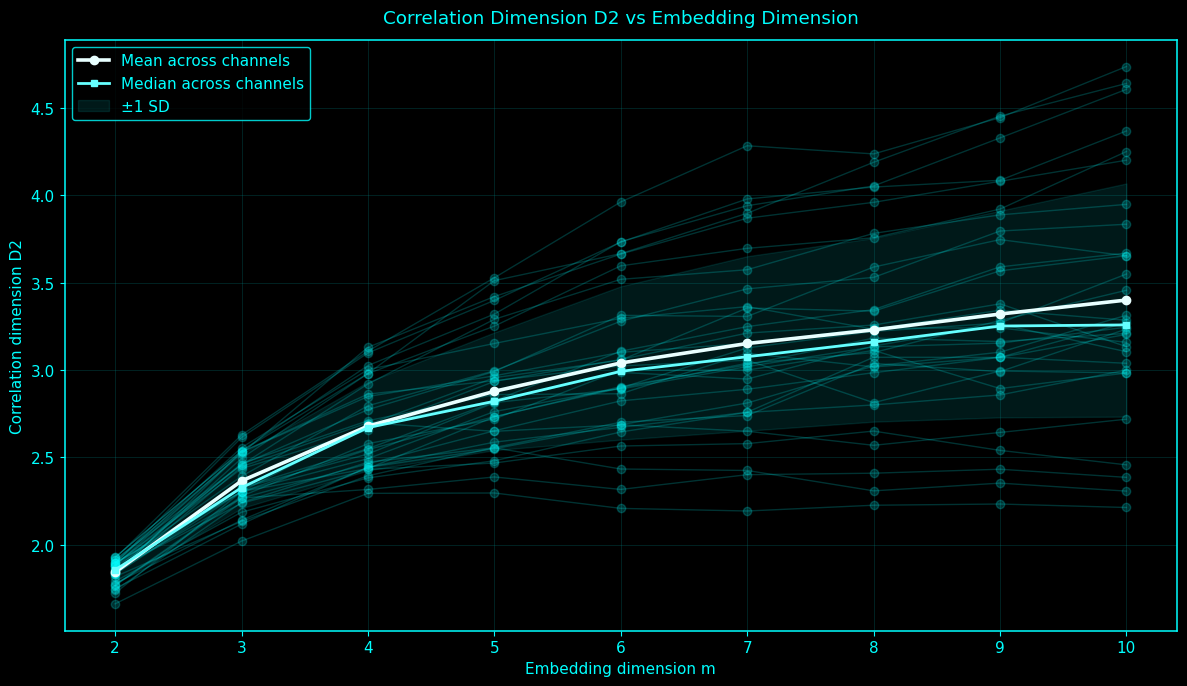

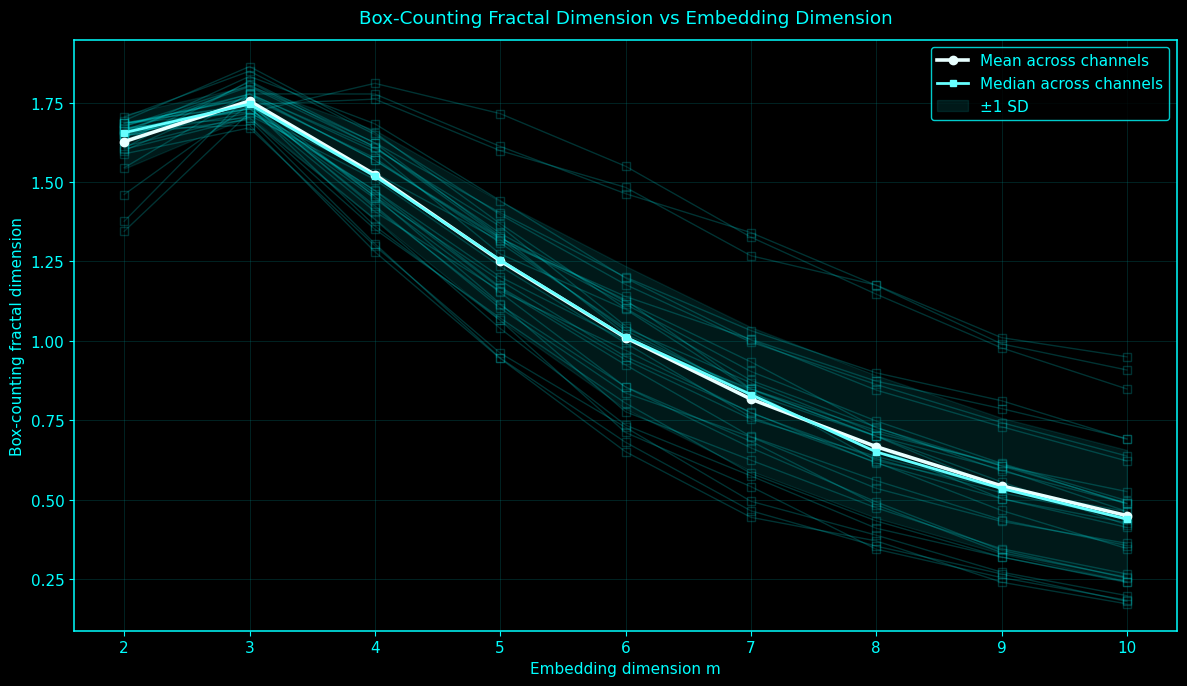

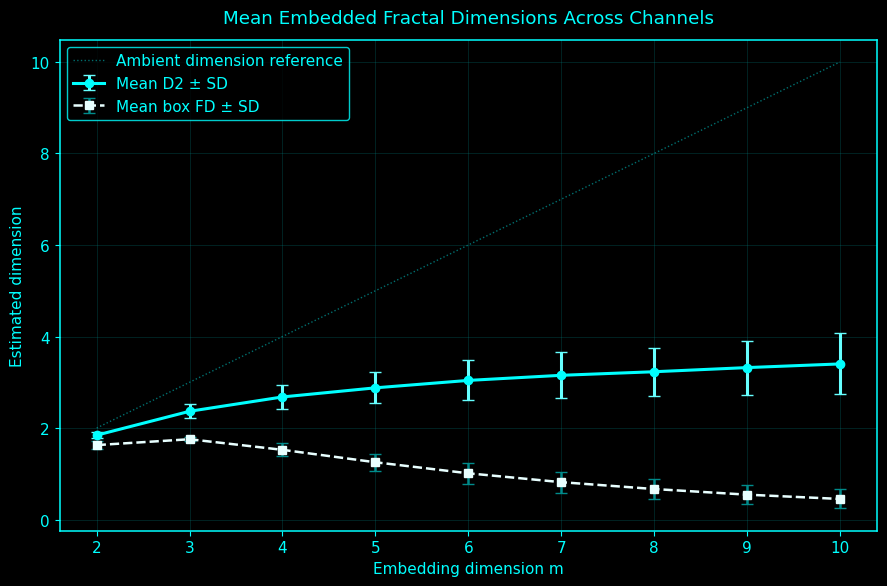

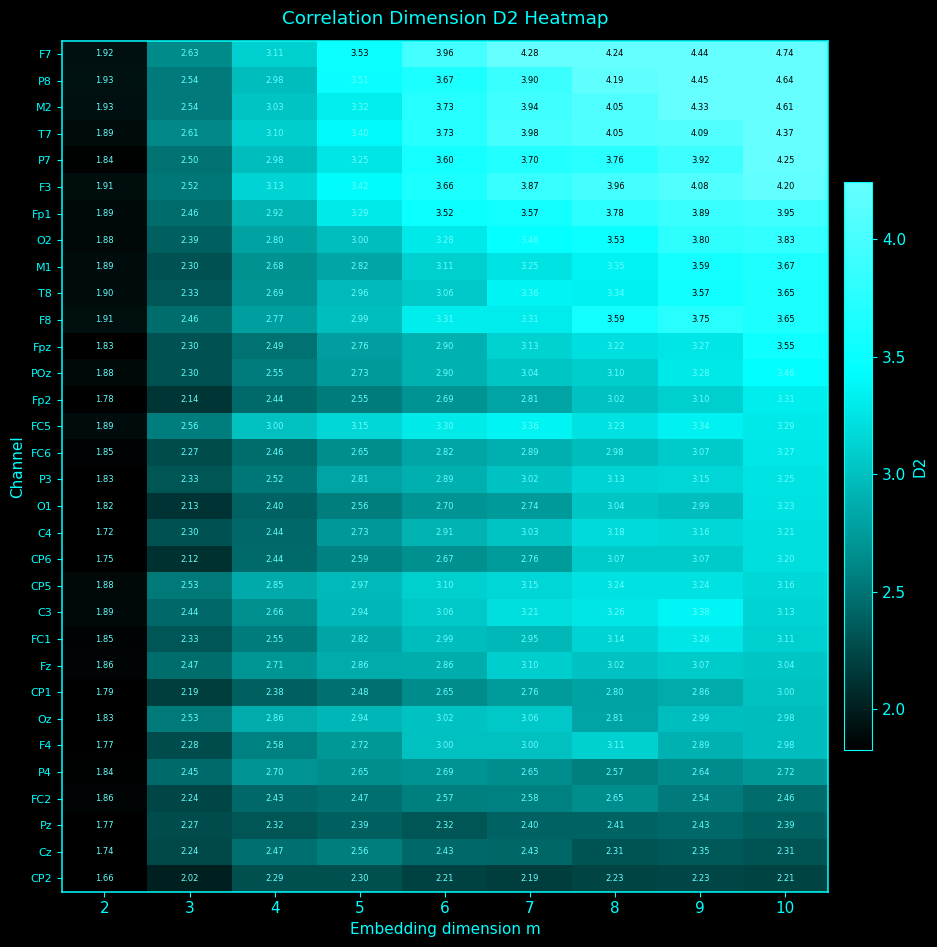

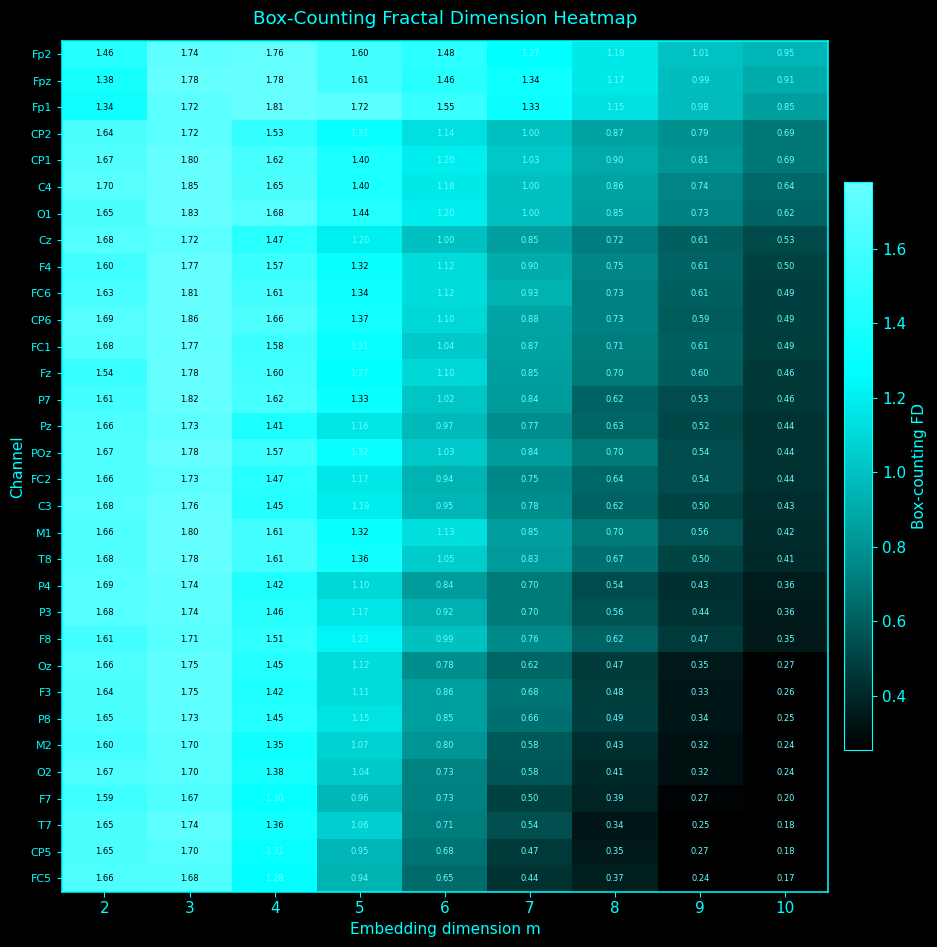

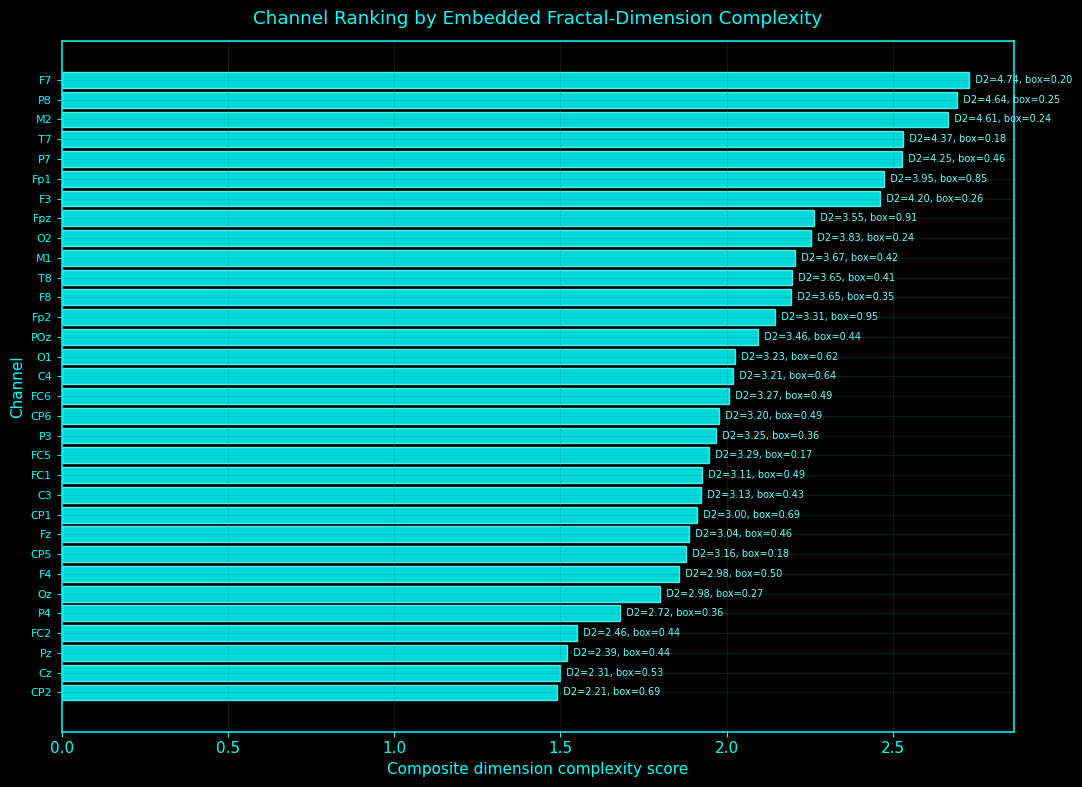

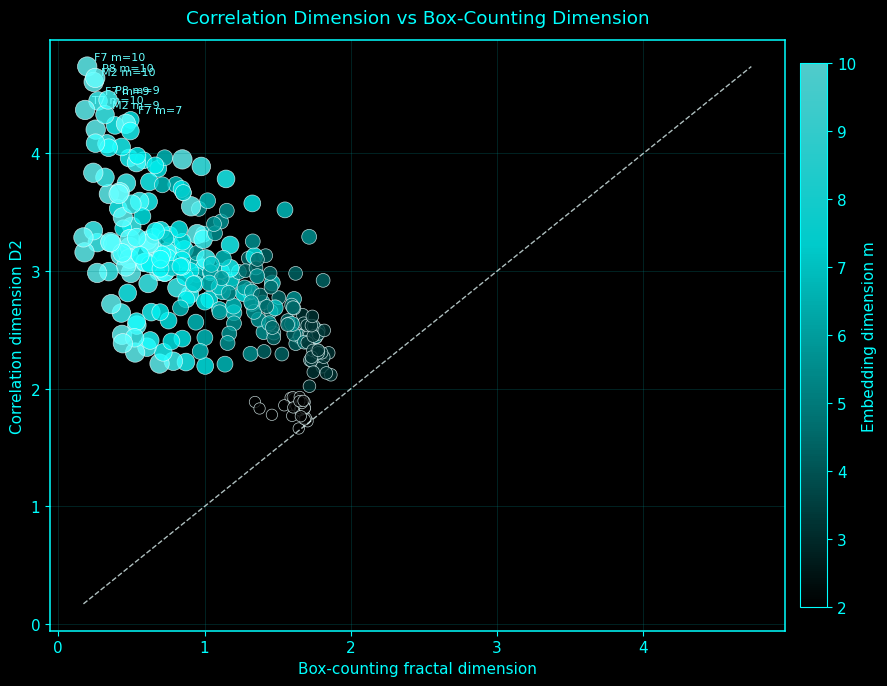

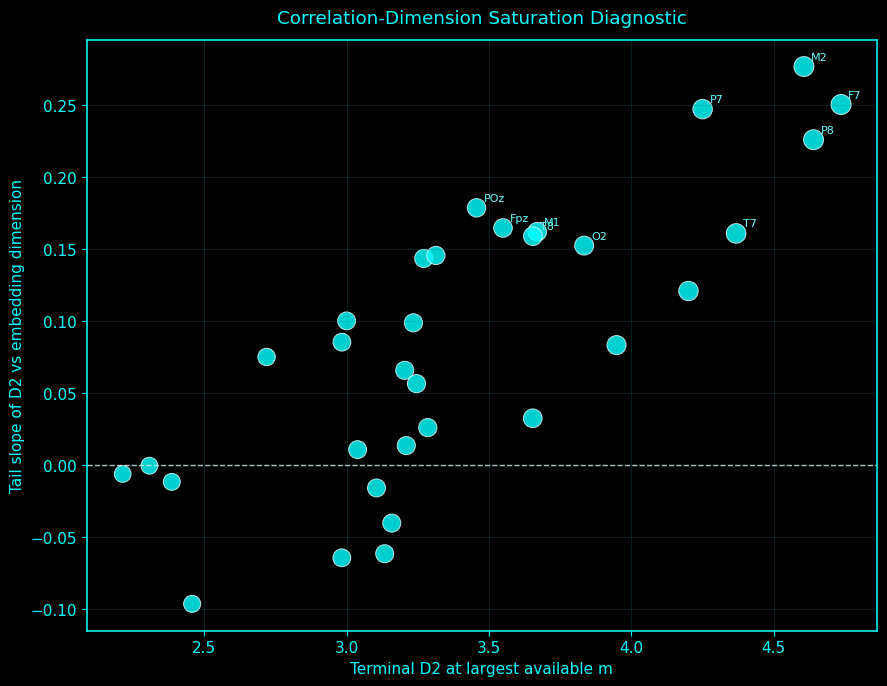

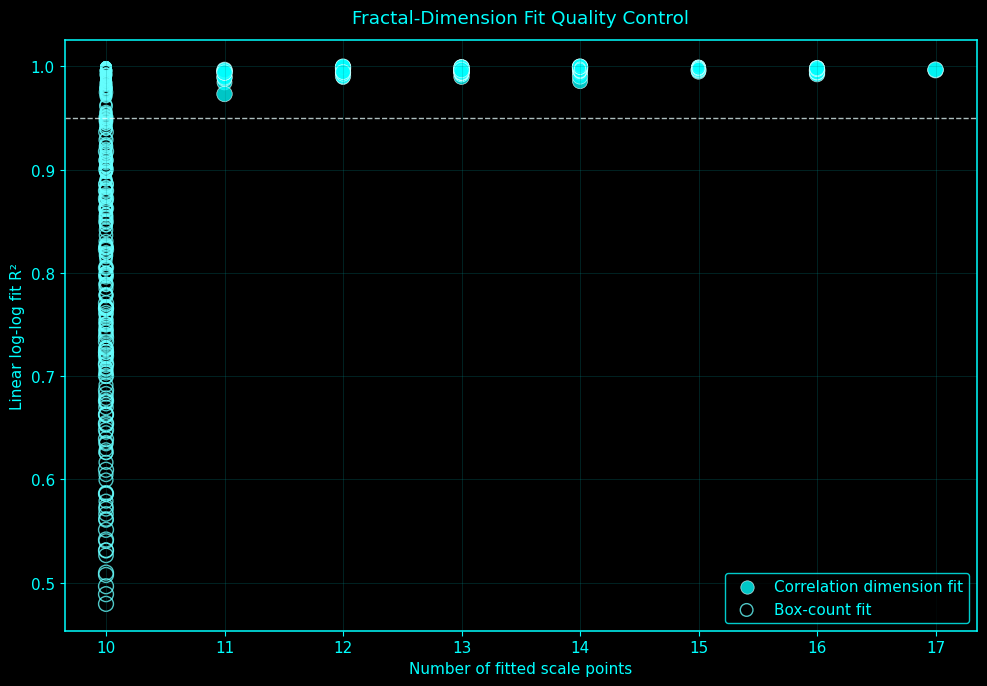

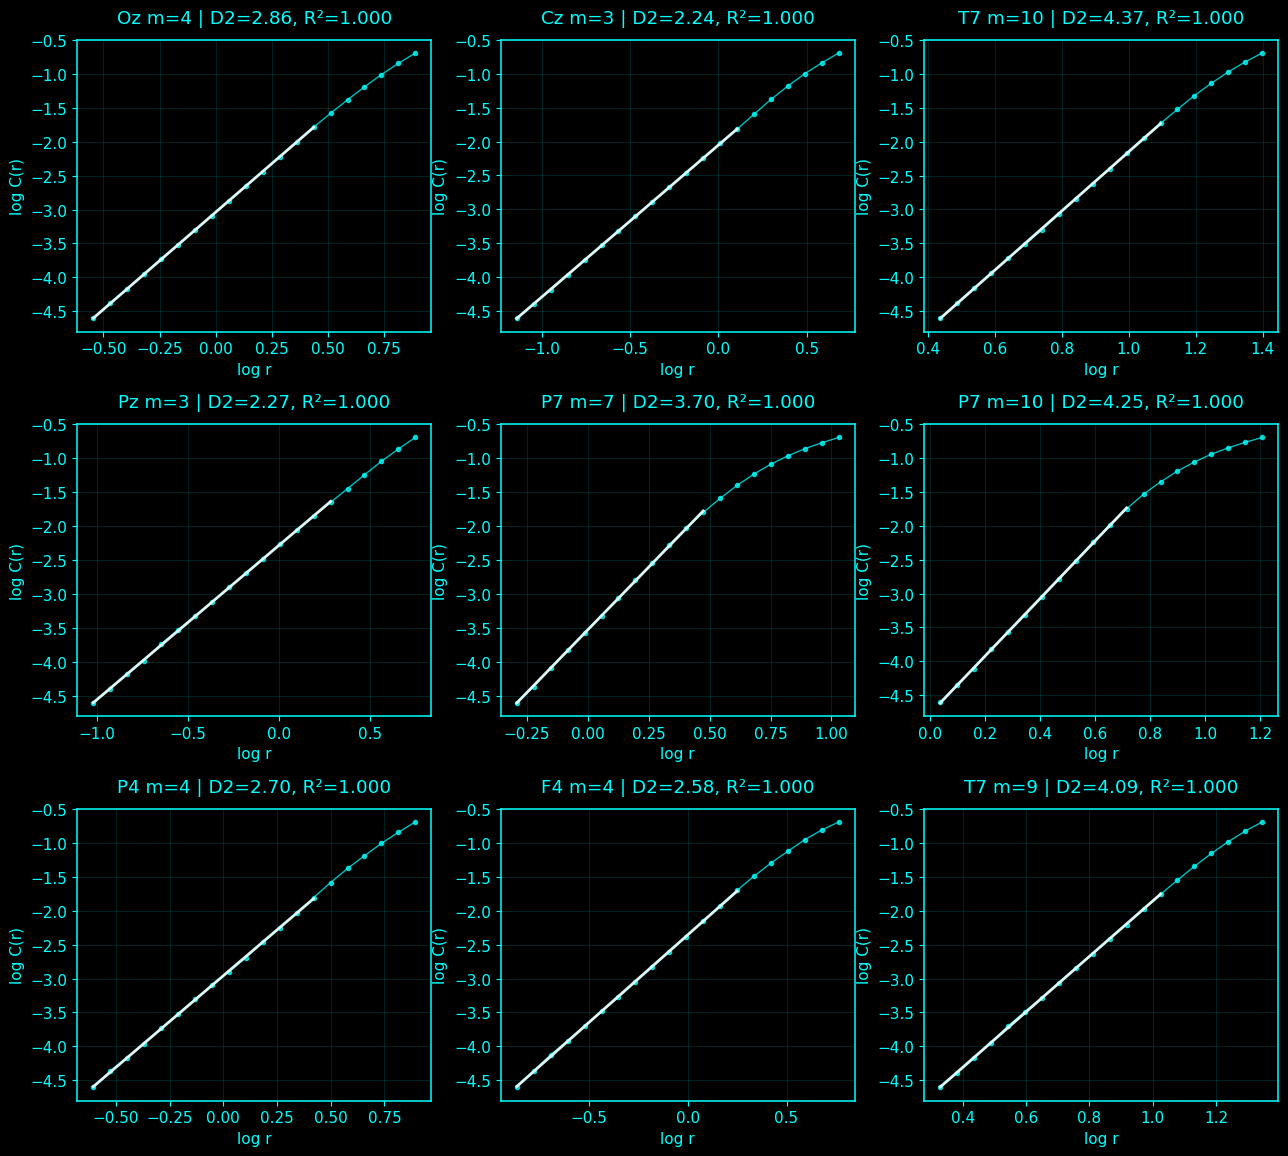


EMBEDDED FRACTAL-DIMENSION ANALYSIS SUMMARY
FAST_OPTION: fast
Rows computed: 288
Channels analyzed: 32
Embedding dimensions analyzed: [2, 3, 4, 5, 6, 7, 8, 9, 10]
Total elapsed: 0.26 min

Mean by embedding dimension:
 emb_dim  boxcount_fd  corr_dim_d2  box_fit_r2  corr_fit_r2  n_rows
       2     1.626869     1.843457    0.999119     0.999226      32
       3     1.754891     2.365671    0.985352     0.998241      32
       4     1.523332     2.679149    0.938449     0.997502      32
       5     1.251768     2.878375    0.885583     0.996431      32
       6     1.010414     3.040584    0.832514     0.995880      32
       7     0.816748     3.152084    0.789950     0.995788      32
       8     0.666869     3.230127    0.746584     0.995756      32
       9     0.543549     3.320601    0.709497     0.995698      32
      10     0.449896     3.400666    0.676657     0.995267      32

Top 15 channels by dimension complexity score:
channel  terminal_corr_dim_d2  terminal_boxcount_fd  d

In [1]:
import os
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

try:
    from IPython.display import display
    _HAVE_IPYTHON_DISPLAY = True
except Exception:
    display = None
    _HAVE_IPYTHON_DISPLAY = False

base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

embedding_2d_dir = os.path.join(base_dir, "embedding_data", "2dembedding_data")
embedding_3d_dir = os.path.join(base_dir, "embedding_data", "3dembedding_data")
embedding_4to10_dir = os.path.join(base_dir, "embedding_data", "embeddings_4to10")

out_dir = os.path.join(base_dir, "embedded_fractal_dimension_research_fast")
plot_dir = os.path.join(out_dir, "plots_black_cyan")
diagnostic_dir = os.path.join(out_dir, "diagnostic_fit_plots")

os.makedirs(out_dir, exist_ok=True)
os.makedirs(plot_dir, exist_ok=True)
os.makedirs(diagnostic_dir, exist_ok=True)

FAST_OPTION = "fast"

if FAST_OPTION == "ultra":
    embedding_dims = [2, 3, 4, 6, 8, 10]
    max_channels = None
    max_points_per_embedding = 4000
    corr_subsample_n = 800
    corr_n_pairs = 25000
    corr_n_r = 16
    corr_cmin = 5e-4
    corr_cmax = 2e-1
    box_subsample_n = 2500
    box_eps = np.logspace(np.log10(1 / 5), np.log10(1 / 45), 8)
    save_diagnostic_fit_plots = True
    diagnostic_top_n = 6

elif FAST_OPTION == "fast":
    embedding_dims = list(range(2, 11))
    max_channels = None
    max_points_per_embedding = 7000
    corr_subsample_n = 1200
    corr_n_pairs = 60000
    corr_n_r = 20
    corr_cmin = 3e-4
    corr_cmax = 2e-1
    box_subsample_n = 4000
    box_eps = np.logspace(np.log10(1 / 5), np.log10(1 / 60), 10)
    save_diagnostic_fit_plots = True
    diagnostic_top_n = 9

elif FAST_OPTION == "balanced":
    embedding_dims = list(range(2, 11))
    max_channels = None
    max_points_per_embedding = 15000
    corr_subsample_n = 2500
    corr_n_pairs = 200000
    corr_n_r = 28
    corr_cmin = 1e-4
    corr_cmax = 1e-1
    box_subsample_n = 8000
    box_eps = np.logspace(np.log10(1 / 6), np.log10(1 / 80), 12)
    save_diagnostic_fit_plots = True
    diagnostic_top_n = 12

elif FAST_OPTION == "full":
    embedding_dims = list(range(2, 11))
    max_channels = None
    max_points_per_embedding = None
    corr_subsample_n = 5000
    corr_n_pairs = 500000
    corr_n_r = 36
    corr_cmin = 5e-5
    corr_cmax = 2e-1
    box_subsample_n = 15000
    box_eps = np.logspace(np.log10(1 / 6), np.log10(1 / 100), 16)
    save_diagnostic_fit_plots = True
    diagnostic_top_n = 16

else:
    raise ValueError("FAST_OPTION must be one of: 'ultra', 'fast', 'balanced', 'full'.")

RUN_BOXCOUNT = True
RUN_CORRELATION_DIMENSION = True
SHOW_PLOTS_IN_NOTEBOOK = True
SAVE_PLOTS_TO_DISK = True
RANDOM_SEED = 0

eeg_channel_names = [
    "Fp1", "Fpz", "Fp2", "F7", "F3", "Fz", "F4", "F8", "FC5", "FC1", "FC2", "FC6",
    "M1", "T7", "C3", "Cz", "C4", "T8", "M2", "CP5", "CP1", "CP2", "CP6",
    "P7", "P3", "Pz", "P4", "P8", "POz", "O1", "Oz", "O2"
]

if max_channels is not None:
    eeg_channel_names = eeg_channel_names[:max_channels]

ACCENT = "#00FFFF"
ACCENT_SOFT = "#66FFFF"
ACCENT_DIM = "#008B8B"
WHITE = "#E8FFFF"
BLACK = "#000000"

CYAN_DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "cyan_diverging",
    [ACCENT_DIM, BLACK, ACCENT_SOFT],
    N=256,
)

CYAN_SEQUENTIAL_CMAP = LinearSegmentedColormap.from_list(
    "cyan_sequential",
    [BLACK, ACCENT_DIM, ACCENT, ACCENT_SOFT],
    N=256,
)

plt.rcParams.update({
    "figure.facecolor": BLACK,
    "axes.facecolor": BLACK,
    "savefig.facecolor": BLACK,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT_DIM,
    "grid.alpha": 0.25,
    "legend.facecolor": BLACK,
    "legend.edgecolor": ACCENT,
    "legend.labelcolor": ACCENT,
    "font.size": 11,
})

rng = np.random.default_rng(RANDOM_SEED)

def style_ax(ax, title=None, xlabel=None, ylabel=None, grid=True):
    ax.set_facecolor(BLACK)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
        spine.set_linewidth(1.1)
    ax.tick_params(axis="x", colors=ACCENT, labelcolor=ACCENT)
    ax.tick_params(axis="y", colors=ACCENT, labelcolor=ACCENT)
    if title is not None:
        ax.set_title(title, color=ACCENT, pad=12)
    if xlabel is not None:
        ax.set_xlabel(xlabel, color=ACCENT)
    if ylabel is not None:
        ax.set_ylabel(ylabel, color=ACCENT)
    if grid:
        ax.grid(True, alpha=0.25, color=ACCENT_DIM, linewidth=0.7)
    else:
        ax.grid(False)

def save_fig(fig, path, show=True):
    fig.tight_layout()
    if SAVE_PLOTS_TO_DISK and path is not None:
        fig.savefig(path, dpi=220, bbox_inches="tight", facecolor=BLACK)
    if SHOW_PLOTS_IN_NOTEBOOK and show and _HAVE_IPYTHON_DISPLAY:
        display(fig)
    plt.close(fig)

def short_label(x, max_len=22):
    x = str(x)
    return x if len(x) <= max_len else x[:max_len - 1] + "…"

def embedding_path(channel_name, emb_dim):
    if emb_dim == 2:
        return os.path.join(embedding_2d_dir, f"2dembedded_{channel_name}.npy")
    if emb_dim == 3:
        return os.path.join(embedding_3d_dir, f"3dembedded_{channel_name}.npy")
    if 4 <= emb_dim <= 10:
        return os.path.join(embedding_4to10_dir, f"{emb_dim}dembedded_{channel_name}.npy")
    return None

def standardize_cols(X):
    X = np.asarray(X, dtype=float)
    X = np.where(np.isfinite(X), X, np.nan)
    col_mean = np.nanmean(X, axis=0, keepdims=True)
    bad = np.where(~np.isfinite(X))
    if bad[0].size > 0:
        X[bad] = np.take(col_mean, bad[1])
    mu = np.mean(X, axis=0, keepdims=True)
    sd = np.std(X, axis=0, keepdims=True) + 1e-12
    return (X - mu) / sd

def rescale_to_unit_cube(X):
    X = np.asarray(X, dtype=float)
    xmin = np.min(X, axis=0, keepdims=True)
    xmax = np.max(X, axis=0, keepdims=True)
    rngv = xmax - xmin
    rngv[rngv < 1e-12] = 1.0
    return (X - xmin) / rngv

def subsample_rows(X, max_points=None, rng=None):
    X = np.asarray(X)
    if rng is None:
        rng = np.random.default_rng()
    n = len(X)
    if max_points is None or n <= max_points:
        return X, np.arange(n)
    idx = np.sort(rng.choice(n, size=max_points, replace=False))
    return X[idx], idx

def linear_fit_r2(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    if np.sum(mask) < 3:
        return np.nan, np.array([np.nan, np.nan]), None
    x = x[mask]
    y = y[mask]
    coef = np.polyfit(x, y, 1)
    yhat = np.polyval(coef, x)
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1.0 - ss_res / (ss_tot + 1e-12)
    return float(r2), coef, yhat

def box_counting_dimension(X, eps_vals, max_points=None, rng=None):
    X = np.asarray(X, dtype=float)
    X, _ = subsample_rows(X, max_points=max_points, rng=rng)
    X = standardize_cols(X)
    X = rescale_to_unit_cube(X)

    counts = []
    inv_eps = []

    for eps in eps_vals:
        bins = np.floor(X / eps).astype(np.int64)
        bins = np.clip(bins, 0, int(np.ceil(1 / eps)) + 2)
        unique_boxes = np.unique(bins, axis=0)
        n_boxes = len(unique_boxes)

        if n_boxes > 0:
            counts.append(n_boxes)
            inv_eps.append(1.0 / eps)

    counts = np.asarray(counts, dtype=float)
    inv_eps = np.asarray(inv_eps, dtype=float)

    mask = np.isfinite(counts) & (counts > 0) & np.isfinite(inv_eps) & (inv_eps > 0)

    if np.sum(mask) < 3:
        return {
            "dimension": np.nan,
            "inv_eps": inv_eps,
            "counts": counts,
            "logx_fit": None,
            "logy_fit": None,
            "fit_line": None,
            "r2": np.nan,
            "n_fit": int(np.sum(mask)),
        }

    logx = np.log(inv_eps[mask])
    logy = np.log(counts[mask])

    r2, coef, fit_line = linear_fit_r2(logx, logy)

    return {
        "dimension": float(coef[0]),
        "inv_eps": inv_eps[mask],
        "counts": counts[mask],
        "logx_fit": logx,
        "logy_fit": logy,
        "fit_line": fit_line,
        "r2": r2,
        "n_fit": int(np.sum(mask)),
    }

def correlation_dimension_sampled(
    X,
    subsample_n=2500,
    n_pairs=200000,
    n_r=28,
    cmin=1e-4,
    cmax=1e-1,
    rng=None,
):
    if rng is None:
        rng = np.random.default_rng()

    X = np.asarray(X, dtype=float)
    X = standardize_cols(X)

    N = len(X)

    if N < 50:
        return {
            "dimension": np.nan,
            "rs": None,
            "Cs": None,
            "logr_fit": None,
            "logC_fit": None,
            "fit_line": None,
            "n_fit": 0,
            "r2": np.nan,
            "n_used": int(N),
            "n_pairs_used": 0,
        }

    if N > subsample_n:
        idx = np.sort(rng.choice(N, size=subsample_n, replace=False))
        X = X[idx]
        N = len(X)

    n_pairs_use = int(n_pairs)
    i = rng.integers(0, N, size=n_pairs_use)
    j = rng.integers(0, N, size=n_pairs_use)
    keep = i != j
    i = i[keep]
    j = j[keep]

    if len(i) < 1000:
        return {
            "dimension": np.nan,
            "rs": None,
            "Cs": None,
            "logr_fit": None,
            "logC_fit": None,
            "fit_line": None,
            "n_fit": 0,
            "r2": np.nan,
            "n_used": int(N),
            "n_pairs_used": int(len(i)),
        }

    d = np.linalg.norm(X[i] - X[j], axis=1)
    d = d[np.isfinite(d) & (d > 0)]

    if len(d) < 1000:
        return {
            "dimension": np.nan,
            "rs": None,
            "Cs": None,
            "logr_fit": None,
            "logC_fit": None,
            "fit_line": None,
            "n_fit": 0,
            "r2": np.nan,
            "n_used": int(N),
            "n_pairs_used": int(len(d)),
        }

    qlo = np.quantile(d, 0.01)
    qhi = np.quantile(d, 0.50)

    if not np.isfinite(qlo) or not np.isfinite(qhi) or qhi <= qlo:
        return {
            "dimension": np.nan,
            "rs": None,
            "Cs": None,
            "logr_fit": None,
            "logC_fit": None,
            "fit_line": None,
            "n_fit": 0,
            "r2": np.nan,
            "n_used": int(N),
            "n_pairs_used": int(len(d)),
        }

    rs = np.logspace(np.log10(qlo), np.log10(qhi), n_r)
    d_sorted = np.sort(d)
    Cs = np.searchsorted(d_sorted, rs, side="right") / len(d_sorted)

    mask = (
        np.isfinite(Cs)
        & (Cs > cmin)
        & (Cs < cmax)
        & np.isfinite(rs)
        & (rs > 0)
    )

    n_fit = int(np.sum(mask))

    if n_fit < 4:
        return {
            "dimension": np.nan,
            "rs": rs,
            "Cs": Cs,
            "logr_fit": None,
            "logC_fit": None,
            "fit_line": None,
            "n_fit": n_fit,
            "r2": np.nan,
            "n_used": int(N),
            "n_pairs_used": int(len(d)),
        }

    log_r = np.log(rs[mask])
    log_C = np.log(Cs[mask])

    r2, coef, fit_line = linear_fit_r2(log_r, log_C)

    return {
        "dimension": float(coef[0]),
        "rs": rs,
        "Cs": Cs,
        "logr_fit": log_r,
        "logC_fit": log_C,
        "fit_line": fit_line,
        "n_fit": n_fit,
        "r2": r2,
        "n_used": int(N),
        "n_pairs_used": int(len(d)),
    }

def add_derived_metrics(results_df):
    df = results_df.copy()

    df["d2_minus_boxfd"] = df["corr_dim_d2"] - df["boxcount_fd"]
    df["d2_over_emb_dim"] = df["corr_dim_d2"] / df["emb_dim"]
    df["boxfd_over_emb_dim"] = df["boxcount_fd"] / df["emb_dim"]

    rows = []

    for channel, sub in df.groupby("channel"):
        sub = sub.sort_values("emb_dim").copy()

        if len(sub) >= 2:
            sub["corr_dim_d2_increment"] = sub["corr_dim_d2"].diff()
            sub["boxcount_fd_increment"] = sub["boxcount_fd"].diff()
        else:
            sub["corr_dim_d2_increment"] = np.nan
            sub["boxcount_fd_increment"] = np.nan

        rows.append(sub)

    if len(rows):
        df = pd.concat(rows, ignore_index=True)

    channel_rows = []

    for channel, sub in df.groupby("channel"):
        sub = sub.sort_values("emb_dim")
        valid_d2 = sub[np.isfinite(sub["corr_dim_d2"])]
        valid_box = sub[np.isfinite(sub["boxcount_fd"])]

        row = {"channel": channel}

        if len(valid_d2):
            last_d2 = valid_d2.iloc[-1]
            row["max_available_emb_dim"] = int(last_d2["emb_dim"])
            row["terminal_corr_dim_d2"] = float(last_d2["corr_dim_d2"])
            row["terminal_corr_r2"] = float(last_d2["corr_fit_r2"])
            row["terminal_corr_fit_points"] = int(last_d2["corr_fit_points"])
            row["terminal_d2_over_m"] = float(last_d2["d2_over_emb_dim"])
        else:
            row["max_available_emb_dim"] = np.nan
            row["terminal_corr_dim_d2"] = np.nan
            row["terminal_corr_r2"] = np.nan
            row["terminal_corr_fit_points"] = np.nan
            row["terminal_d2_over_m"] = np.nan

        if len(valid_box):
            last_box = valid_box.iloc[-1]
            row["terminal_boxcount_fd"] = float(last_box["boxcount_fd"])
            row["terminal_box_r2"] = float(last_box["box_fit_r2"])
        else:
            row["terminal_boxcount_fd"] = np.nan
            row["terminal_box_r2"] = np.nan

        if len(valid_d2) >= 3:
            tail = valid_d2.tail(3)
            row["d2_tail_slope"] = float(np.polyfit(tail["emb_dim"], tail["corr_dim_d2"], 1)[0])
            row["d2_tail_std"] = float(np.nanstd(tail["corr_dim_d2"]))
        else:
            row["d2_tail_slope"] = np.nan
            row["d2_tail_std"] = np.nan

        if len(valid_box) >= 3:
            tail = valid_box.tail(3)
            row["box_tail_slope"] = float(np.polyfit(tail["emb_dim"], tail["boxcount_fd"], 1)[0])
            row["box_tail_std"] = float(np.nanstd(tail["boxcount_fd"]))
        else:
            row["box_tail_slope"] = np.nan
            row["box_tail_std"] = np.nan

        row["dimension_complexity_score"] = (
            0.55 * row.get("terminal_corr_dim_d2", np.nan)
            + 0.25 * row.get("terminal_boxcount_fd", np.nan)
            - 0.10 * abs(row.get("d2_tail_slope", 0.0) if np.isfinite(row.get("d2_tail_slope", np.nan)) else 0.0)
            + 0.10 * row.get("terminal_corr_r2", np.nan)
        )

        channel_rows.append(row)

    channel_summary = pd.DataFrame(channel_rows)

    return df, channel_summary

def plot_dimension_curves(results_df, value_col, ylabel, title, filename, marker="o"):
    fig, ax = plt.subplots(figsize=(12, 7))

    for channel_name in eeg_channel_names:
        sub = results_df[results_df["channel"] == channel_name].sort_values("emb_dim")
        sub = sub[np.isfinite(sub[value_col])]

        if len(sub) == 0:
            continue

        ax.plot(
            sub["emb_dim"],
            sub[value_col],
            marker=marker,
            color=ACCENT,
            markerfacecolor=ACCENT if marker == "o" else BLACK,
            markeredgecolor=ACCENT,
            alpha=0.20,
            linewidth=1.0,
        )

    grouped = (
        results_df.groupby("emb_dim")[value_col]
        .agg(["mean", "median", "std", "count"])
        .reset_index()
    )

    grouped = grouped[np.isfinite(grouped["mean"])]

    if len(grouped):
        ax.plot(
            grouped["emb_dim"],
            grouped["mean"],
            color=WHITE,
            marker="o",
            linewidth=2.6,
            markersize=6,
            label="Mean across channels",
        )

        ax.plot(
            grouped["emb_dim"],
            grouped["median"],
            color=ACCENT_SOFT,
            marker="s",
            linewidth=2.0,
            markersize=5,
            label="Median across channels",
        )

        ax.fill_between(
            grouped["emb_dim"],
            grouped["mean"] - grouped["std"],
            grouped["mean"] + grouped["std"],
            color=ACCENT,
            alpha=0.10,
            label="±1 SD",
        )

    style_ax(
        ax,
        title=title,
        xlabel="Embedding dimension m",
        ylabel=ylabel,
    )

    leg = ax.legend(loc="best", frameon=True)
    for text in leg.get_texts():
        text.set_color(ACCENT)

    path = os.path.join(plot_dir, filename)
    save_fig(fig, path)
    return path

def plot_mean_dimensions(results_df):
    grouped = (
        results_df.groupby("emb_dim")
        .agg(
            box_mean=("boxcount_fd", "mean"),
            box_std=("boxcount_fd", "std"),
            d2_mean=("corr_dim_d2", "mean"),
            d2_std=("corr_dim_d2", "std"),
            n=("channel", "count"),
        )
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(9, 6))

    ax.errorbar(
        grouped["emb_dim"],
        grouped["d2_mean"],
        yerr=grouped["d2_std"],
        marker="o",
        color=ACCENT,
        ecolor=ACCENT_SOFT,
        linewidth=2.2,
        capsize=4,
        label="Mean D2 ± SD",
    )

    ax.errorbar(
        grouped["emb_dim"],
        grouped["box_mean"],
        yerr=grouped["box_std"],
        marker="s",
        color=WHITE,
        ecolor=ACCENT_DIM,
        linewidth=1.8,
        capsize=4,
        linestyle="--",
        label="Mean box FD ± SD",
    )

    ax.plot(
        grouped["emb_dim"],
        grouped["emb_dim"],
        color=ACCENT_DIM,
        linestyle=":",
        linewidth=1.0,
        alpha=0.8,
        label="Ambient dimension reference",
    )

    style_ax(
        ax,
        title="Mean Embedded Fractal Dimensions Across Channels",
        xlabel="Embedding dimension m",
        ylabel="Estimated dimension",
    )

    leg = ax.legend(loc="best", frameon=True)
    for text in leg.get_texts():
        text.set_color(ACCENT)

    path = os.path.join(plot_dir, "03_mean_embedded_fractal_dimensions_black_cyan.png")
    save_fig(fig, path)
    return path

def plot_heatmap(results_df, value_col, title, filename, color_label):
    pivot = results_df.pivot_table(
        index="channel",
        columns="emb_dim",
        values=value_col,
        aggfunc="mean",
    )

    if pivot.empty:
        return None

    channel_order = []
    if pivot.shape[1] > 0:
        last_col = pivot.columns.max()
        channel_order = pivot.sort_values(last_col, ascending=False).index.tolist()
    else:
        channel_order = pivot.index.tolist()

    pivot = pivot.loc[channel_order]

    M = pivot.to_numpy(dtype=float)

    fig_height = min(10.5, max(7.0, 0.30 * len(pivot.index)))
    fig, ax = plt.subplots(figsize=(9.5, fig_height))

    finite = M[np.isfinite(M)]
    if finite.size:
        vmin = np.nanpercentile(finite, 3)
        vmax = np.nanpercentile(finite, 97)
    else:
        vmin, vmax = 0, 1

    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmax <= vmin:
        vmin, vmax = 0, 1

    im = ax.imshow(
        M,
        aspect="auto",
        interpolation="nearest",
        cmap=CYAN_SEQUENTIAL_CMAP,
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, color=ACCENT)

    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index, color=ACCENT, fontsize=8)

    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            val = M[i, j]
            if np.isfinite(val):
                ax.text(
                    j,
                    i,
                    f"{val:.2f}",
                    ha="center",
                    va="center",
                    fontsize=6,
                    color=BLACK if val > (vmin + 0.70 * (vmax - vmin)) else ACCENT_SOFT,
                )

    style_ax(
        ax,
        title=title,
        xlabel="Embedding dimension m",
        ylabel="Channel",
        grid=False,
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.set_label(color_label, color=ACCENT)

    path = os.path.join(plot_dir, filename)
    save_fig(fig, path)
    return path

def plot_terminal_dimension_ranking(channel_summary):
    df = channel_summary.copy()
    df = df[np.isfinite(df["dimension_complexity_score"])]

    if df.empty:
        return None

    df = df.sort_values("dimension_complexity_score", ascending=False)
    df_plot = df.head(32).sort_values("dimension_complexity_score", ascending=True)

    fig, ax = plt.subplots(figsize=(11, 8))

    y = np.arange(len(df_plot))

    ax.barh(
        y,
        df_plot["dimension_complexity_score"],
        color=ACCENT,
        edgecolor=ACCENT_SOFT,
        alpha=0.85,
    )

    ax.set_yticks(y)
    ax.set_yticklabels(df_plot["channel"], color=ACCENT, fontsize=8)

    for yi, (_, row) in zip(y, df_plot.iterrows()):
        ax.text(
            row["dimension_complexity_score"],
            yi,
            f"  D2={row['terminal_corr_dim_d2']:.2f}, box={row['terminal_boxcount_fd']:.2f}",
            va="center",
            ha="left",
            color=ACCENT_SOFT,
            fontsize=7,
        )

    style_ax(
        ax,
        title="Channel Ranking by Embedded Fractal-Dimension Complexity",
        xlabel="Composite dimension complexity score",
        ylabel="Channel",
    )

    path = os.path.join(plot_dir, "06_channel_dimension_complexity_ranking_black_cyan.png")
    save_fig(fig, path)
    return path

def plot_d2_vs_box_scatter(results_df):
    df = results_df.copy()
    df = df[np.isfinite(df["corr_dim_d2"]) & np.isfinite(df["boxcount_fd"])]

    if df.empty:
        return None

    fig, ax = plt.subplots(figsize=(9, 7))

    sizes = 35 + 16 * df["emb_dim"].to_numpy(dtype=float)

    sc = ax.scatter(
        df["boxcount_fd"],
        df["corr_dim_d2"],
        s=sizes,
        c=df["emb_dim"],
        cmap=CYAN_SEQUENTIAL_CMAP,
        edgecolors=WHITE,
        linewidths=0.5,
        alpha=0.80,
    )

    lo = np.nanmin([df["boxcount_fd"].min(), df["corr_dim_d2"].min()])
    hi = np.nanmax([df["boxcount_fd"].max(), df["corr_dim_d2"].max()])

    ax.plot([lo, hi], [lo, hi], color=WHITE, linestyle="--", linewidth=1.0, alpha=0.75)

    for _, row in df.sort_values("corr_dim_d2", ascending=False).head(8).iterrows():
        ax.annotate(
            f"{row['channel']} m={int(row['emb_dim'])}",
            (row["boxcount_fd"], row["corr_dim_d2"]),
            xytext=(5, 5),
            textcoords="offset points",
            color=ACCENT_SOFT,
            fontsize=8,
        )

    style_ax(
        ax,
        title="Correlation Dimension vs Box-Counting Dimension",
        xlabel="Box-counting fractal dimension",
        ylabel="Correlation dimension D2",
    )

    cbar = fig.colorbar(sc, ax=ax, fraction=0.035, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.set_label("Embedding dimension m", color=ACCENT)

    path = os.path.join(plot_dir, "07_d2_vs_boxcount_scatter_black_cyan.png")
    save_fig(fig, path)
    return path

def plot_saturation_slope(channel_summary):
    df = channel_summary.copy()
    df = df[np.isfinite(df["terminal_corr_dim_d2"]) & np.isfinite(df["d2_tail_slope"])]

    if df.empty:
        return None

    fig, ax = plt.subplots(figsize=(9, 7))

    ax.scatter(
        df["terminal_corr_dim_d2"],
        df["d2_tail_slope"],
        s=90 + 250 * np.clip(df["terminal_d2_over_m"].fillna(0).to_numpy(), 0, 1),
        c=ACCENT,
        edgecolors=WHITE,
        linewidths=0.7,
        alpha=0.82,
    )

    ax.axhline(0, color=WHITE, linestyle="--", linewidth=1.0, alpha=0.75)

    for _, row in df.reindex(df["d2_tail_slope"].abs().sort_values(ascending=False).index).head(10).iterrows():
        ax.annotate(
            row["channel"],
            (row["terminal_corr_dim_d2"], row["d2_tail_slope"]),
            xytext=(5, 5),
            textcoords="offset points",
            color=ACCENT_SOFT,
            fontsize=8,
        )

    style_ax(
        ax,
        title="Correlation-Dimension Saturation Diagnostic",
        xlabel="Terminal D2 at largest available m",
        ylabel="Tail slope of D2 vs embedding dimension",
    )

    path = os.path.join(plot_dir, "08_d2_saturation_diagnostic_black_cyan.png")
    save_fig(fig, path)
    return path

def plot_reliability_qc(results_df):
    df = results_df.copy()
    df = df[np.isfinite(df["corr_fit_r2"]) | np.isfinite(df["box_fit_r2"])]

    if df.empty:
        return None

    fig, ax = plt.subplots(figsize=(10, 7))

    ax.scatter(
        df["corr_fit_points"],
        df["corr_fit_r2"],
        s=45 + 8 * df["emb_dim"].to_numpy(dtype=float),
        c=ACCENT,
        edgecolors=WHITE,
        linewidths=0.5,
        alpha=0.78,
        label="Correlation dimension fit",
    )

    ax.scatter(
        df["box_fit_points"],
        df["box_fit_r2"],
        s=35 + 8 * df["emb_dim"].to_numpy(dtype=float),
        facecolors="none",
        edgecolors=ACCENT_SOFT,
        linewidths=1.0,
        alpha=0.78,
        label="Box-count fit",
    )

    ax.axhline(0.95, color=WHITE, linestyle="--", linewidth=1.0, alpha=0.75)

    style_ax(
        ax,
        title="Fractal-Dimension Fit Quality Control",
        xlabel="Number of fitted scale points",
        ylabel="Linear log-log fit R²",
    )

    leg = ax.legend(loc="best", frameon=True)
    for text in leg.get_texts():
        text.set_color(ACCENT)

    path = os.path.join(plot_dir, "09_fit_quality_control_black_cyan.png")
    save_fig(fig, path)
    return path

def plot_diagnostic_fits(diagnostics, results_df):
    if not save_diagnostic_fit_plots:
        return None

    df = results_df.copy()
    df = df[np.isfinite(df["corr_dim_d2"]) & np.isfinite(df["corr_fit_r2"])]

    if df.empty:
        return None

    df = df.sort_values(["corr_fit_r2", "corr_dim_d2"], ascending=False).head(diagnostic_top_n)

    n = len(df)
    ncols = 3
    nrows = int(math.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.9 * nrows), squeeze=False)
    fig.patch.set_facecolor(BLACK)

    for ax in axes.ravel():
        ax.set_facecolor(BLACK)
        ax.axis("off")

    for ax, (_, row) in zip(axes.ravel(), df.iterrows()):
        ax.axis("on")
        key = (row["channel"], int(row["emb_dim"]))
        diag = diagnostics.get(key, None)

        if diag is None or diag["corr"].get("rs", None) is None:
            ax.text(0.5, 0.5, "No diagnostic curve", transform=ax.transAxes, ha="center", va="center", color=ACCENT)
            style_ax(ax, title=f"{row['channel']} m={int(row['emb_dim'])}")
            continue

        corr = diag["corr"]

        rs = np.asarray(corr["rs"], dtype=float)
        Cs = np.asarray(corr["Cs"], dtype=float)

        mask = np.isfinite(rs) & np.isfinite(Cs) & (rs > 0) & (Cs > 0)

        if np.any(mask):
            ax.plot(
                np.log(rs[mask]),
                np.log(Cs[mask]),
                marker="o",
                color=ACCENT,
                linewidth=1.0,
                markersize=3,
                alpha=0.75,
                label="log C(r)",
            )

        if corr.get("logr_fit", None) is not None and corr.get("fit_line", None) is not None:
            ax.plot(
                corr["logr_fit"],
                corr["fit_line"],
                color=WHITE,
                linewidth=2.0,
                alpha=0.95,
                label="fit",
            )

        style_ax(
            ax,
            title=f"{row['channel']} m={int(row['emb_dim'])} | D2={row['corr_dim_d2']:.2f}, R²={row['corr_fit_r2']:.3f}",
            xlabel="log r",
            ylabel="log C(r)",
        )

    path = os.path.join(diagnostic_dir, f"diagnostic_correlation_dimension_fits_{FAST_OPTION}.png")
    save_fig(fig, path)
    return path

def save_summary_text(results_df, channel_summary, mean_df, txt_path):
    with open(txt_path, "w") as f:
        f.write("Fractal dimension of embedded EEG attractors\n")
        f.write("==========================================\n\n")
        f.write("Computed on saved 2D, 3D, and 4D..10D embeddings.\n")
        f.write("Metrics:\n")
        f.write("  1) Box-counting fractal dimension\n")
        f.write("  2) Sampled Grassberger-Procaccia correlation dimension D2\n\n")
        f.write(f"FAST_OPTION: {FAST_OPTION}\n")
        f.write(f"embedding_dims: {embedding_dims}\n")
        f.write(f"max_points_per_embedding: {max_points_per_embedding}\n")
        f.write(f"box_subsample_n: {box_subsample_n}\n")
        f.write(f"corr_subsample_n: {corr_subsample_n}\n")
        f.write(f"corr_n_pairs: {corr_n_pairs}\n")
        f.write(f"corr_n_r: {corr_n_r}\n")
        f.write(f"corr_cmin: {corr_cmin}\n")
        f.write(f"corr_cmax: {corr_cmax}\n\n")

        f.write("Mean by embedding dimension:\n")
        for _, row in mean_df.iterrows():
            f.write(
                f"m={int(row['emb_dim'])}: "
                f"mean_boxFD={row['boxcount_fd']:.6f}, "
                f"mean_D2={row['corr_dim_d2']:.6f}, "
                f"mean_corr_R2={row['corr_fit_r2']:.6f}, "
                f"mean_box_R2={row['box_fit_r2']:.6f}\n"
            )

        f.write("\nTop channels by dimension complexity score:\n")
        top = channel_summary.sort_values("dimension_complexity_score", ascending=False).head(20)
        for _, row in top.iterrows():
            f.write(
                f"{row['channel']}: "
                f"score={row['dimension_complexity_score']:.6f}, "
                f"terminal_D2={row['terminal_corr_dim_d2']:.6f}, "
                f"terminal_boxFD={row['terminal_boxcount_fd']:.6f}, "
                f"D2_tail_slope={row['d2_tail_slope']:.6f}, "
                f"terminal_corr_R2={row['terminal_corr_r2']:.6f}\n"
            )

rows = []
diagnostics = {}

print("Running embedded fractal-dimension research analysis", flush=True)
print(f"FAST_OPTION: {FAST_OPTION}", flush=True)
print(f"embedding_dims: {embedding_dims}", flush=True)
print(f"corr_subsample_n: {corr_subsample_n}", flush=True)
print(f"corr_n_pairs: {corr_n_pairs}", flush=True)
print(f"box_subsample_n: {box_subsample_n}", flush=True)
print(f"Output directory: {out_dir}", flush=True)

start_all = time.perf_counter()

for channel_idx, channel_name in enumerate(eeg_channel_names, start=1):
    print(f"\n[{channel_idx}/{len(eeg_channel_names)}] Channel: {channel_name}", flush=True)

    for emb_dim in embedding_dims:
        fpath = embedding_path(channel_name, emb_dim)

        if fpath is None or not os.path.exists(fpath):
            print(f"  Missing m={emb_dim}", flush=True)
            continue

        t0 = time.perf_counter()

        try:
            X = np.load(fpath)
            X = np.asarray(X, dtype=float)

            if X.ndim != 2:
                print(f"  Bad shape for m={emb_dim}: {X.shape}", flush=True)
                continue

            n_points_original = int(len(X))

            X_used, _ = subsample_rows(X, max_points=max_points_per_embedding, rng=rng)
            n_points_used = int(len(X_used))

            if RUN_BOXCOUNT:
                box = box_counting_dimension(
                    X_used,
                    box_eps,
                    max_points=box_subsample_n,
                    rng=rng,
                )
                box_fd = box["dimension"]
                box_r2 = box["r2"]
                box_fit_points = box["n_fit"]
            else:
                box = {}
                box_fd = np.nan
                box_r2 = np.nan
                box_fit_points = 0

            if RUN_CORRELATION_DIMENSION:
                corr = correlation_dimension_sampled(
                    X_used,
                    subsample_n=corr_subsample_n,
                    n_pairs=corr_n_pairs,
                    n_r=corr_n_r,
                    cmin=corr_cmin,
                    cmax=corr_cmax,
                    rng=rng,
                )
                d2_fd = corr["dimension"]
                corr_r2 = corr["r2"]
                corr_fit_points = corr["n_fit"]
                corr_n_used = corr["n_used"]
                corr_pairs_used = corr["n_pairs_used"]
            else:
                corr = {}
                d2_fd = np.nan
                corr_r2 = np.nan
                corr_fit_points = 0
                corr_n_used = 0
                corr_pairs_used = 0

            diagnostics[(channel_name, emb_dim)] = {
                "box": box,
                "corr": corr,
            }

            elapsed = time.perf_counter() - t0

            rows.append({
                "channel": channel_name,
                "emb_dim": int(emb_dim),
                "n_points_original": n_points_original,
                "n_points_used": n_points_used,
                "ambient_dim": int(X.shape[1]),
                "boxcount_fd": box_fd,
                "box_fit_r2": box_r2,
                "box_fit_points": box_fit_points,
                "corr_dim_d2": d2_fd,
                "corr_fit_r2": corr_r2,
                "corr_fit_points": corr_fit_points,
                "corr_n_used": corr_n_used,
                "corr_pairs_used": corr_pairs_used,
                "elapsed_sec": elapsed,
                "status": "ok",
                "error": "",
            })

            print(
                f"  m={emb_dim:2d} | n_orig={n_points_original:7d} | n_used={n_points_used:6d} | "
                f"boxFD={box_fd:7.4f} R2={box_r2:6.3f} | "
                f"D2={d2_fd:7.4f} R2={corr_r2:6.3f} fitPts={corr_fit_points:2d} | "
                f"{elapsed:.2f}s",
                flush=True,
            )

        except Exception as e:
            elapsed = time.perf_counter() - t0
            rows.append({
                "channel": channel_name,
                "emb_dim": int(emb_dim),
                "n_points_original": np.nan,
                "n_points_used": np.nan,
                "ambient_dim": np.nan,
                "boxcount_fd": np.nan,
                "box_fit_r2": np.nan,
                "box_fit_points": 0,
                "corr_dim_d2": np.nan,
                "corr_fit_r2": np.nan,
                "corr_fit_points": 0,
                "corr_n_used": 0,
                "corr_pairs_used": 0,
                "elapsed_sec": elapsed,
                "status": "error",
                "error": f"{type(e).__name__}: {e}",
            })
            print(f"  ERROR m={emb_dim}: {type(e).__name__}: {e}", flush=True)

results_df = pd.DataFrame(rows)

if results_df.empty:
    raise RuntimeError("No embedding fractal-dimension results were computed. Check embedding paths and filenames.")

results_df, channel_summary = add_derived_metrics(results_df)

mean_df = (
    results_df.groupby("emb_dim")
    .agg(
        boxcount_fd=("boxcount_fd", "mean"),
        corr_dim_d2=("corr_dim_d2", "mean"),
        box_fit_r2=("box_fit_r2", "mean"),
        corr_fit_r2=("corr_fit_r2", "mean"),
        n_rows=("channel", "count"),
    )
    .reset_index()
)

results_csv = os.path.join(out_dir, f"embedded_fractal_dimension_summary_{FAST_OPTION}.csv")
channel_summary_csv = os.path.join(out_dir, f"embedded_fractal_dimension_channel_summary_{FAST_OPTION}.csv")
mean_csv = os.path.join(out_dir, f"embedded_fractal_dimension_mean_by_dim_{FAST_OPTION}.csv")
txt_path = os.path.join(out_dir, f"embedded_fractal_dimension_summary_{FAST_OPTION}.txt")

results_df.to_csv(results_csv, index=False)
channel_summary.to_csv(channel_summary_csv, index=False)
mean_df.to_csv(mean_csv, index=False)

save_summary_text(results_df, channel_summary, mean_df, txt_path)

print("\nSummary table:")
print(results_df.head(20).to_string(index=False))

print("\nGenerating black/cyan expert plots...", flush=True)

plot_paths = []

plot_paths.append(plot_dimension_curves(
    results_df,
    value_col="corr_dim_d2",
    ylabel="Correlation dimension D2",
    title="Correlation Dimension D2 vs Embedding Dimension",
    filename="01_corr_dimension_vs_embedding_dim_all_channels_black_cyan.png",
    marker="o",
))

plot_paths.append(plot_dimension_curves(
    results_df,
    value_col="boxcount_fd",
    ylabel="Box-counting fractal dimension",
    title="Box-Counting Fractal Dimension vs Embedding Dimension",
    filename="02_boxcount_dimension_vs_embedding_dim_all_channels_black_cyan.png",
    marker="s",
))

plot_paths.append(plot_mean_dimensions(results_df))

plot_paths.append(plot_heatmap(
    results_df,
    value_col="corr_dim_d2",
    title="Correlation Dimension D2 Heatmap",
    filename="04_corr_dimension_heatmap_black_cyan.png",
    color_label="D2",
))

plot_paths.append(plot_heatmap(
    results_df,
    value_col="boxcount_fd",
    title="Box-Counting Fractal Dimension Heatmap",
    filename="05_boxcount_dimension_heatmap_black_cyan.png",
    color_label="Box-counting FD",
))

plot_paths.append(plot_terminal_dimension_ranking(channel_summary))
plot_paths.append(plot_d2_vs_box_scatter(results_df))
plot_paths.append(plot_saturation_slope(channel_summary))
plot_paths.append(plot_reliability_qc(results_df))
plot_paths.append(plot_diagnostic_fits(diagnostics, results_df))

plot_paths = [p for p in plot_paths if p is not None]

elapsed_all = time.perf_counter() - start_all

print("\n" + "=" * 88)
print("EMBEDDED FRACTAL-DIMENSION ANALYSIS SUMMARY")
print("=" * 88)
print(f"FAST_OPTION: {FAST_OPTION}")
print(f"Rows computed: {len(results_df)}")
print(f"Channels analyzed: {results_df['channel'].nunique()}")
print(f"Embedding dimensions analyzed: {sorted(results_df['emb_dim'].dropna().unique())}")
print(f"Total elapsed: {elapsed_all / 60:.2f} min")

print("\nMean by embedding dimension:")
print(mean_df.to_string(index=False))

print("\nTop 15 channels by dimension complexity score:")
cols = [
    "channel",
    "terminal_corr_dim_d2",
    "terminal_boxcount_fd",
    "d2_tail_slope",
    "terminal_corr_r2",
    "dimension_complexity_score",
]
cols = [c for c in cols if c in channel_summary.columns]
print(channel_summary.sort_values("dimension_complexity_score", ascending=False)[cols].head(15).to_string(index=False))

print("\nSaved outputs:")
print(f"Summary CSV: {results_csv}")
print(f"Channel summary CSV: {channel_summary_csv}")
print(f"Mean-by-dimension CSV: {mean_csv}")
print(f"Summary TXT: {txt_path}")

print("\nSaved plots:")
for p in plot_paths:
    print(p)

print("\nDone.")

Loaded summary:
  channel  emb_dim         D
0      C3        2  1.887070
1      C3        3  2.429531
2      C3        4  2.760086
3      C3        5  2.956774
4      C3        6  3.101867

Saturation summary:
   channel  m_min  m_max     D2_m2   D2_mmax  D2_total_gain  mean_delta_D2  \
10     FC2    2.0   10.0  1.845340  2.411511       0.566172       0.070771   
25      Pz    2.0   10.0  1.794332  2.272540       0.478208       0.059776   
15      Cz    2.0   10.0  1.814592  2.227675       0.413084       0.051635   
21     CP2    2.0   10.0  1.731433  1.979492       0.248059       0.031007   
6       F4    2.0   10.0  1.853297  2.690964       0.837667       0.104708   
26      P4    2.0   10.0  1.851545  2.532727       0.681182       0.085148   
30      Oz    2.0   10.0  1.909665  2.942559       1.032895       0.129112   
16      C4    2.0   10.0  1.751866  2.829935       1.078069       0.134759   
4       F3    2.0   10.0  1.961742  4.321722       2.359979       0.294997   
8      FC

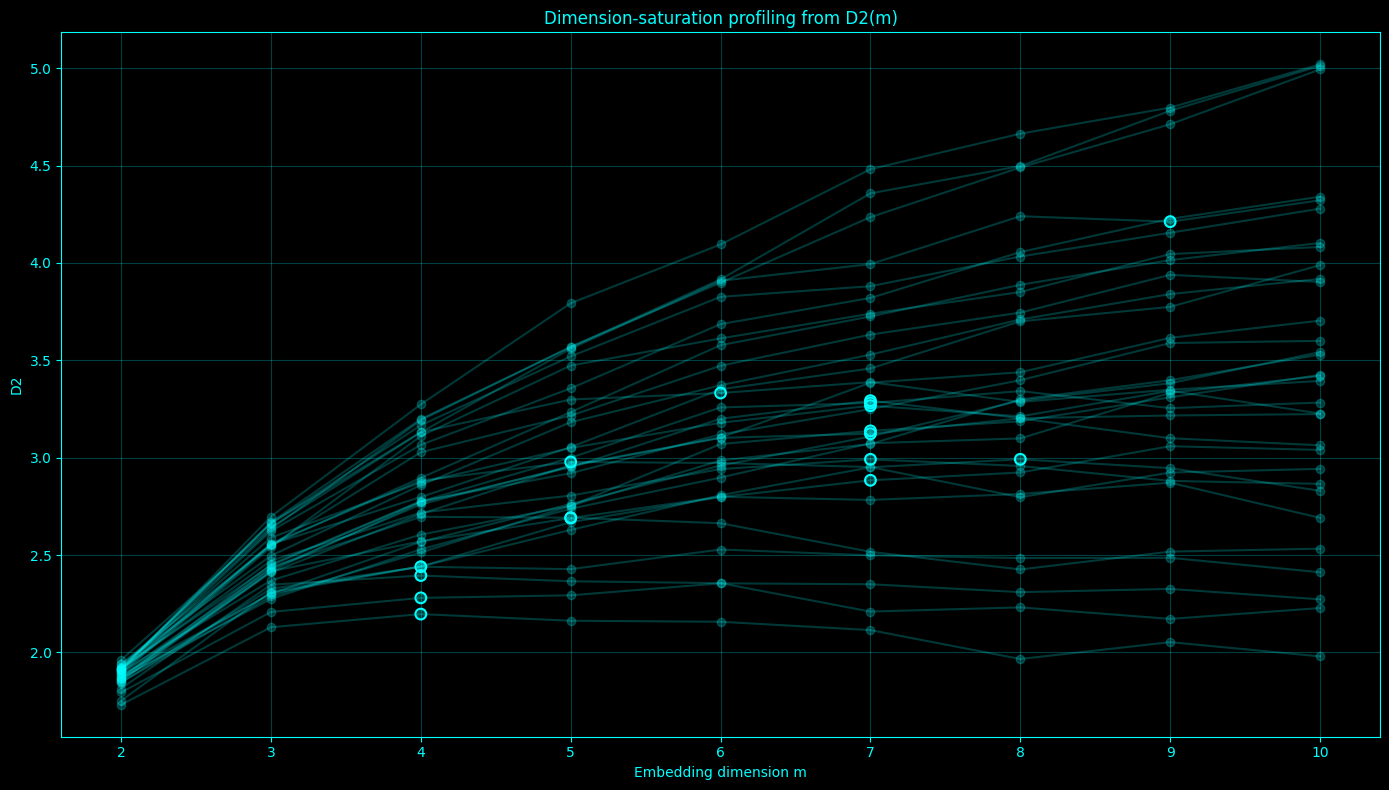

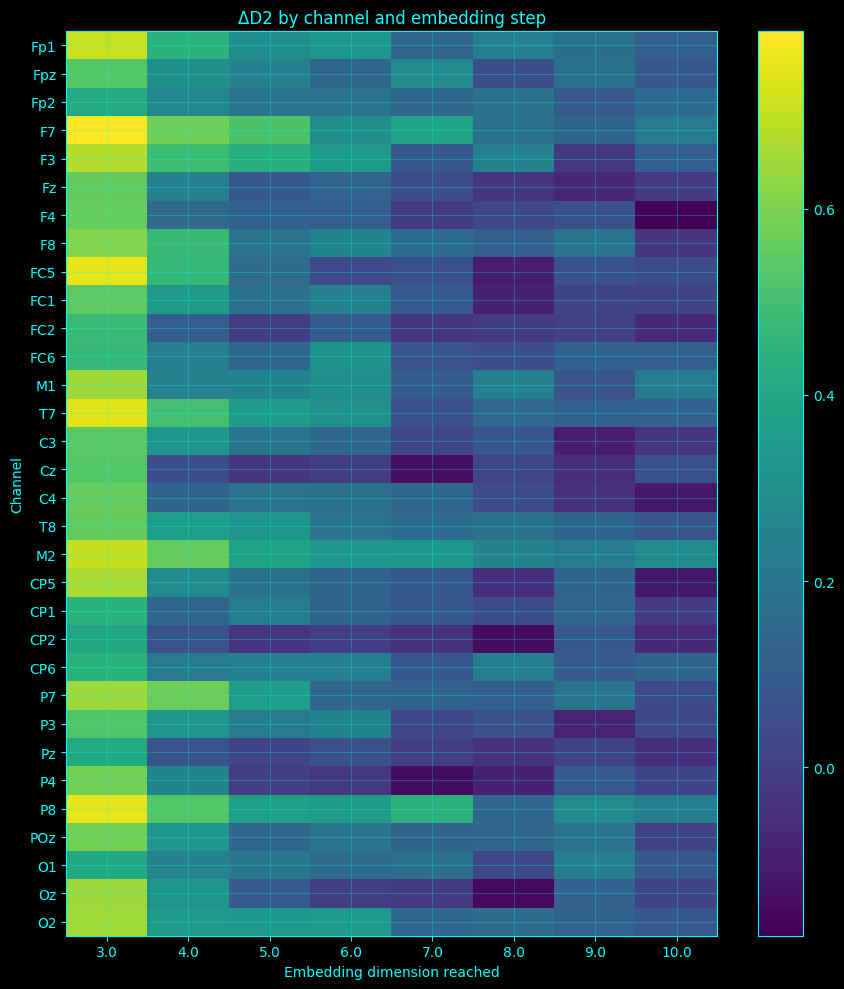

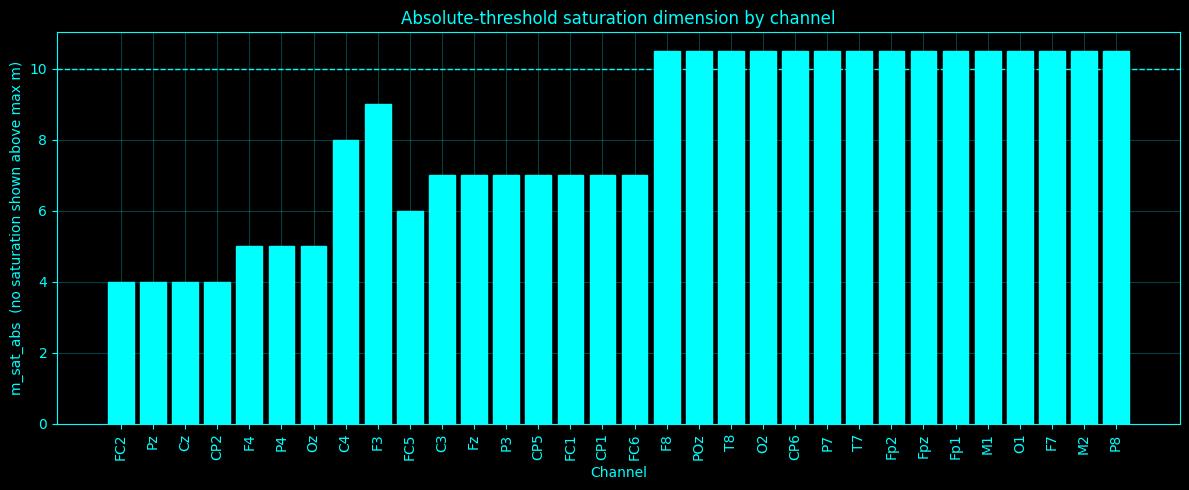

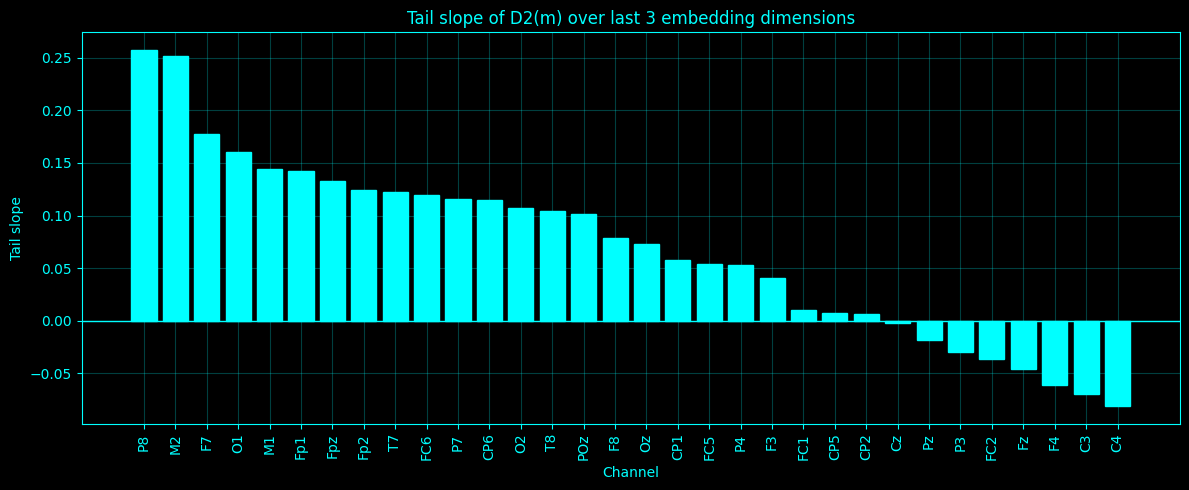

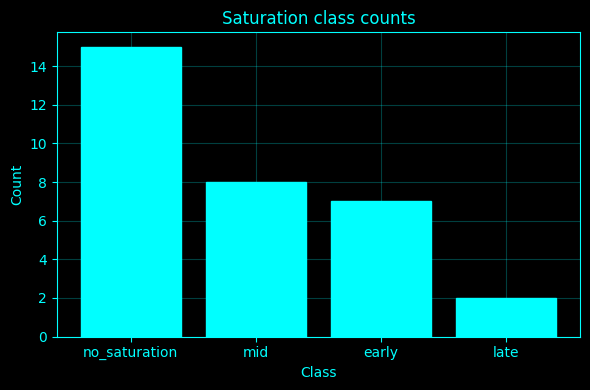


Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/dimension_saturation_profiling
Summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/dimension_saturation_profiling/dimension_saturation_summary.csv
Delta CSV: /home/a/projects/Complete-Neural-Signal-Analysis/dimension_saturation_profiling/dimension_saturation_deltas.csv
Summary TXT: /home/a/projects/Complete-Neural-Signal-Analysis/dimension_saturation_profiling/dimension_saturation_summary.txt


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
source_csv = os.path.join(base_dir, "embedded_fractal_dimension_research", "embedded_fractal_dimension_summary.csv")
out_dir = os.path.join(base_dir, "dimension_saturation_profiling")
os.makedirs(out_dir, exist_ok=True)

eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# Saturation rules
use_metric = "corr_dim_d2"   # use D2, not box-counting
abs_delta_thresh = 0.12      # absolute saturation threshold on ΔD2
rel_delta_thresh = 0.04      # relative saturation threshold on ΔD2 / D2
n_consecutive = 2            # require this many consecutive small increments
tail_points = 3              # slope over final tail

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE HELPER
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.25, color=ACCENT)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def first_consecutive_true(mask, n_consecutive=2):
    """
    mask is length K for steps between m_i and m_{i+1}
    returns starting index of first run of n_consecutive True
    """
    mask = np.asarray(mask, dtype=bool)
    if len(mask) < n_consecutive:
        return None

    run = 0
    for i, val in enumerate(mask):
        if val:
            run += 1
            if run >= n_consecutive:
                return i - n_consecutive + 1
        else:
            run = 0
    return None

def tail_slope(x, y, tail_points=3):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < max(2, tail_points):
        return np.nan

    x_tail = x[-tail_points:]
    y_tail = y[-tail_points:]
    coef = np.polyfit(x_tail, y_tail, 1)
    return float(coef[0])

def classify_saturation(m_sat, max_m):
    if pd.isna(m_sat):
        return "no_saturation"
    if m_sat <= 5:
        return "early"
    if m_sat <= 7:
        return "mid"
    if m_sat <= max_m - 1:
        return "late"
    return "no_saturation"

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
df = pd.read_csv(source_csv)

if use_metric not in df.columns:
    raise ValueError(f"Column '{use_metric}' not found in {source_csv}")

df = df[["channel", "emb_dim", use_metric]].copy()
df = df.rename(columns={use_metric: "D"})
df = df.sort_values(["channel", "emb_dim"]).reset_index(drop=True)

print("Loaded summary:")
print(df.head())

# -------------------------------------------------------
# PROFILE SATURATION PER CHANNEL
# -------------------------------------------------------
summary_rows = []
delta_rows = []

max_m_global = int(df["emb_dim"].max())

for ch in eeg_channel_names:
    sub = df[df["channel"] == ch].sort_values("emb_dim").copy()
    if len(sub) < 3:
        continue

    m = sub["emb_dim"].to_numpy(dtype=float)
    d2 = sub["D"].to_numpy(dtype=float)

    delta = np.diff(d2)
    delta_m = m[1:]  # delta corresponds to arriving at this embedding dimension
    rel_delta = delta / np.maximum(np.abs(d2[:-1]), 1e-12)

    # absolute-threshold saturation
    abs_mask = np.abs(delta) <= abs_delta_thresh
    abs_idx = first_consecutive_true(abs_mask, n_consecutive=n_consecutive)
    if abs_idx is None:
        m_sat_abs = np.nan
    else:
        m_sat_abs = delta_m[abs_idx]

    # relative-threshold saturation
    rel_mask = np.abs(rel_delta) <= rel_delta_thresh
    rel_idx = first_consecutive_true(rel_mask, n_consecutive=n_consecutive)
    if rel_idx is None:
        m_sat_rel = np.nan
    else:
        m_sat_rel = delta_m[rel_idx]

    # tail behavior
    slope_tail = tail_slope(m, d2, tail_points=tail_points)

    # plateau proxy after saturation
    if not pd.isna(m_sat_abs):
        sat_start_idx = np.where(m >= m_sat_abs)[0]
        if len(sat_start_idx) > 0:
            plateau_mean_abs = float(np.mean(d2[sat_start_idx[0]:]))
            plateau_std_abs = float(np.std(d2[sat_start_idx[0]:]))
        else:
            plateau_mean_abs = np.nan
            plateau_std_abs = np.nan
    else:
        plateau_mean_abs = np.nan
        plateau_std_abs = np.nan

    if not pd.isna(m_sat_rel):
        sat_start_idx = np.where(m >= m_sat_rel)[0]
        if len(sat_start_idx) > 0:
            plateau_mean_rel = float(np.mean(d2[sat_start_idx[0]:]))
            plateau_std_rel = float(np.std(d2[sat_start_idx[0]:]))
        else:
            plateau_mean_rel = np.nan
            plateau_std_rel = np.nan
    else:
        plateau_mean_rel = np.nan
        plateau_std_rel = np.nan

    summary_rows.append({
        "channel": ch,
        "m_min": float(np.min(m)),
        "m_max": float(np.max(m)),
        "D2_m2": float(d2[0]) if len(d2) > 0 else np.nan,
        "D2_mmax": float(d2[-1]) if len(d2) > 0 else np.nan,
        "D2_total_gain": float(d2[-1] - d2[0]) if len(d2) > 1 else np.nan,
        "mean_delta_D2": float(np.mean(delta)) if len(delta) > 0 else np.nan,
        "std_delta_D2": float(np.std(delta)) if len(delta) > 0 else np.nan,
        "tail_slope_last_points": slope_tail,
        "m_sat_abs": m_sat_abs,
        "m_sat_rel": m_sat_rel,
        "plateau_mean_abs": plateau_mean_abs,
        "plateau_std_abs": plateau_std_abs,
        "plateau_mean_rel": plateau_mean_rel,
        "plateau_std_rel": plateau_std_rel,
        "class_abs": classify_saturation(m_sat_abs, max_m_global),
        "class_rel": classify_saturation(m_sat_rel, max_m_global),
    })

    for mm, dd, rr in zip(delta_m, delta, rel_delta):
        delta_rows.append({
            "channel": ch,
            "emb_dim_to": mm,
            "delta_D2": dd,
            "rel_delta_D2": rr,
            "small_abs": abs(dd) <= abs_delta_thresh,
            "small_rel": abs(rr) <= rel_delta_thresh,
        })

summary_df = pd.DataFrame(summary_rows)
delta_df = pd.DataFrame(delta_rows)

summary_df = summary_df.sort_values(["class_abs", "m_sat_abs", "tail_slope_last_points"], na_position="last")
delta_df = delta_df.sort_values(["channel", "emb_dim_to"])

# -------------------------------------------------------
# SAVE TABLES
# -------------------------------------------------------
summary_csv = os.path.join(out_dir, "dimension_saturation_summary.csv")
delta_csv = os.path.join(out_dir, "dimension_saturation_deltas.csv")

summary_df.to_csv(summary_csv, index=False)
delta_df.to_csv(delta_csv, index=False)

print("\nSaturation summary:")
print(summary_df)

# -------------------------------------------------------
# PLOT 1: ALL CHANNELS D2(m) WITH ABS-SATURATION MARKERS
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 8), facecolor=BG)
style_ax(ax)

for ch in eeg_channel_names:
    sub = df[df["channel"] == ch].sort_values("emb_dim")
    if len(sub) == 0:
        continue

    ax.plot(
        sub["emb_dim"],
        sub["D"],
        marker="o",
        color=ACCENT,
        markerfacecolor=ACCENT,
        markeredgecolor=ACCENT,
        alpha=0.22
    )

    sat_row = summary_df[summary_df["channel"] == ch]
    if len(sat_row) > 0 and not pd.isna(sat_row.iloc[0]["m_sat_abs"]):
        m_sat = sat_row.iloc[0]["m_sat_abs"]
        y_sat = sub.loc[sub["emb_dim"] == m_sat, "D"]
        if len(y_sat) > 0:
            ax.scatter([m_sat], [y_sat.iloc[0]], s=60, facecolors="none", edgecolors=ACCENT, linewidths=1.5)

ax.set_title("Dimension-saturation profiling from D2(m)")
ax.set_xlabel("Embedding dimension m")
ax.set_ylabel("D2")

plot1_path = os.path.join(out_dir, "d2_saturation_profiles_all_channels.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 2: DELTA D2 HEATMAP
# -------------------------------------------------------
pivot_delta = delta_df.pivot_table(
    index="channel",
    columns="emb_dim_to",
    values="delta_D2",
    aggfunc="mean"
)
pivot_delta = pivot_delta.reindex(index=eeg_channel_names)

fig, ax = plt.subplots(figsize=(9, 10), facecolor=BG)
style_ax(ax)

im = ax.imshow(pivot_delta.values, aspect="auto")
ax.set_title("ΔD2 by channel and embedding step")
ax.set_xlabel("Embedding dimension reached")
ax.set_ylabel("Channel")
ax.set_xticks(np.arange(len(pivot_delta.columns)))
ax.set_xticklabels(pivot_delta.columns, color=ACCENT)
ax.set_yticks(np.arange(len(pivot_delta.index)))
ax.set_yticklabels(pivot_delta.index, color=ACCENT)

cbar = plt.colorbar(im, ax=ax)
cbar.ax.yaxis.set_tick_params(color=ACCENT)
plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)

plot2_path = os.path.join(out_dir, "delta_d2_heatmap.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 3: SATURATION DIMENSION BARPLOT
# -------------------------------------------------------
plot_df = summary_df.copy()
plot_df["m_sat_abs_plot"] = plot_df["m_sat_abs"].fillna(max_m_global + 0.5)

fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
style_ax(ax)

ax.bar(
    plot_df["channel"],
    plot_df["m_sat_abs_plot"],
    color=ACCENT,
    edgecolor=ACCENT
)
ax.axhline(max_m_global, color=ACCENT, linestyle="--", linewidth=1)
ax.set_title("Absolute-threshold saturation dimension by channel")
ax.set_xlabel("Channel")
ax.set_ylabel("m_sat_abs  (no saturation shown above max m)")
ax.tick_params(axis='x', rotation=90)

plot3_path = os.path.join(out_dir, "saturation_dimension_barplot.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 4: TAIL SLOPE BARPLOT
# -------------------------------------------------------
tail_df = summary_df.sort_values("tail_slope_last_points", ascending=False)

fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
style_ax(ax)

ax.bar(
    tail_df["channel"],
    tail_df["tail_slope_last_points"],
    color=ACCENT,
    edgecolor=ACCENT
)
ax.axhline(0, color=ACCENT, linewidth=1)
ax.set_title(f"Tail slope of D2(m) over last {tail_points} embedding dimensions")
ax.set_xlabel("Channel")
ax.set_ylabel("Tail slope")
ax.tick_params(axis='x', rotation=90)

plot4_path = os.path.join(out_dir, "tail_slope_barplot.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 5: CLASS COUNTS
# -------------------------------------------------------
class_counts = summary_df["class_abs"].value_counts()

fig, ax = plt.subplots(figsize=(6, 4), facecolor=BG)
style_ax(ax)

ax.bar(
    class_counts.index,
    class_counts.values,
    color=ACCENT,
    edgecolor=ACCENT
)
ax.set_title("Saturation class counts")
ax.set_xlabel("Class")
ax.set_ylabel("Count")

plot5_path = os.path.join(out_dir, "saturation_class_counts.png")
plt.tight_layout()
plt.savefig(plot5_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# SAVE TEXT SUMMARY
# -------------------------------------------------------
txt_path = os.path.join(out_dir, "dimension_saturation_summary.txt")
with open(txt_path, "w") as f:
    f.write("Dimension-saturation profiling per channel\n")
    f.write("=========================================\n\n")
    f.write(f"Source CSV: {source_csv}\n")
    f.write(f"Metric used: {use_metric}\n")
    f.write(f"Absolute delta threshold: {abs_delta_thresh}\n")
    f.write(f"Relative delta threshold: {rel_delta_thresh}\n")
    f.write(f"Consecutive small increments required: {n_consecutive}\n")
    f.write(f"Tail points for slope: {tail_points}\n\n")

    f.write("Class counts (absolute threshold):\n")
    for k, v in class_counts.items():
        f.write(f"  {k}: {v}\n")

    f.write("\nTop channels with strongest continuing growth (largest tail slope):\n")
    tmp = summary_df.sort_values("tail_slope_last_points", ascending=False).head(10)
    for _, row in tmp.iterrows():
        f.write(
            f"  {row['channel']}: tail_slope={row['tail_slope_last_points']:.6f}, "
            f"m_sat_abs={row['m_sat_abs']}, D2_gain={row['D2_total_gain']:.6f}\n"
        )

    f.write("\nTop channels with earliest apparent saturation:\n")
    tmp = summary_df.dropna(subset=["m_sat_abs"]).sort_values("m_sat_abs", ascending=True).head(10)
    for _, row in tmp.iterrows():
        f.write(
            f"  {row['channel']}: m_sat_abs={row['m_sat_abs']}, "
            f"tail_slope={row['tail_slope_last_points']:.6f}, "
            f"plateau_mean_abs={row['plateau_mean_abs']:.6f}\n"
        )

print(f"\nSaved outputs to: {out_dir}")
print(f"Summary CSV: {summary_csv}")
print(f"Delta CSV: {delta_csv}")
print(f"Summary TXT: {txt_path}")

### Katz Fractal Dimension


<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>The provided Python code illustrates the application of the Katz Fractal Dimension (FD) calculation to datasets, potentially including EEG data, to assess their complexity from a multidisciplinary theoretical standpoint. This explanation delves into concepts from information theory, systems theory, physics, chaos theory, dynamical systems, neuroscience, signal processing, and theoretical mathematics to elucidate the underpinnings of the Katz FD method and its relevance to the analysis of complex systems.</p>
        <h2>Katz Fractal Dimension (FD)</h2>
        <p>The Katz FD is a measure designed to quantify the fractal dimension of a curve representing a time series or a spatial path in a multi-dimensional space. It essentially provides an index of complexity, describing how a pattern fills space. The FD is particularly useful in the analysis of physiological signals like EEG, where the complexity of the signal can relate to different neurological states or conditions.</p>
        <h2>Mathematical Foundation</h2>
        <p>The calculation of the Katz FD involves several steps:</p>
        <ul>
            <li>For 1-dimensional data, the method computes the total path length \(L\) as the sum of the absolute differences between consecutive points.</li>
            <li>For multi-dimensional data, the Euclidean distance between consecutive points in space is calculated, summing these to find the total path length \(L\).</li>
        </ul>
        <p>End-to-end Distance (\(d\)): This is the straight-line distance from the first point in the dataset to the last, capturing the overall scale of the pattern’s spread.</p>
        <p>Fractal Dimension Formula: The Katz FD is given by the formula \(FD = \frac{\log_{10}(n)}{\log_{10}(d) + \log_{10}(L/d)}\), where \(n\) is the total number of points in the dataset. This formula essentially compares the logarithm of the path length to the logarithm of the end-to-end distance, normalized by the number of steps, to yield a dimensionless measure that indicates the signal's fractality or complexity.</p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Theoretical Implications</h2>
        <p>Information Theory: The Katz FD can be seen as a measure of the information content of the signal, where more complex signals (higher FD) contain more information due to their intricate structure.</p>
        <p>Systems Theory and Dynamical Systems: The FD offers insights into the system's dynamics, with higher values suggesting more complex, possibly chaotic behavior. It's a tool for understanding the order and patterns within the system's state changes over time.</p>
        <p>Neuroscience and Signal Processing: In neuroscience, the Katz FD of EEG data can indicate changes in brain state, such as transitions between different phases of sleep or detecting pathological states like seizures, based on the complexity of neural oscillations.</p>
        <p>Physics and Chaos Theory: The concept of fractal dimensions is closely related to chaos theory, which studies systems with complex, dynamic behavior. The Katz FD helps in quantifying the extent of chaos or order within a system, reflecting its sensitivity to initial conditions and long-term predictability.</p>
        <h2>Computational Implementation</h2>
        <p>The script iterates over .npy files within a designated directory, applying the Katz FD calculation to each dataset. This approach is particularly useful in neuroscience for analyzing EEG data, where signal complexity can correlate with various physiological and pathological states.</p>
        <h2>Application in Neuroscience</h2>
        <p>In the context of EEG analysis, the Katz FD provides a quantitative measure of the complexity of neural activity, offering potential insights into brain dynamics, cognitive states, and neurological disorders. It serves as a tool for identifying changes in neural patterns that may not be evident through traditional analysis methods.</p>
        <h2>Conclusion</h2>
        <p>This methodology exemplifies the interdisciplinary application of mathematical concepts to neuroscience, leveraging the Katz Fractal Dimension to explore the complexities of EEG data. It underscores the utility of fractal analysis in enhancing our understanding of the intricate dynamics of neural signals.</p>
    </div>
</div>


Using embedding directories:
  /home/a/projects/Complete-Neural-Signal-Analysis/embedding_data/2dembedding_data
  /home/a/projects/Complete-Neural-Signal-Analysis/embedding_data/3dembedding_data
  /home/a/projects/Complete-Neural-Signal-Analysis/embedding_data/embeddings_4to10

Found 289 embedding files total.
[1/289] 2dembedded_C3.npy -> Katz FD = 6.035086
[2/289] 2dembedded_C4.npy -> Katz FD = 4.686693
[3/289] 2dembedded_CP1.npy -> Katz FD = 4.543295
[4/289] 2dembedded_CP2.npy -> Katz FD = 5.366357
[5/289] 2dembedded_CP5.npy -> Katz FD = 49.566601
[6/289] 2dembedded_CP6.npy -> Katz FD = 4.441185
[7/289] 2dembedded_Cz.npy -> Katz FD = 6.782598
[8/289] 2dembedded_F3.npy -> Katz FD = 12.250158
[9/289] 2dembedded_F4.npy -> Katz FD = 52.325536
[10/289] 2dembedded_F7.npy -> Katz FD = 8.841996
[11/289] 2dembedded_F8.npy -> Katz FD = 52.014781
[12/289] 2dembedded_FC1.npy -> Katz FD = 5.997993
[13/289] 2dembedded_FC2.npy -> Katz FD = -14.333982
[14/289] 2dembedded_FC5.npy -> Katz FD = 18.4741

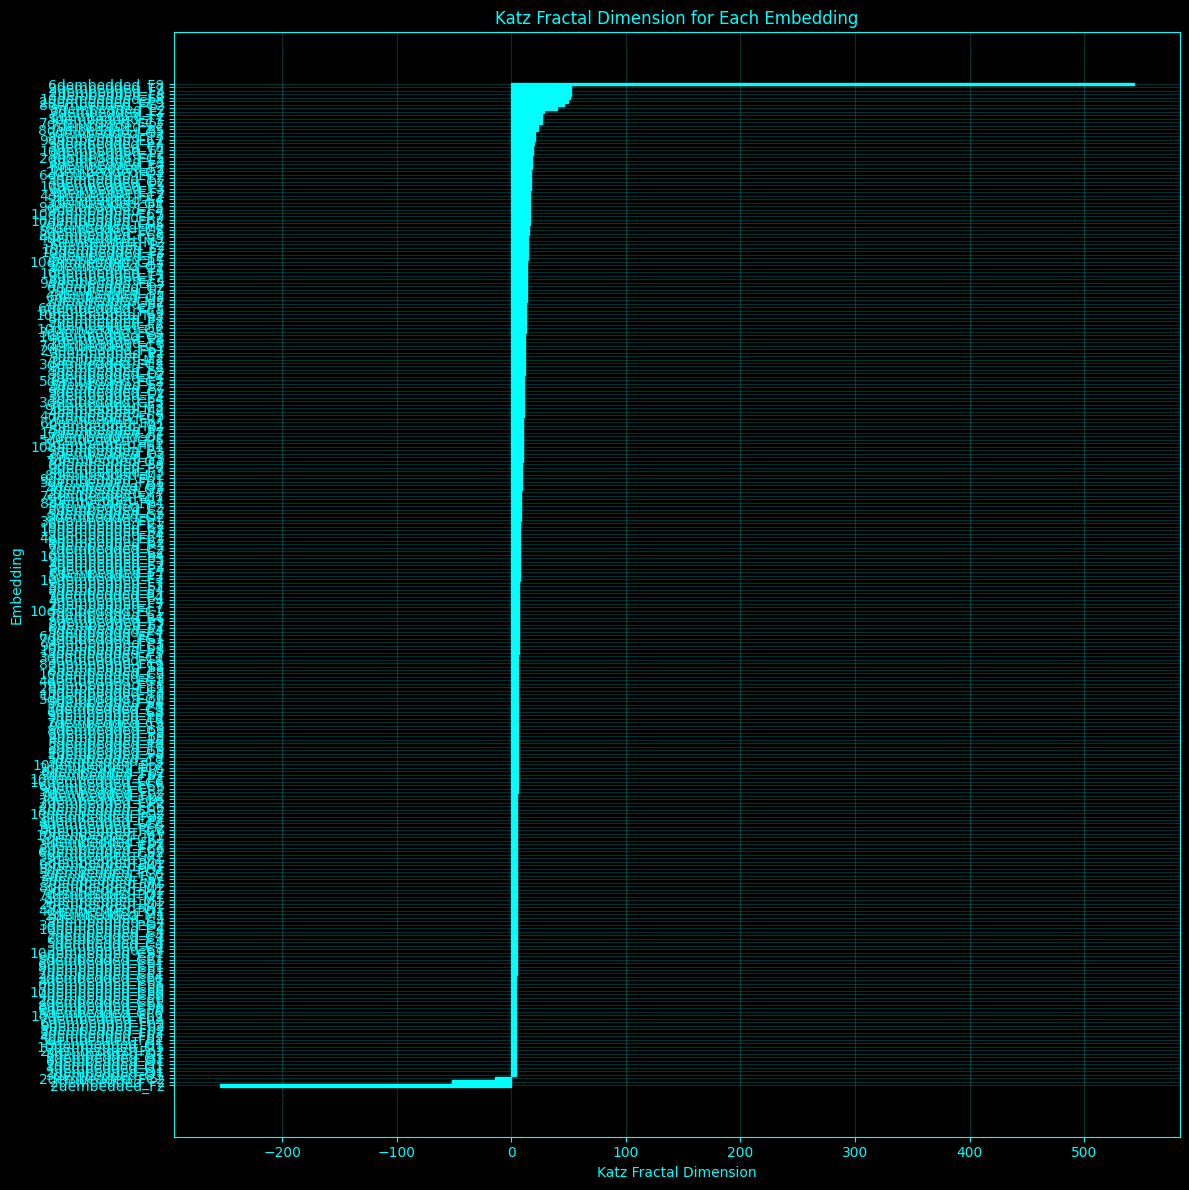

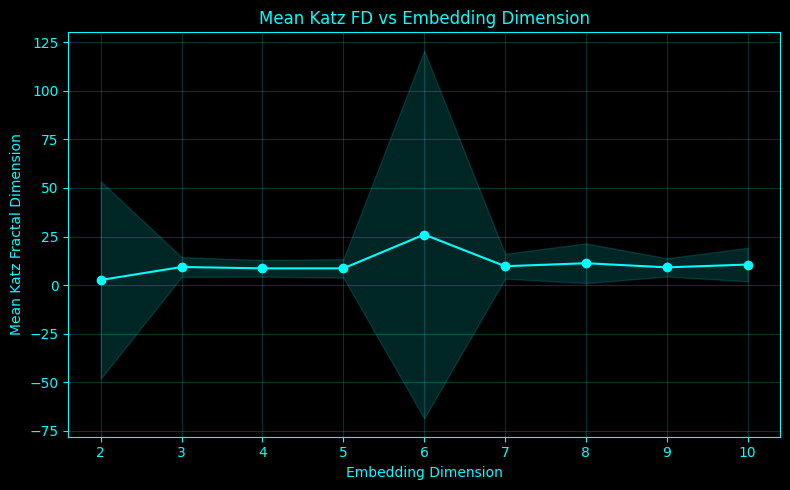

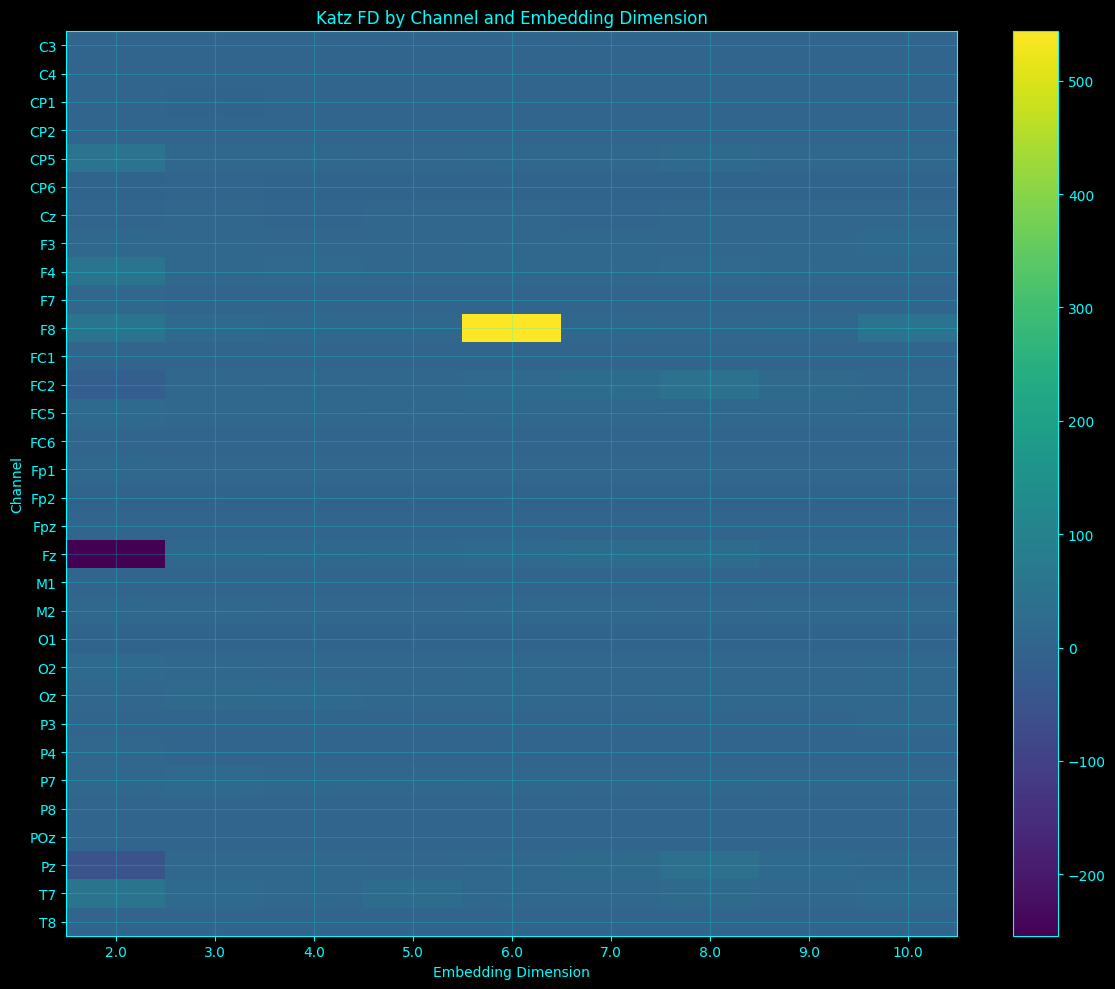

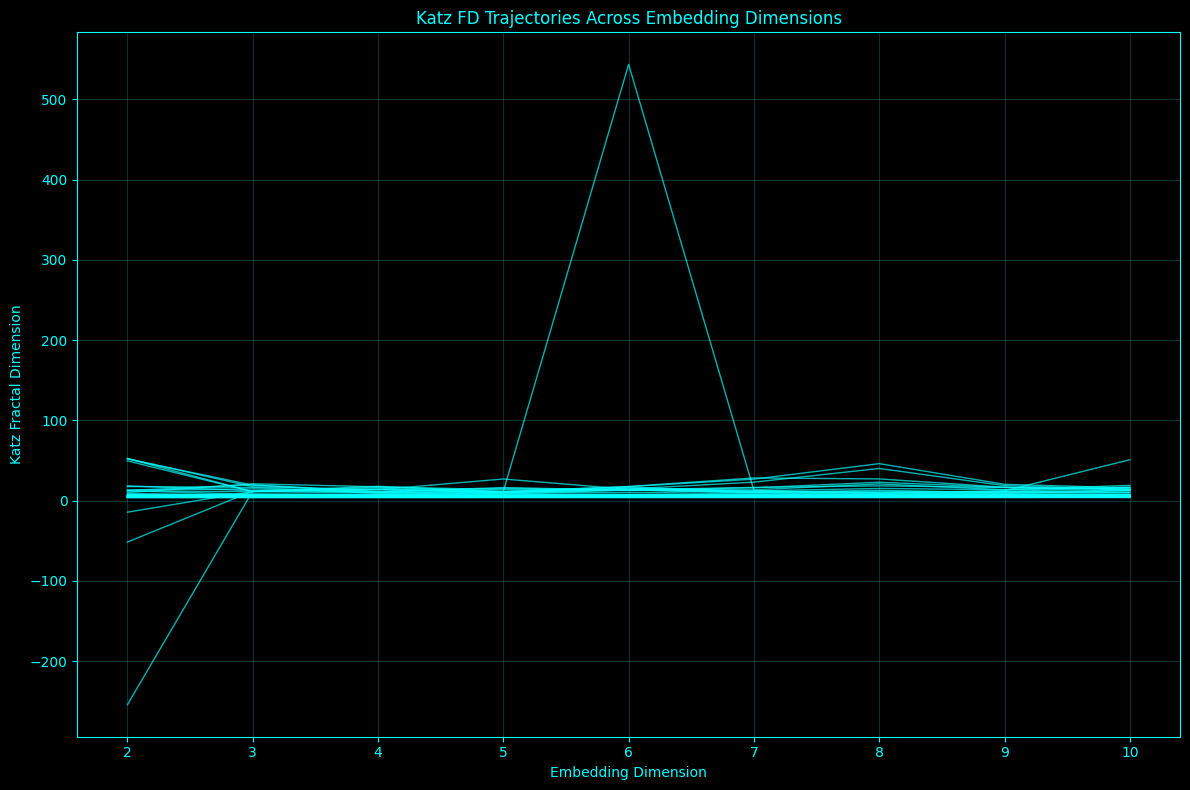


Saved main CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/katz_fractal_dimension/katz_fd_per_embedding.csv
Saved by-dimension CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/katz_fractal_dimension/katz_fd_by_dimension.csv
Saved by-channel CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/katz_fractal_dimension/katz_fd_by_channel.csv
Saved matrix CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/katz_fractal_dimension/katz_fd_channel_dimension_matrix.csv
Saved summary TXT: /home/a/projects/Complete-Neural-Signal-Analysis/results/katz_fractal_dimension/katz_fd_summary.txt
Saved plots to: /home/a/projects/Complete-Neural-Signal-Analysis/results/katz_fractal_dimension/plots


In [2]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

embedding_dirs = [
    os.path.join(base_dir, "embedding_data", "2dembedding_data"),
    os.path.join(base_dir, "embedding_data", "3dembedding_data"),
    os.path.join(base_dir, "embedding_data", "embeddings_4to10"),
]

out_dir = os.path.join(base_dir, "results", "katz_fractal_dimension")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

ACCENT = "cyan"
BG = "black"
eps = 1e-12

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def gather_embedding_files(search_dirs):
    files = []
    used_dirs = []
    for d in search_dirs:
        if os.path.isdir(d):
            these = sorted(glob.glob(os.path.join(d, "*.npy")))
            if these:
                used_dirs.append(d)
                files.extend(these)
    return used_dirs, sorted(files)

def infer_embedding_dim(stem, data):
    m = re.match(r"^(\d+)dembedded_", stem)
    if m:
        return int(m.group(1))
    if data.ndim == 2:
        return int(data.shape[1])
    return np.nan

def infer_channel_name(stem):
    if "dembedded_" in stem:
        return stem.split("dembedded_", 1)[1]
    return stem

def katz_fd(data):
    """
    Katz fractal dimension for a trajectory.

    Works for:
    - 1D signal: shape (N,)
    - embedded trajectory: shape (N, D)
    """
    x = np.asarray(data, dtype=float)

    if x.ndim == 1:
        n = len(x)
        if n < 2:
            return np.nan

        step_dist = np.abs(np.diff(x))
        L = np.sum(step_dist)
        d = np.abs(x[-1] - x[0])

    elif x.ndim == 2:
        n = x.shape[0]
        if n < 2:
            return np.nan

        diffs = np.diff(x, axis=0)
        step_dist = np.sqrt(np.sum(diffs ** 2, axis=1))
        L = np.sum(step_dist)
        d = np.sqrt(np.sum((x[-1] - x[0]) ** 2))

    else:
        raise ValueError(f"Unsupported array shape for Katz FD: {x.shape}")

    if L <= 0 or d <= 0:
        return np.nan

    # Equivalent stable form of Katz FD
    # FD = log10(n) / (log10(d/L) + log10(n))
    fd = np.log10(n) / (np.log10(d / (L + eps)) + np.log10(n) + eps)
    return float(fd)

# -------------------------------------------------------
# FIND FILES
# -------------------------------------------------------
used_dirs, file_paths = gather_embedding_files(embedding_dirs)

if not file_paths:
    raise FileNotFoundError(
        "No embedding .npy files found in:\n" + "\n".join(embedding_dirs)
    )

print("Using embedding directories:")
for d in used_dirs:
    print(" ", d)

print(f"\nFound {len(file_paths)} embedding files total.")

# -------------------------------------------------------
# COMPUTE KATZ FD
# -------------------------------------------------------
records = []

for idx, fp in enumerate(file_paths, start=1):
    file_name = os.path.basename(fp)
    stem = os.path.splitext(file_name)[0]

    rec = {
        "file": file_name,
        "stem": stem,
        "path": fp,
        "source_dir": os.path.basename(os.path.dirname(fp)),
        "channel": None,
        "embedding_dimension": None,
        "n_samples": None,
        "state_dim": None,
        "katz_fd": np.nan,
        "status": "ok",
        "error": "",
    }

    try:
        data = np.load(fp, allow_pickle=True)
        data = np.asarray(data, dtype=float)

        rec["n_samples"] = int(data.shape[0]) if data.ndim >= 1 else np.nan
        rec["state_dim"] = int(data.shape[1]) if data.ndim == 2 else 1
        rec["embedding_dimension"] = infer_embedding_dim(stem, data)
        rec["channel"] = infer_channel_name(stem)
        rec["katz_fd"] = katz_fd(data)

        print(f"[{idx}/{len(file_paths)}] {file_name} -> Katz FD = {rec['katz_fd']:.6f}")

    except Exception as e:
        rec["status"] = "error"
        rec["error"] = f"{type(e).__name__}: {e}"
        print(f"[{idx}/{len(file_paths)}] {file_name} -> ERROR: {rec['error']}")

    records.append(rec)

df = pd.DataFrame(records)

# -------------------------------------------------------
# SAVE MAIN CSV
# -------------------------------------------------------
results_csv = os.path.join(out_dir, "katz_fd_per_embedding.csv")
df.to_csv(results_csv, index=False)

# -------------------------------------------------------
# FILTER SUCCESSFUL RESULTS
# -------------------------------------------------------
df_ok = df[df["status"] == "ok"].copy()
df_ok = df_ok[np.isfinite(df_ok["katz_fd"])].copy()

if df_ok.empty:
    raise ValueError("No valid Katz FD results were computed.")

# -------------------------------------------------------
# SUMMARY TABLES
# -------------------------------------------------------
by_dim_df = (
    df_ok.groupby("embedding_dimension", dropna=True)
    .agg(
        n_records=("katz_fd", "count"),
        mean_katz_fd=("katz_fd", "mean"),
        std_katz_fd=("katz_fd", "std"),
        min_katz_fd=("katz_fd", "min"),
        max_katz_fd=("katz_fd", "max"),
    )
    .reset_index()
    .sort_values("embedding_dimension")
)

by_channel_df = (
    df_ok.groupby("channel", dropna=True)
    .agg(
        n_records=("katz_fd", "count"),
        mean_katz_fd=("katz_fd", "mean"),
        std_katz_fd=("katz_fd", "std"),
        min_katz_fd=("katz_fd", "min"),
        max_katz_fd=("katz_fd", "max"),
    )
    .reset_index()
    .sort_values("channel")
)

channel_dim_matrix = df_ok.pivot_table(
    index="channel",
    columns="embedding_dimension",
    values="katz_fd",
    aggfunc="mean"
).sort_index()

by_dim_csv = os.path.join(out_dir, "katz_fd_by_dimension.csv")
by_channel_csv = os.path.join(out_dir, "katz_fd_by_channel.csv")
matrix_csv = os.path.join(out_dir, "katz_fd_channel_dimension_matrix.csv")

by_dim_df.to_csv(by_dim_csv, index=False)
by_channel_df.to_csv(by_channel_csv, index=False)
channel_dim_matrix.to_csv(matrix_csv)

summary_txt = os.path.join(out_dir, "katz_fd_summary.txt")
with open(summary_txt, "w") as f:
    f.write("Katz Fractal Dimension Summary\n")
    f.write("=============================\n\n")
    f.write(f"Total files found: {len(file_paths)}\n")
    f.write(f"Successful results: {len(df_ok)}\n")
    f.write(f"Errors: {int((df['status'] == 'error').sum())}\n\n")

    f.write("Embedding directories used:\n")
    for d in used_dirs:
        f.write(f"  {d}\n")

    f.write("\nMean Katz FD by embedding dimension:\n")
    for _, row in by_dim_df.iterrows():
        f.write(
            f"  {int(row['embedding_dimension'])}D: "
            f"n={int(row['n_records'])}, "
            f"mean={row['mean_katz_fd']:.6f}, "
            f"std={0.0 if pd.isna(row['std_katz_fd']) else row['std_katz_fd']:.6f}\n"
        )

# -------------------------------------------------------
# PLOT 1: BARH OF ALL EMBEDDINGS
# -------------------------------------------------------
plot_df = df_ok.sort_values("katz_fd", ascending=True)

fig, ax = plt.subplots(figsize=(12, 12), facecolor=BG)
style_ax(ax)

ax.barh(
    plot_df["stem"].values,
    plot_df["katz_fd"].values,
    color=ACCENT,
    edgecolor=ACCENT
)
ax.set_title("Katz Fractal Dimension for Each Embedding")
ax.set_xlabel("Katz Fractal Dimension")
ax.set_ylabel("Embedding")

plot1_path = os.path.join(plots_dir, "katz_fd_all_embeddings_barh.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 2: MEAN KATZ FD VS EMBEDDING DIMENSION
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
style_ax(ax)

x = by_dim_df["embedding_dimension"].values
y = by_dim_df["mean_katz_fd"].values
s = by_dim_df["std_katz_fd"].fillna(0.0).values

ax.plot(x, y, marker="o", color=ACCENT, linewidth=1.5)
ax.fill_between(x, y - s, y + s, color=ACCENT, alpha=0.15)
ax.set_title("Mean Katz FD vs Embedding Dimension")
ax.set_xlabel("Embedding Dimension")
ax.set_ylabel("Mean Katz Fractal Dimension")

plot2_path = os.path.join(plots_dir, "mean_katz_fd_vs_dimension.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 3: CHANNEL x DIMENSION HEATMAP
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 10), facecolor=BG)
style_ax(ax)

heat_vals = channel_dim_matrix.values.astype(float)
plot_vals = np.where(np.isnan(heat_vals), 0.0, heat_vals)

im = ax.imshow(plot_vals, aspect="auto")
ax.set_title("Katz FD by Channel and Embedding Dimension")
ax.set_xlabel("Embedding Dimension")
ax.set_ylabel("Channel")
ax.set_xticks(np.arange(len(channel_dim_matrix.columns)))
ax.set_xticklabels(channel_dim_matrix.columns.values)
ax.set_yticks(np.arange(len(channel_dim_matrix.index)))
ax.set_yticklabels(channel_dim_matrix.index.values)

cbar = plt.colorbar(im, ax=ax)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot3_path = os.path.join(plots_dir, "katz_fd_channel_dimension_heatmap.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 4: CHANNEL TRAJECTORIES ACROSS DIMENSIONS
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 8), facecolor=BG)
style_ax(ax)

for ch in channel_dim_matrix.index:
    y = channel_dim_matrix.loc[ch].values.astype(float)
    x = np.array(channel_dim_matrix.columns.values, dtype=float)
    mask = np.isfinite(y)
    if np.sum(mask) >= 2:
        ax.plot(x[mask], y[mask], color=ACCENT, linewidth=1.0, alpha=0.7)

ax.set_title("Katz FD Trajectories Across Embedding Dimensions")
ax.set_xlabel("Embedding Dimension")
ax.set_ylabel("Katz Fractal Dimension")

plot4_path = os.path.join(plots_dir, "katz_fd_trajectories_across_dimensions.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved main CSV: {results_csv}")
print(f"Saved by-dimension CSV: {by_dim_csv}")
print(f"Saved by-channel CSV: {by_channel_csv}")
print(f"Saved matrix CSV: {matrix_csv}")
print(f"Saved summary TXT: {summary_txt}")
print(f"Saved plots to: {plots_dir}")

### Wavelet-Based Fractal Analysis

Running manual wavelet Hurst analysis with fast options
FAST_OPTION: ultra
Wavelet: haar
Requested max_level: 5
Temporal stability enabled: True
Loaded EEG shape: (4227788, 32)
Using segment: [814.571, 921.515] sec
Segment shape: (106944, 32)
Fp1: H=0.332388 | D≈1.667612 | R²=0.707782 | levels=5 | 0.654s
Fpz: H=0.313869 | D≈1.686131 | R²=0.658950 | levels=5 | 0.666s
Fp2: H=0.337692 | D≈1.662308 | R²=0.701391 | levels=5 | 0.662s
F7: H=0.206144 | D≈1.793856 | R²=0.281318 | levels=5 | 0.666s
F3: H=0.162726 | D≈1.837274 | R²=0.166744 | levels=5 | 0.662s
Fz: H=0.186824 | D≈1.813176 | R²=0.239644 | levels=5 | 0.670s
F4: H=0.175662 | D≈1.824338 | R²=0.180620 | levels=5 | 0.683s
F8: H=0.219604 | D≈1.780396 | R²=0.293555 | levels=5 | 0.670s
FC5: H=0.185036 | D≈1.814964 | R²=0.194978 | levels=5 | 0.666s
FC1: H=0.106883 | D≈1.893117 | R²=0.054588 | levels=5 | 0.662s
FC2: H=0.112412 | D≈1.887588 | R²=0.061571 | levels=5 | 0.661s
FC6: H=0.173679 | D≈1.826321 | R²=0.165353 | levels=5 | 0.665s
M1: H=

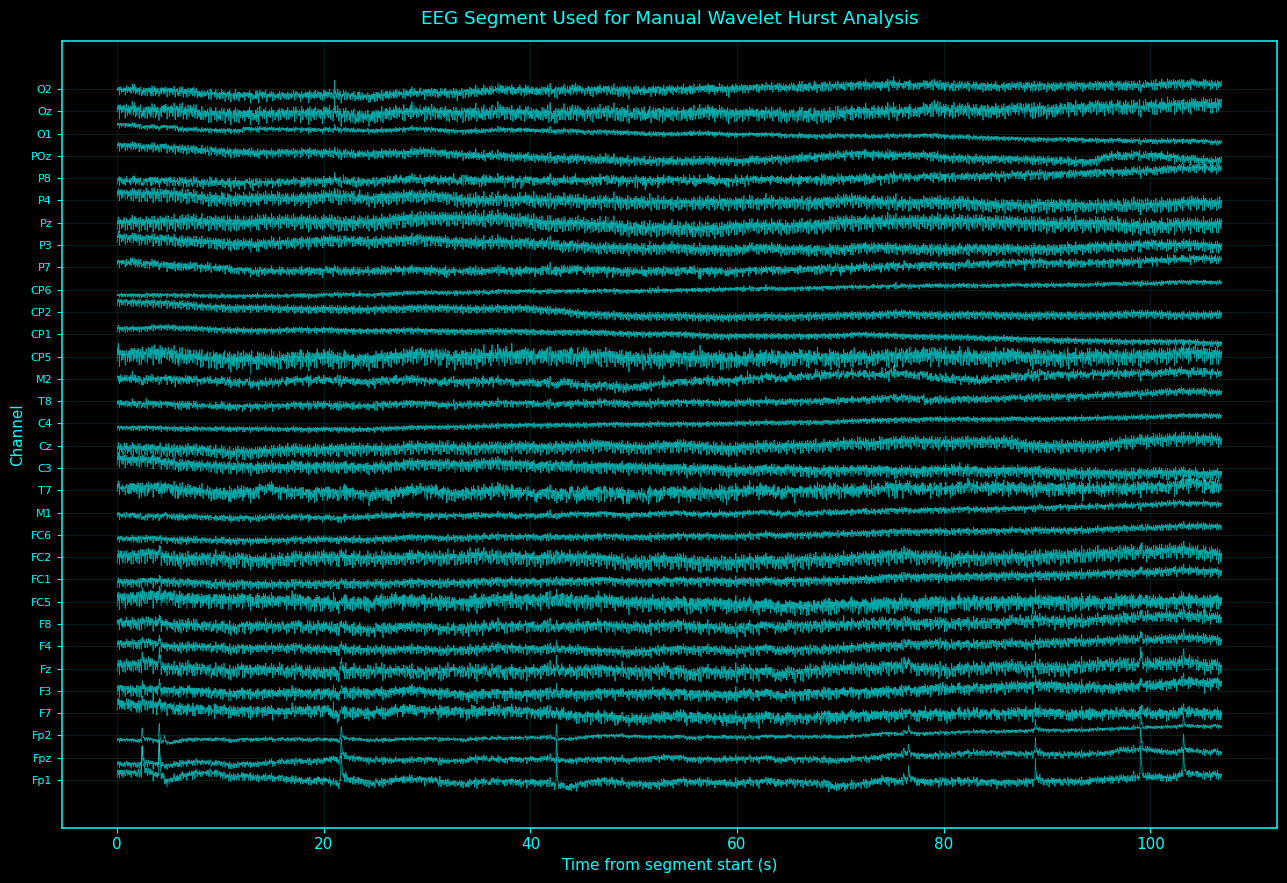

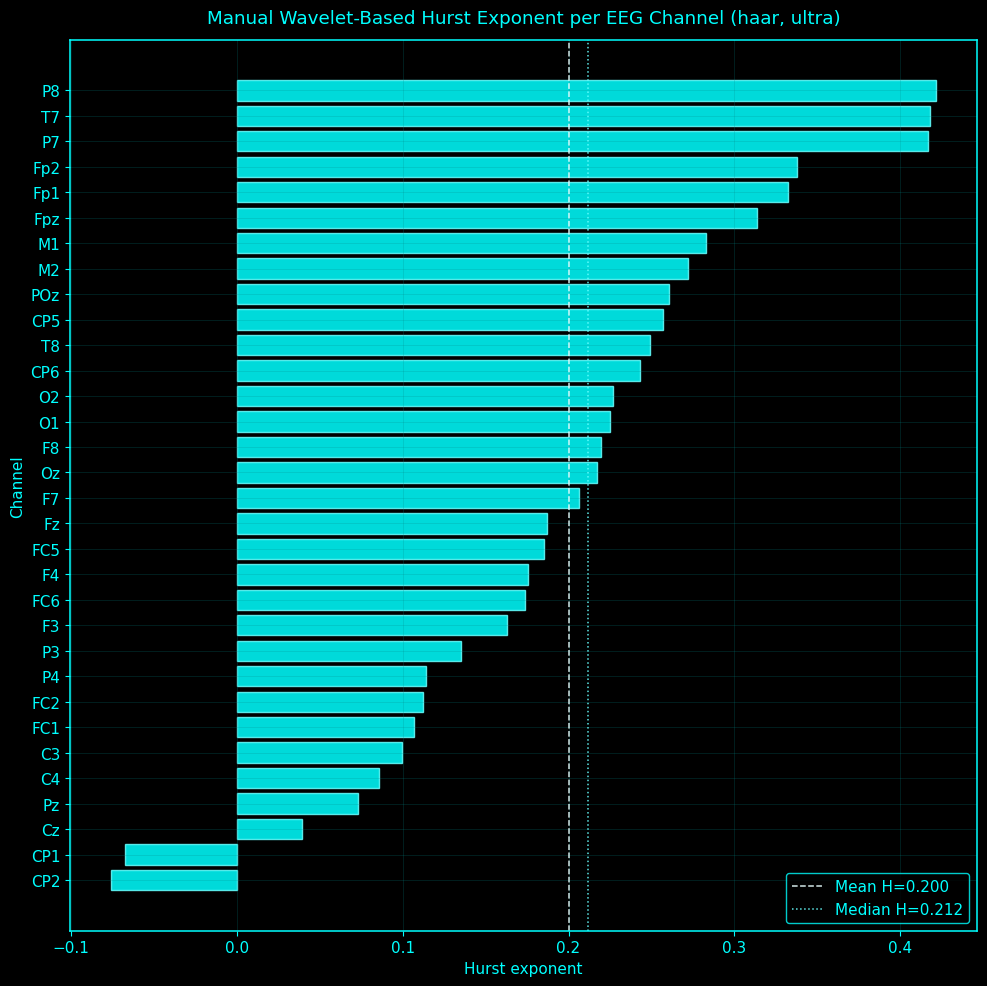

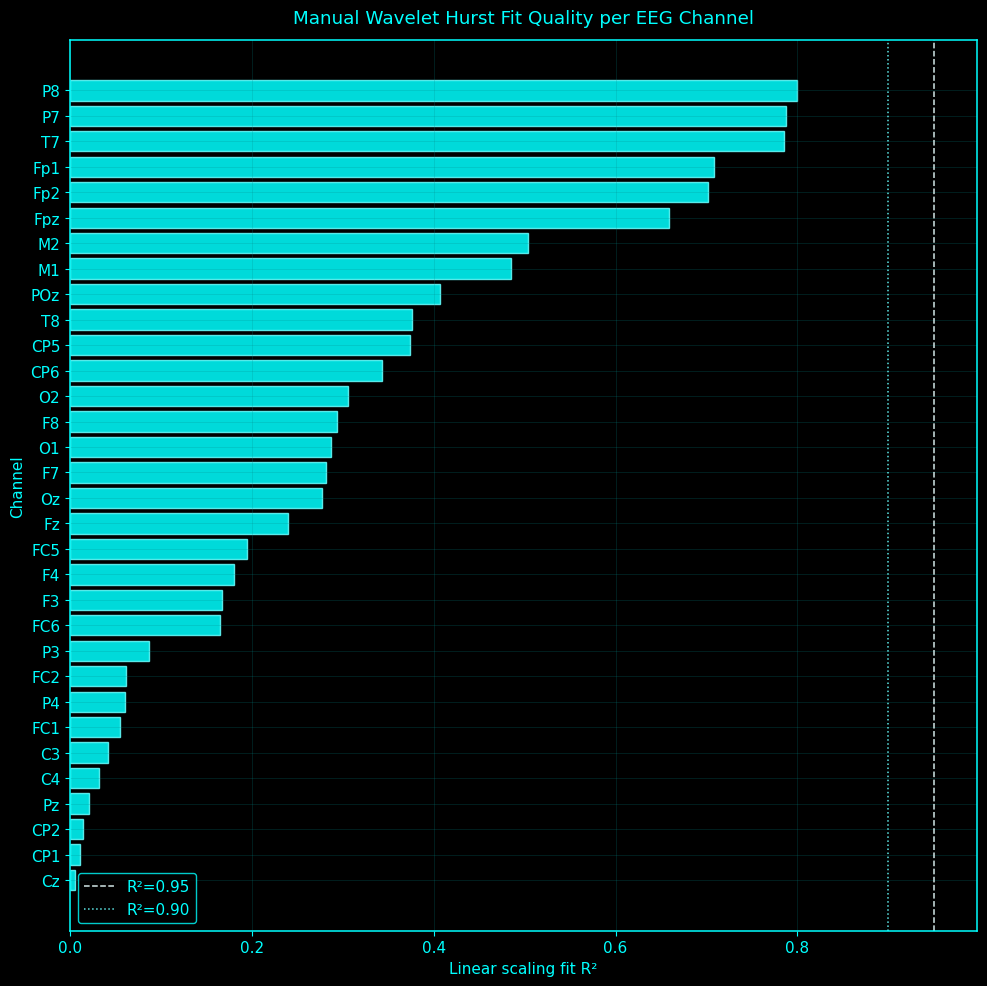

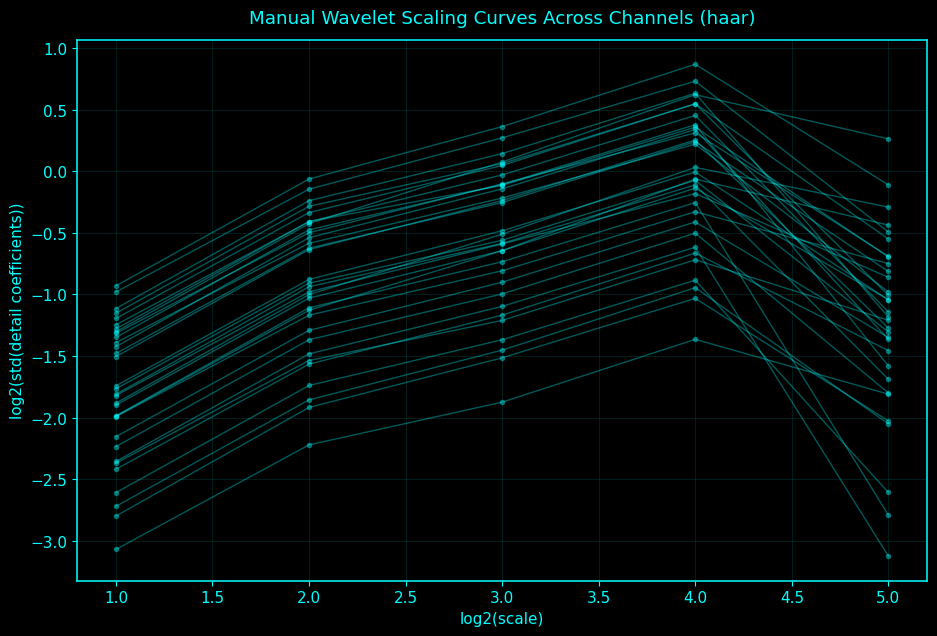

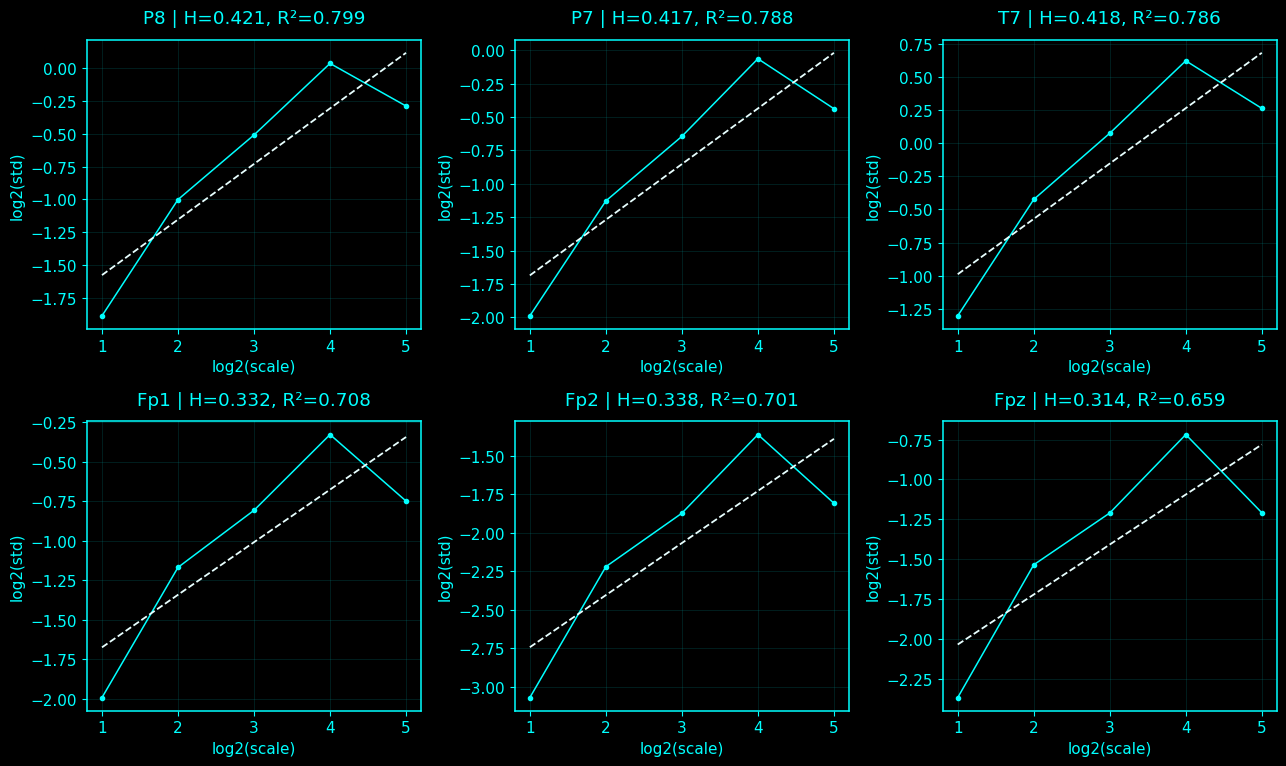

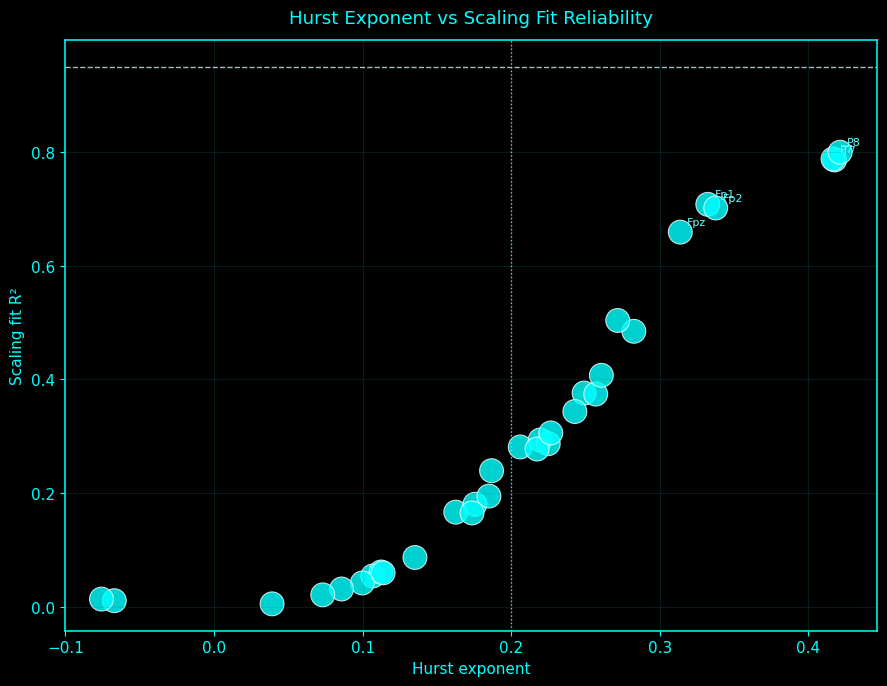

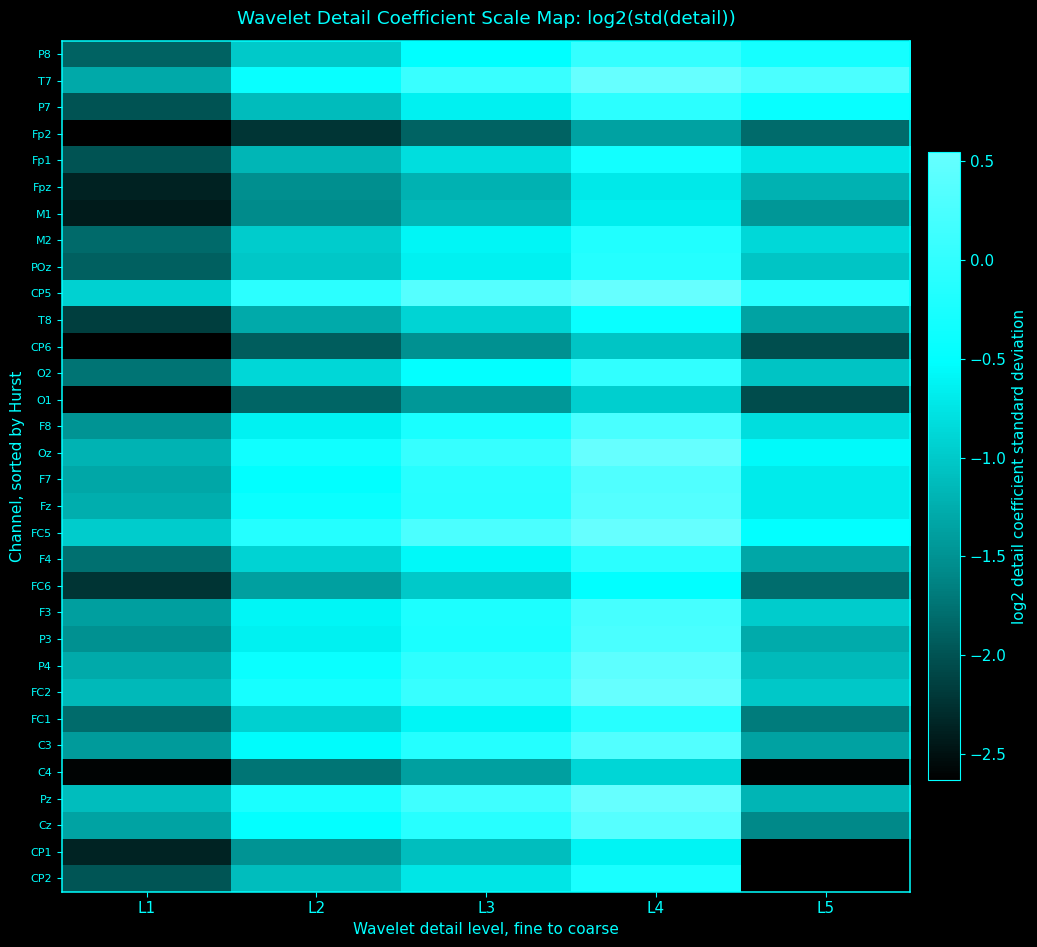

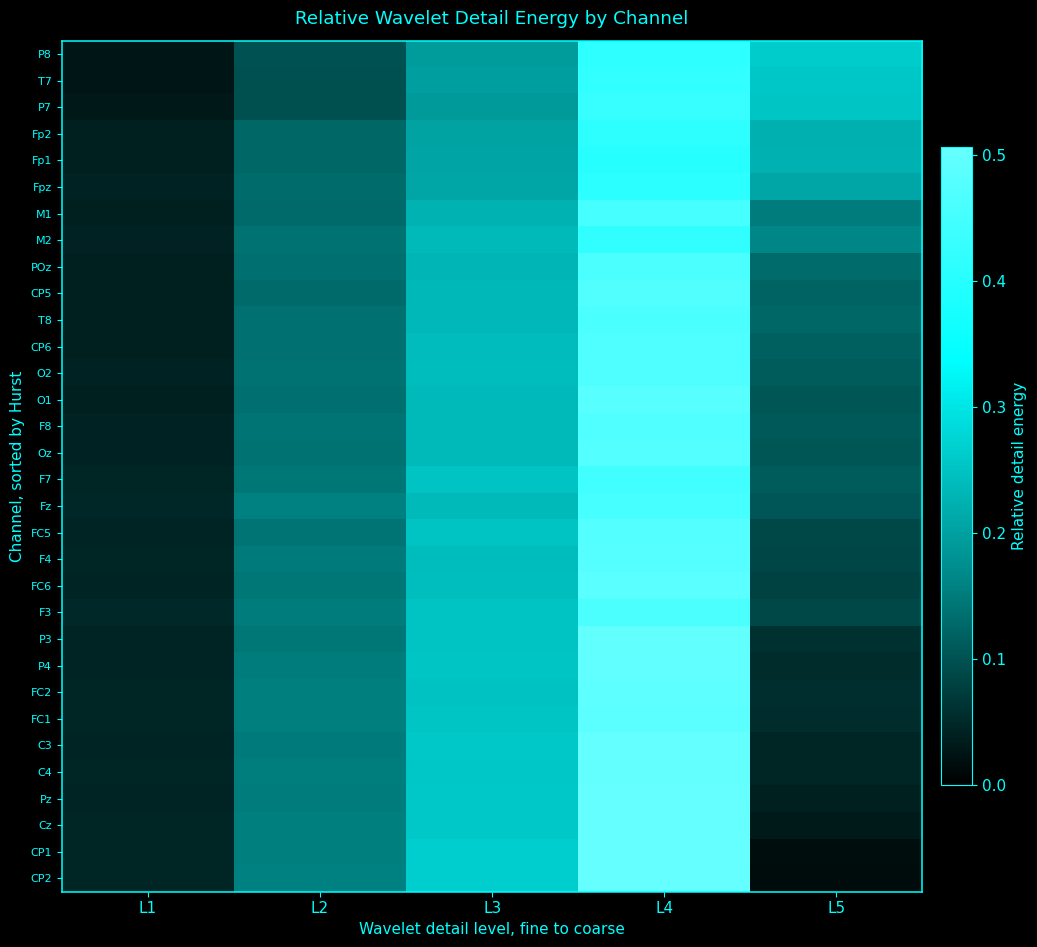

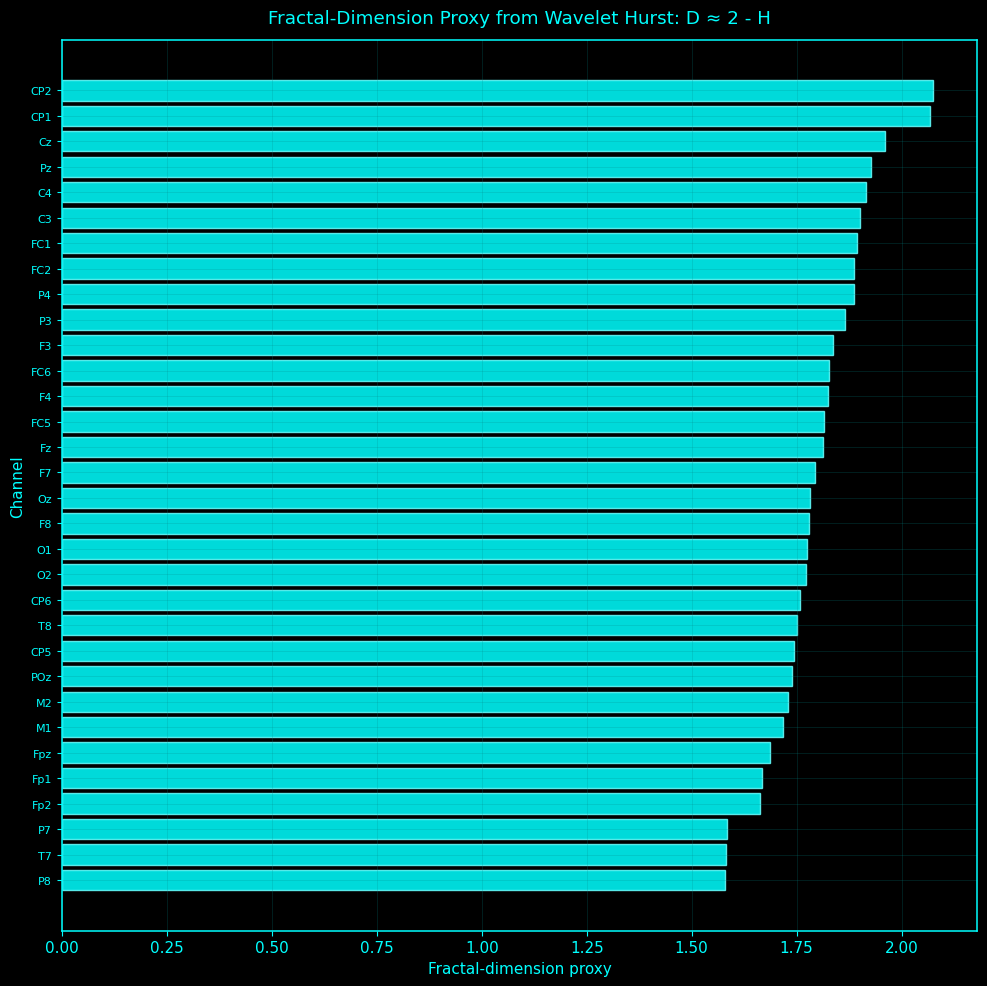

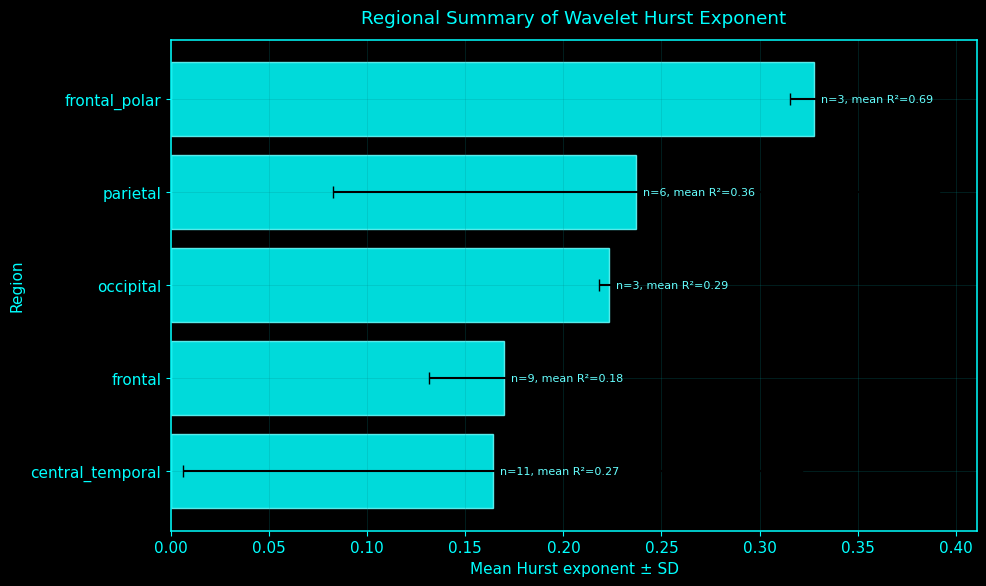

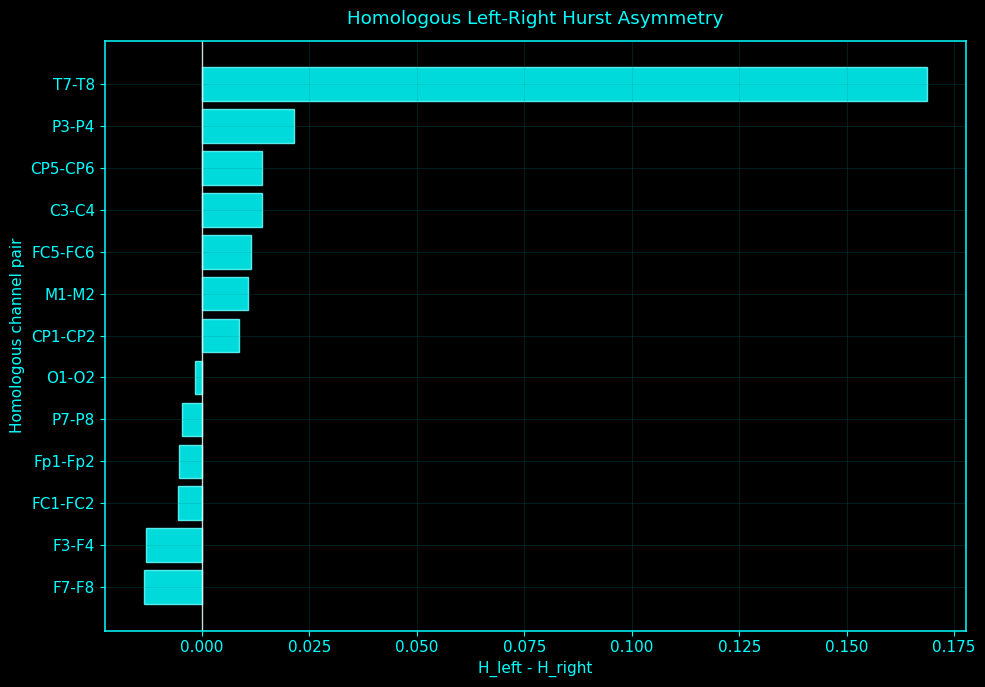

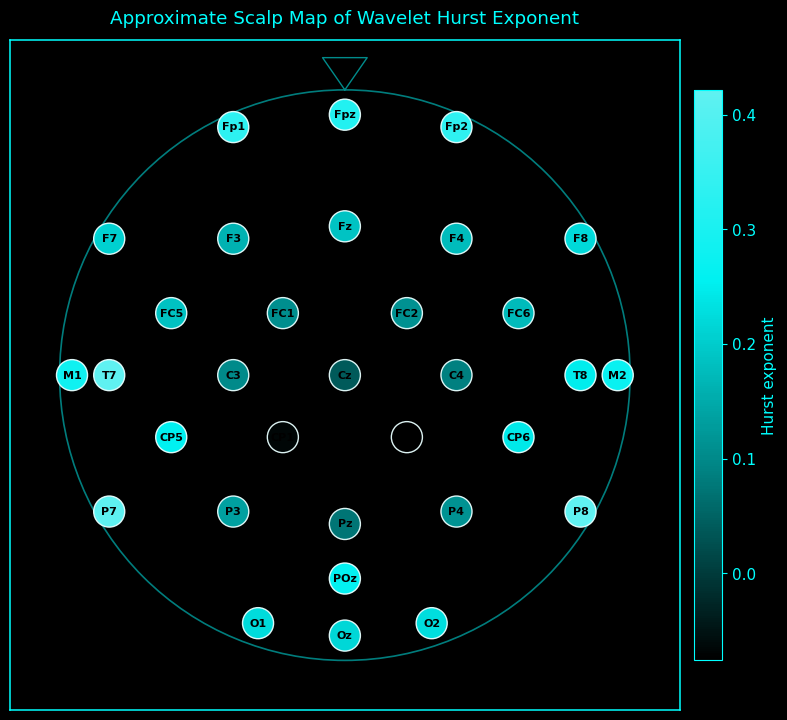

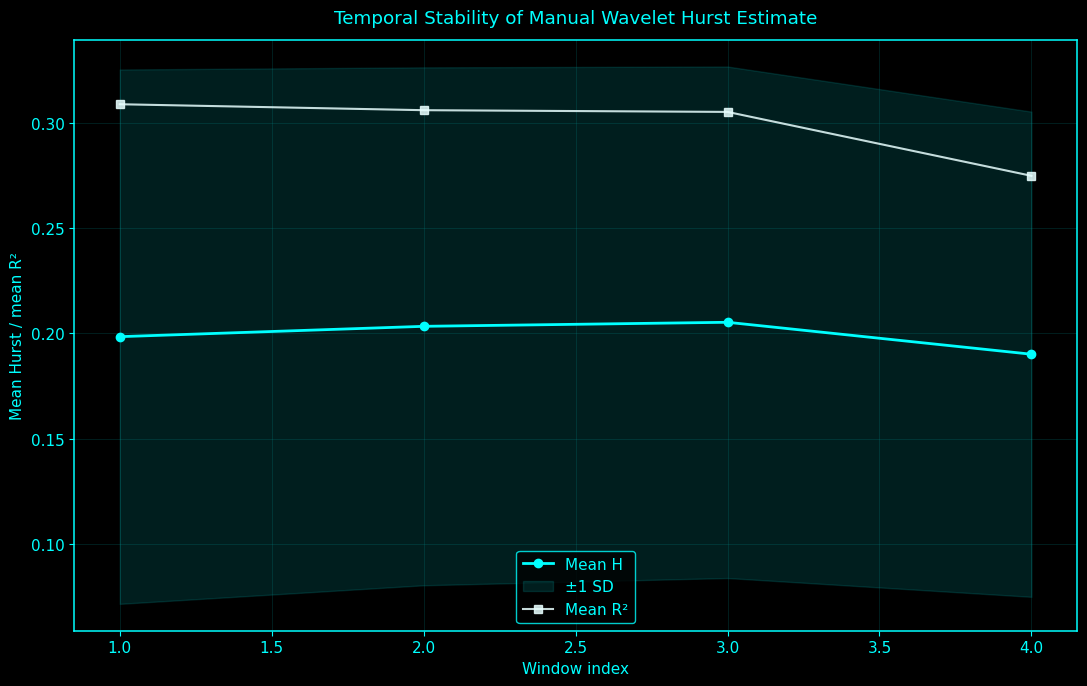

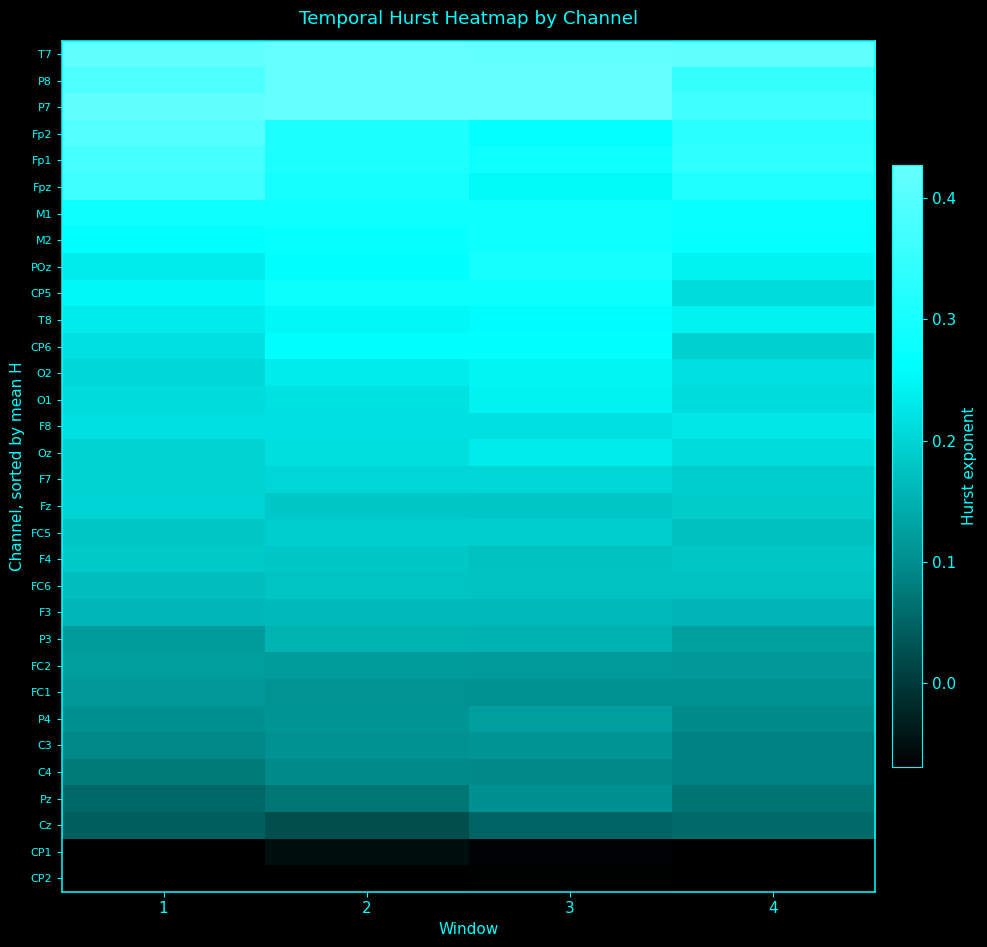


MANUAL WAVELET HURST ANALYSIS SUMMARY
FAST_OPTION: ultra
Wavelet: haar
Rows computed: 32
Channels analyzed: 32
Mean Hurst: 0.200190
Median Hurst: 0.211805
Mean fit R²: 0.303527
Total elapsed: 0.82 min

Top 10 channels by Hurst exponent:
channel  hurst_exponent  fractal_dimension_proxy   fit_r2  n_levels hemisphere           region
     P8        0.421421                 1.578579 0.799365         5      right         parietal
     T7        0.417742                 1.582258 0.785763         5       left central_temporal
     P7        0.416687                 1.583313 0.787534         5       left         parietal
    Fp2        0.337692                 1.662308 0.701391         5      right    frontal_polar
    Fp1        0.332388                 1.667612 0.707782         5       left    frontal_polar
    Fpz        0.313869                 1.686131 0.658950         5    midline    frontal_polar
     M1        0.282589                 1.717411 0.484634         5       left central_tem

In [1]:
import os
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

try:
    from IPython.display import display
    _HAVE_IPYTHON_DISPLAY = True
except Exception:
    display = None
    _HAVE_IPYTHON_DISPLAY = False


# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "results", "wavelet_hurst_exponent_manual_expert_fast")
plots_dir = os.path.join(out_dir, "plots")
scaling_dir = os.path.join(plots_dir, "per_channel_scaling_curves")

os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)
os.makedirs(scaling_dir, exist_ok=True)


FAST_OPTION = "ultra"   # options: "ultra", "fast", "balanced", "full"

if FAST_OPTION == "ultra":
    wavelet_name = "haar"              # fastest manual wavelet
    max_level = 5                      # fewer DWT levels = faster
    run_temporal_stability = True      # keep temporal plots
    temporal_windows = 4               # fewer windows
    max_channels = None                # all channels
    save_per_channel_scaling_curves = False
    scaling_gallery_top_n = 6
    raw_plot_max_points = 4000

elif FAST_OPTION == "fast":
    wavelet_name = "db4"
    max_level = 8
    run_temporal_stability = True
    temporal_windows = 8
    max_channels = None
    save_per_channel_scaling_curves = True
    scaling_gallery_top_n = 9
    raw_plot_max_points = 12000

elif FAST_OPTION == "balanced":
    wavelet_name = "db4"
    max_level = 10
    run_temporal_stability = True
    temporal_windows = 14
    max_channels = None
    save_per_channel_scaling_curves = True
    scaling_gallery_top_n = 12
    raw_plot_max_points = 24000

elif FAST_OPTION == "full":
    wavelet_name = "db4"
    max_level = None
    run_temporal_stability = True
    temporal_windows = 24
    max_channels = None
    save_per_channel_scaling_curves = True
    scaling_gallery_top_n = 16
    raw_plot_max_points = None

else:
    raise ValueError("FAST_OPTION must be one of: 'ultra', 'fast', 'balanced', 'full'.")


sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

SHOW_PLOTS_IN_NOTEBOOK = True
SAVE_PLOTS_TO_DISK = True

ACCENT = "#00FFFF"
ACCENT_SOFT = "#66FFFF"
ACCENT_DIM = "#008B8B"
WHITE = "#E8FFFF"
BLACK = "#000000"
eps = 1e-12

eeg_channel_names = [
    "Fp1", "Fpz", "Fp2", "F7", "F3", "Fz", "F4", "F8", "FC5", "FC1", "FC2", "FC6",
    "M1", "T7", "C3", "Cz", "C4", "T8", "M2", "CP5", "CP1", "CP2", "CP6",
    "P7", "P3", "Pz", "P4", "P8", "POz", "O1", "Oz", "O2"
]

if max_channels is not None:
    eeg_channel_names = eeg_channel_names[:max_channels]

left_channels = ["Fp1", "F7", "F3", "FC5", "FC1", "M1", "T7", "C3", "CP5", "CP1", "P7", "P3", "O1"]
right_channels = ["Fp2", "F8", "F4", "FC2", "FC6", "M2", "T8", "C4", "CP2", "CP6", "P8", "P4", "O2"]
midline_channels = ["Fpz", "Fz", "Cz", "Pz", "POz", "Oz"]

electrode_xy = {
    "Fp1": (-0.45, 1.00), "Fpz": (0.00, 1.05), "Fp2": (0.45, 1.00),
    "F7": (-0.95, 0.55), "F3": (-0.45, 0.55), "Fz": (0.00, 0.60), "F4": (0.45, 0.55), "F8": (0.95, 0.55),
    "FC5": (-0.70, 0.25), "FC1": (-0.25, 0.25), "FC2": (0.25, 0.25), "FC6": (0.70, 0.25),
    "M1": (-1.10, 0.00), "T7": (-0.95, 0.00), "C3": (-0.45, 0.00), "Cz": (0.00, 0.00), "C4": (0.45, 0.00), "T8": (0.95, 0.00), "M2": (1.10, 0.00),
    "CP5": (-0.70, -0.25), "CP1": (-0.25, -0.25), "CP2": (0.25, -0.25), "CP6": (0.70, -0.25),
    "P7": (-0.95, -0.55), "P3": (-0.45, -0.55), "Pz": (0.00, -0.60), "P4": (0.45, -0.55), "P8": (0.95, -0.55),
    "POz": (0.00, -0.82), "O1": (-0.35, -1.00), "Oz": (0.00, -1.05), "O2": (0.35, -1.00),
}

CYAN_DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "cyan_diverging",
    [ACCENT_DIM, BLACK, ACCENT_SOFT],
    N=256,
)

CYAN_SEQUENTIAL_CMAP = LinearSegmentedColormap.from_list(
    "cyan_sequential",
    [BLACK, ACCENT_DIM, ACCENT, ACCENT_SOFT],
    N=256,
)

plt.rcParams.update({
    "figure.facecolor": BLACK,
    "axes.facecolor": BLACK,
    "savefig.facecolor": BLACK,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT_DIM,
    "legend.facecolor": BLACK,
    "legend.edgecolor": ACCENT,
    "legend.labelcolor": ACCENT,
    "font.size": 11,
})

rng = np.random.default_rng(42)


# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax, title=None, xlabel=None, ylabel=None, grid=True):
    ax.set_facecolor(BLACK)

    for spine in ax.spines.values():
        spine.set_color(ACCENT)
        spine.set_linewidth(1.1)

    ax.tick_params(axis="x", colors=ACCENT, labelcolor=ACCENT)
    ax.tick_params(axis="y", colors=ACCENT, labelcolor=ACCENT)

    if title is not None:
        ax.set_title(title, color=ACCENT, pad=12)

    if xlabel is not None:
        ax.set_xlabel(xlabel, color=ACCENT)

    if ylabel is not None:
        ax.set_ylabel(ylabel, color=ACCENT)

    if grid:
        ax.grid(True, alpha=0.22, color=ACCENT_DIM, linewidth=0.7)
    else:
        ax.grid(False)


def save_fig(fig, path, show=True):
    fig.tight_layout()

    if SAVE_PLOTS_TO_DISK and path is not None:
        fig.savefig(path, dpi=220, bbox_inches="tight", facecolor=BLACK)

    if SHOW_PLOTS_IN_NOTEBOOK and show and _HAVE_IPYTHON_DISPLAY:
        display(fig)

    plt.close(fig)


def short_label(x, max_len=24):
    x = str(x)
    return x if len(x) <= max_len else x[:max_len - 1] + "…"


# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)

    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")

    if x.shape[1] == n_channels_expected:
        return x

    if x.shape[0] == n_channels_expected:
        return x.T

    if x.shape[1] >= n_channels_expected:
        return x[:, :n_channels_expected]

    if x.shape[0] >= n_channels_expected:
        return x.T[:, :n_channels_expected]

    raise ValueError(f"Unexpected EEG shape: {x.shape}")


def safe_zscore_1d(x):
    x = np.asarray(x, dtype=float).reshape(-1)
    x = np.where(np.isfinite(x), x, np.nan)

    if np.any(~np.isfinite(x)):
        med = np.nanmedian(x)
        if not np.isfinite(med):
            med = 0.0
        x = np.nan_to_num(x, nan=med, posinf=med, neginf=med)

    return (x - np.mean(x)) / (np.std(x) + eps)


def downsample_for_plot(X, max_points=None):
    X = np.asarray(X)

    if max_points is None or X.shape[0] <= max_points:
        return X, np.arange(X.shape[0])

    step = int(np.ceil(X.shape[0] / max_points))
    idx = np.arange(0, X.shape[0], step)

    return X[idx], idx


def get_wavelet_filters(name="db4"):
    name = name.lower()

    if name == "haar":
        h = np.array([
            1 / np.sqrt(2),
            1 / np.sqrt(2)
        ], dtype=float)

    elif name == "db4":
        h = np.array([
            -0.010597401785069032,
             0.0328830116668852,
             0.030841381835560764,
            -0.18703481171888114,
            -0.027983769416859854,
             0.6308807679298587,
             0.7148465705529157,
             0.2303778133088965
        ], dtype=float)

    else:
        raise ValueError("Unsupported wavelet. Use 'haar' or 'db4'.")

    g = ((-1) ** np.arange(len(h))) * h[::-1]

    return h, g


def dwt_single_level_periodic(x, h, g):
    x = np.asarray(x, dtype=float).reshape(-1)
    n = len(x)
    L = len(h)

    if n < L:
        raise ValueError("Signal too short for one DWT level with chosen filter.")

    out_len = n // 2

    if out_len < 1:
        raise ValueError("Signal too short after decimation.")

    a = np.zeros(out_len, dtype=float)
    d = np.zeros(out_len, dtype=float)

    for k in range(out_len):
        idx = (2 * k + np.arange(L)) % n
        segment = x[idx]
        a[k] = np.sum(h * segment)
        d[k] = np.sum(g * segment)

    return a, d


def max_dwt_level(n, filter_len):
    level = 0
    current_n = int(n)

    while current_n >= filter_len and current_n >= 2:
        current_n = current_n // 2
        level += 1

    return max(level, 0)


def wavedec_manual(x, wavelet="db4", level=None):
    h, g = get_wavelet_filters(wavelet)
    x = np.asarray(x, dtype=float).reshape(-1)

    if level is None:
        level = max_dwt_level(len(x), len(h))

    if level < 2:
        raise ValueError("Need at least 2 levels for stable wavelet Hurst estimation.")

    a = x.copy()
    details = []

    for _ in range(level):
        a, d = dwt_single_level_periodic(a, h, g)
        details.append(d)

        if len(a) < 2:
            break

    if len(details) < 2:
        raise ValueError("Too few valid detail levels after decomposition.")

    return a, details


def fit_line_r2(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)

    if np.sum(mask) < 2:
        return np.nan, np.nan, np.nan, None

    x = x[mask]
    y = y[mask]

    slope, intercept = np.polyfit(x, y, 1)
    y_hat = slope * x + intercept

    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1.0 - ss_res / (ss_tot + eps)

    return float(slope), float(intercept), float(r2), y_hat


def estimate_hurst_exponent_from_details(details):
    n_levels = len(details)
    scales = np.array([2 ** j for j in range(1, n_levels + 1)], dtype=float)
    stdevs = np.array([np.std(d, ddof=1) for d in details], dtype=float)
    energies = np.array([np.mean(np.asarray(d, dtype=float) ** 2) for d in details], dtype=float)

    valid = np.isfinite(stdevs) & (stdevs > 0)

    if np.sum(valid) < 2:
        return {
            "hurst_exponent": np.nan,
            "fit_r2": np.nan,
            "scales": scales,
            "detail_stdevs": stdevs,
            "detail_energies": energies,
            "log2_scales_fit": None,
            "log2_stdevs_fit": None,
            "fit_line": None,
            "slope": np.nan,
            "intercept": np.nan,
        }

    x = np.log2(scales[valid])
    y = np.log2(stdevs[valid])

    slope, intercept, r2, y_hat = fit_line_r2(x, y)

    return {
        "hurst_exponent": float(slope),
        "fit_r2": float(r2),
        "scales": scales,
        "detail_stdevs": stdevs,
        "detail_energies": energies,
        "log2_scales_fit": x,
        "log2_stdevs_fit": y,
        "fit_line": y_hat,
        "slope": slope,
        "intercept": intercept,
    }


def wavelet_fractal_analysis_manual(signal, wavelet="db4", max_level=None):
    signal = np.asarray(signal, dtype=float).reshape(-1)
    signal = safe_zscore_1d(signal)

    h, _ = get_wavelet_filters(wavelet)
    level_allowed = max_dwt_level(len(signal), len(h))

    if level_allowed < 2:
        raise ValueError(f"Signal too short for stable wavelet Hurst estimate with wavelet={wavelet}.")

    level = level_allowed if max_level is None else min(max_level, level_allowed)

    if level < 2:
        raise ValueError("Need at least 2 valid levels.")

    approx_final, details = wavedec_manual(signal, wavelet=wavelet, level=level)
    scaling = estimate_hurst_exponent_from_details(details)

    total_detail_energy = float(np.sum(scaling["detail_energies"]))
    relative_energies = scaling["detail_energies"] / (total_detail_energy + eps)

    return {
        "hurst_exponent": scaling["hurst_exponent"],
        "fit_r2": scaling["fit_r2"],
        "n_levels": int(len(details)),
        "scales": scaling["scales"],
        "detail_stdevs": scaling["detail_stdevs"],
        "detail_energies": scaling["detail_energies"],
        "relative_detail_energies": relative_energies,
        "log2_scales_fit": scaling["log2_scales_fit"],
        "log2_stdevs_fit": scaling["log2_stdevs_fit"],
        "fit_line": scaling["fit_line"],
        "slope": scaling["slope"],
        "intercept": scaling["intercept"],
        "approx_final": approx_final,
        "details": details,
        "level_allowed": level_allowed,
        "level_used": level,
    }


def compute_temporal_hurst(EEG_segment, channel_names, wavelet="db4", max_level=None, n_windows=8):
    n = EEG_segment.shape[0]
    window_len = max(2048, n // max(n_windows, 1))

    rows = []

    for w in range(n_windows):
        s = w * window_len
        e = min(n, s + window_len)

        if e - s < 2048:
            continue

        for i, channel in enumerate(channel_names):
            signal = EEG_segment[s:e, i]

            try:
                res = wavelet_fractal_analysis_manual(signal, wavelet=wavelet, max_level=max_level)
                rows.append({
                    "window": w + 1,
                    "channel": channel,
                    "start_sample": s,
                    "end_sample": e,
                    "start_sec_relative": s / sampling_rate,
                    "end_sec_relative": e / sampling_rate,
                    "hurst_exponent": res["hurst_exponent"],
                    "fit_r2": res["fit_r2"],
                    "n_levels": res["n_levels"],
                    "status": "ok",
                    "error": "",
                })
            except Exception as e2:
                rows.append({
                    "window": w + 1,
                    "channel": channel,
                    "start_sample": s,
                    "end_sample": e,
                    "start_sec_relative": s / sampling_rate,
                    "end_sec_relative": e / sampling_rate,
                    "hurst_exponent": np.nan,
                    "fit_r2": np.nan,
                    "n_levels": np.nan,
                    "status": "error",
                    "error": f"{type(e2).__name__}: {e2}",
                })

    return pd.DataFrame(rows)


def add_channel_metadata(results_df):
    df = results_df.copy()

    hemisphere = []
    region = []

    for ch in df["channel"]:
        if ch in left_channels:
            hemisphere.append("left")
        elif ch in right_channels:
            hemisphere.append("right")
        elif ch in midline_channels:
            hemisphere.append("midline")
        else:
            hemisphere.append("unknown")

        if ch.startswith("Fp"):
            region.append("frontal_polar")
        elif ch.startswith("F") or ch.startswith("FC"):
            region.append("frontal")
        elif ch.startswith("C") or ch.startswith("T") or ch.startswith("M"):
            region.append("central_temporal")
        elif ch.startswith("CP") or ch.startswith("P"):
            region.append("parietal")
        elif ch.startswith("PO") or ch.startswith("O"):
            region.append("occipital")
        else:
            region.append("unknown")

    df["hemisphere"] = hemisphere
    df["region"] = region
    df["fractal_dimension_proxy"] = 2.0 - df["hurst_exponent"]
    df["quality_weighted_hurst"] = df["hurst_exponent"] * df["fit_r2"]

    return df


# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------
def plot_raw_eeg_offset(EEG_segment, channel_names):
    Xp, idx = downsample_for_plot(EEG_segment, raw_plot_max_points)
    t = idx / sampling_rate
    Xz = np.column_stack([safe_zscore_1d(Xp[:, i]) for i in range(Xp.shape[1])])
    offset = 5.0

    fig_height = min(10.5, max(6.0, 0.28 * len(channel_names)))
    fig, ax = plt.subplots(figsize=(13, fig_height))

    for i, ch in enumerate(channel_names):
        ax.plot(
            t,
            Xz[:, i] + i * offset,
            color=ACCENT,
            linewidth=0.55,
            alpha=0.65,
        )

    ax.set_yticks(np.arange(len(channel_names)) * offset)
    ax.set_yticklabels(channel_names, color=ACCENT, fontsize=8)

    style_ax(
        ax,
        title="EEG Segment Used for Manual Wavelet Hurst Analysis",
        xlabel="Time from segment start (s)",
        ylabel="Channel",
    )

    path = os.path.join(plots_dir, "00_raw_eeg_segment_offset_black_cyan.png")
    save_fig(fig, path)
    return path


def plot_hurst_bar(results_df):
    plot_df = results_df.copy().sort_values("hurst_exponent", ascending=True, na_position="first")

    fig, ax = plt.subplots(figsize=(10, 10))

    ax.barh(
        plot_df["channel"].values,
        plot_df["hurst_exponent"].fillna(0.0).values,
        color=ACCENT,
        edgecolor=ACCENT_SOFT,
        alpha=0.86,
    )

    mean_h = plot_df["hurst_exponent"].mean()
    med_h = plot_df["hurst_exponent"].median()

    ax.axvline(mean_h, color=WHITE, linestyle="--", linewidth=1.1, alpha=0.90, label=f"Mean H={mean_h:.3f}")
    ax.axvline(med_h, color=ACCENT_SOFT, linestyle=":", linewidth=1.1, alpha=0.90, label=f"Median H={med_h:.3f}")

    style_ax(
        ax,
        title=f"Manual Wavelet-Based Hurst Exponent per EEG Channel ({wavelet_name}, {FAST_OPTION})",
        xlabel="Hurst exponent",
        ylabel="Channel",
    )

    leg = ax.legend(loc="best", frameon=True)
    for text in leg.get_texts():
        text.set_color(ACCENT)

    path = os.path.join(plots_dir, "01_manual_wavelet_hurst_barh_black_cyan.png")
    save_fig(fig, path)
    return path


def plot_fit_r2_bar(results_df):
    plot_df = results_df.copy().sort_values("fit_r2", ascending=True, na_position="first")

    fig, ax = plt.subplots(figsize=(10, 10))

    ax.barh(
        plot_df["channel"].values,
        plot_df["fit_r2"].fillna(0.0).values,
        color=ACCENT,
        edgecolor=ACCENT_SOFT,
        alpha=0.86,
    )

    ax.axvline(0.95, color=WHITE, linestyle="--", linewidth=1.1, alpha=0.90, label="R²=0.95")
    ax.axvline(0.90, color=ACCENT_SOFT, linestyle=":", linewidth=1.1, alpha=0.90, label="R²=0.90")

    style_ax(
        ax,
        title="Manual Wavelet Hurst Fit Quality per EEG Channel",
        xlabel="Linear scaling fit R²",
        ylabel="Channel",
    )

    leg = ax.legend(loc="best", frameon=True)
    for text in leg.get_texts():
        text.set_color(ACCENT)

    path = os.path.join(plots_dir, "02_manual_wavelet_hurst_fit_r2_barh_black_cyan.png")
    save_fig(fig, path)
    return path


def plot_scaling_curves_all(channel_results):
    fig, ax = plt.subplots(figsize=(9.5, 6.5))

    for channel, res in channel_results.items():
        x = res.get("log2_scales_fit", None)
        y = res.get("log2_stdevs_fit", None)

        if x is None or y is None:
            continue

        ax.plot(
            x,
            y,
            marker="o",
            linewidth=1.0,
            markersize=3,
            alpha=0.35,
            color=ACCENT,
        )

    style_ax(
        ax,
        title=f"Manual Wavelet Scaling Curves Across Channels ({wavelet_name})",
        xlabel="log2(scale)",
        ylabel="log2(std(detail coefficients))",
    )

    path = os.path.join(plots_dir, "03_manual_wavelet_scaling_curves_all_channels_black_cyan.png")
    save_fig(fig, path)
    return path


def plot_individual_scaling_curves(channel_results):
    saved = []

    if not save_per_channel_scaling_curves:
        return saved

    for channel, res in channel_results.items():
        x = res.get("log2_scales_fit", None)
        y = res.get("log2_stdevs_fit", None)
        yhat = res.get("fit_line", None)

        if x is None or y is None or yhat is None or len(x) < 2:
            continue

        fig, ax = plt.subplots(figsize=(6.5, 4.5))

        ax.plot(
            x,
            y,
            marker="o",
            color=ACCENT,
            linewidth=1.2,
            label="Observed",
        )

        ax.plot(
            x,
            yhat,
            linestyle="--",
            color=WHITE,
            linewidth=1.4,
            label="Linear fit",
        )

        style_ax(
            ax,
            title=f"{channel}: Manual Wavelet Scaling | H={res['hurst_exponent']:.3f}, R²={res['fit_r2']:.3f}",
            xlabel="log2(scale)",
            ylabel="log2(std(detail coeffs))",
        )

        leg = ax.legend(loc="best", frameon=True)
        for text in leg.get_texts():
            text.set_color(ACCENT)

        out_path = os.path.join(scaling_dir, f"{channel}_manual_wavelet_scaling_black_cyan.png")
        save_fig(fig, out_path, show=False)
        saved.append(out_path)

    return saved


def plot_scaling_curve_gallery(results_df, channel_results):
    df = results_df.copy()
    df = df[np.isfinite(df["hurst_exponent"]) & np.isfinite(df["fit_r2"])]
    df = df.sort_values(["fit_r2", "hurst_exponent"], ascending=False).head(scaling_gallery_top_n)

    if df.empty:
        return None

    n = len(df)
    ncols = 3
    nrows = int(math.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.9 * nrows), squeeze=False)
    fig.patch.set_facecolor(BLACK)

    for ax in axes.ravel():
        ax.set_facecolor(BLACK)
        ax.axis("off")

    for ax, (_, row) in zip(axes.ravel(), df.iterrows()):
        ax.axis("on")
        ch = row["channel"]
        res = channel_results.get(ch, None)

        if res is None:
            ax.text(0.5, 0.5, "Missing result", transform=ax.transAxes, color=ACCENT, ha="center", va="center")
            style_ax(ax, title=ch)
            continue

        x = res.get("log2_scales_fit", None)
        y = res.get("log2_stdevs_fit", None)
        yhat = res.get("fit_line", None)

        if x is not None and y is not None:
            ax.plot(x, y, marker="o", color=ACCENT, linewidth=1.1, markersize=3, label="Observed")

        if x is not None and yhat is not None:
            ax.plot(x, yhat, color=WHITE, linestyle="--", linewidth=1.3, label="Fit")

        style_ax(
            ax,
            title=f"{ch} | H={row['hurst_exponent']:.3f}, R²={row['fit_r2']:.3f}",
            xlabel="log2(scale)",
            ylabel="log2(std)",
        )

    path = os.path.join(plots_dir, "04_scaling_curve_gallery_top_channels_black_cyan.png")
    save_fig(fig, path)
    return path


def plot_hurst_vs_fit_quality(results_df):
    df = results_df.copy()
    df = df[np.isfinite(df["hurst_exponent"]) & np.isfinite(df["fit_r2"])]

    if df.empty:
        return None

    fig, ax = plt.subplots(figsize=(9, 7))

    sizes = 70 + 45 * df["n_levels"].to_numpy(dtype=float)

    ax.scatter(
        df["hurst_exponent"],
        df["fit_r2"],
        s=sizes,
        c=ACCENT,
        edgecolors=WHITE,
        linewidths=0.8,
        alpha=0.82,
    )

    ax.axhline(0.95, color=WHITE, linestyle="--", linewidth=1.0, alpha=0.75)
    ax.axvline(df["hurst_exponent"].mean(), color=ACCENT_SOFT, linestyle=":", linewidth=1.0, alpha=0.85)

    for _, row in df.sort_values("hurst_exponent", ascending=False).head(6).iterrows():
        ax.annotate(
            row["channel"],
            (row["hurst_exponent"], row["fit_r2"]),
            xytext=(5, 5),
            textcoords="offset points",
            color=ACCENT_SOFT,
            fontsize=8,
        )

    style_ax(
        ax,
        title="Hurst Exponent vs Scaling Fit Reliability",
        xlabel="Hurst exponent",
        ylabel="Scaling fit R²",
    )

    path = os.path.join(plots_dir, "05_hurst_vs_fit_quality_black_cyan.png")
    save_fig(fig, path)
    return path


def plot_detail_stdev_heatmap(channel_results):
    channels = list(channel_results.keys())

    if len(channels) == 0:
        return None

    max_levels_found = max(len(channel_results[ch]["detail_stdevs"]) for ch in channels)

    M = np.full((len(channels), max_levels_found), np.nan, dtype=float)

    for i, ch in enumerate(channels):
        vals = np.asarray(channel_results[ch]["detail_stdevs"], dtype=float)
        M[i, :len(vals)] = np.log2(vals + eps)

    order_metric = np.array([channel_results[ch]["hurst_exponent"] for ch in channels])
    order = np.argsort(order_metric)[::-1]
    M = M[order]
    ordered_channels = [channels[i] for i in order]

    fig_height = min(10.5, max(7.0, 0.30 * len(ordered_channels)))
    fig, ax = plt.subplots(figsize=(10.5, fig_height))

    finite = M[np.isfinite(M)]
    vmin = np.nanpercentile(finite, 3) if finite.size else 0
    vmax = np.nanpercentile(finite, 97) if finite.size else 1

    im = ax.imshow(
        M,
        aspect="auto",
        interpolation="nearest",
        cmap=CYAN_SEQUENTIAL_CMAP,
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_xticks(np.arange(max_levels_found))
    ax.set_xticklabels([f"L{j + 1}" for j in range(max_levels_found)], color=ACCENT)

    ax.set_yticks(np.arange(len(ordered_channels)))
    ax.set_yticklabels(ordered_channels, color=ACCENT, fontsize=8)

    style_ax(
        ax,
        title="Wavelet Detail Coefficient Scale Map: log2(std(detail))",
        xlabel="Wavelet detail level, fine to coarse",
        ylabel="Channel, sorted by Hurst",
        grid=False,
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.set_label("log2 detail coefficient standard deviation", color=ACCENT)

    path = os.path.join(plots_dir, "06_wavelet_detail_stdev_heatmap_black_cyan.png")
    save_fig(fig, path)
    return path


def plot_relative_energy_heatmap(channel_results):
    channels = list(channel_results.keys())

    if len(channels) == 0:
        return None

    max_levels_found = max(len(channel_results[ch]["relative_detail_energies"]) for ch in channels)
    M = np.full((len(channels), max_levels_found), np.nan, dtype=float)

    for i, ch in enumerate(channels):
        vals = np.asarray(channel_results[ch]["relative_detail_energies"], dtype=float)
        M[i, :len(vals)] = vals

    order_metric = np.array([channel_results[ch]["hurst_exponent"] for ch in channels])
    order = np.argsort(order_metric)[::-1]
    M = M[order]
    ordered_channels = [channels[i] for i in order]

    fig_height = min(10.5, max(7.0, 0.30 * len(ordered_channels)))
    fig, ax = plt.subplots(figsize=(10.5, fig_height))

    im = ax.imshow(
        M,
        aspect="auto",
        interpolation="nearest",
        cmap=CYAN_SEQUENTIAL_CMAP,
        vmin=0,
        vmax=np.nanpercentile(M, 98),
    )

    ax.set_xticks(np.arange(max_levels_found))
    ax.set_xticklabels([f"L{j + 1}" for j in range(max_levels_found)], color=ACCENT)

    ax.set_yticks(np.arange(len(ordered_channels)))
    ax.set_yticklabels(ordered_channels, color=ACCENT, fontsize=8)

    style_ax(
        ax,
        title="Relative Wavelet Detail Energy by Channel",
        xlabel="Wavelet detail level, fine to coarse",
        ylabel="Channel, sorted by Hurst",
        grid=False,
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.set_label("Relative detail energy", color=ACCENT)

    path = os.path.join(plots_dir, "07_relative_wavelet_energy_heatmap_black_cyan.png")
    save_fig(fig, path)
    return path


def plot_fractal_dimension_proxy(results_df):
    df = results_df.copy()
    df = df[np.isfinite(df["fractal_dimension_proxy"])].sort_values("fractal_dimension_proxy", ascending=True)

    if df.empty:
        return None

    fig, ax = plt.subplots(figsize=(10, 10))

    y = np.arange(len(df))

    ax.barh(
        y,
        df["fractal_dimension_proxy"],
        color=ACCENT,
        edgecolor=ACCENT_SOFT,
        alpha=0.86,
    )

    ax.set_yticks(y)
    ax.set_yticklabels(df["channel"], color=ACCENT, fontsize=8)

    style_ax(
        ax,
        title="Fractal-Dimension Proxy from Wavelet Hurst: D ≈ 2 - H",
        xlabel="Fractal-dimension proxy",
        ylabel="Channel",
    )

    path = os.path.join(plots_dir, "08_fractal_dimension_proxy_barh_black_cyan.png")
    save_fig(fig, path)
    return path


def plot_region_summary(results_df):
    df = results_df.copy()
    df = df[np.isfinite(df["hurst_exponent"])]

    if df.empty:
        return None

    grouped = (
        df.groupby("region")
        .agg(
            mean_hurst=("hurst_exponent", "mean"),
            std_hurst=("hurst_exponent", "std"),
            mean_r2=("fit_r2", "mean"),
            n=("channel", "count"),
        )
        .reset_index()
        .sort_values("mean_hurst", ascending=True)
    )

    fig, ax = plt.subplots(figsize=(10, 6))

    y = np.arange(len(grouped))

    ax.barh(
        y,
        grouped["mean_hurst"],
        xerr=grouped["std_hurst"].fillna(0.0),
        color=ACCENT,
        edgecolor=ACCENT_SOFT,
        alpha=0.86,
        capsize=4,
    )

    ax.set_yticks(y)
    ax.set_yticklabels(grouped["region"], color=ACCENT)

    for yi, (_, row) in zip(y, grouped.iterrows()):
        ax.text(
            row["mean_hurst"],
            yi,
            f"  n={int(row['n'])}, mean R²={row['mean_r2']:.2f}",
            va="center",
            ha="left",
            color=ACCENT_SOFT,
            fontsize=8,
        )

    style_ax(
        ax,
        title="Regional Summary of Wavelet Hurst Exponent",
        xlabel="Mean Hurst exponent ± SD",
        ylabel="Region",
    )

    path = os.path.join(plots_dir, "09_regional_hurst_summary_black_cyan.png")
    save_fig(fig, path)
    return path


def plot_hemisphere_asymmetry(results_df):
    df = results_df.copy()
    df = df[np.isfinite(df["hurst_exponent"])]

    left = df[df["hemisphere"] == "left"][["channel", "hurst_exponent"]].copy()
    right = df[df["hemisphere"] == "right"][["channel", "hurst_exponent"]].copy()

    if left.empty or right.empty:
        return None

    homolog_pairs = [
        ("Fp1", "Fp2"),
        ("F7", "F8"),
        ("F3", "F4"),
        ("FC5", "FC6"),
        ("FC1", "FC2"),
        ("M1", "M2"),
        ("T7", "T8"),
        ("C3", "C4"),
        ("CP5", "CP6"),
        ("CP1", "CP2"),
        ("P7", "P8"),
        ("P3", "P4"),
        ("O1", "O2"),
    ]

    rows = []

    hdict = dict(zip(df["channel"], df["hurst_exponent"]))

    for l, r in homolog_pairs:
        if l in hdict and r in hdict and np.isfinite(hdict[l]) and np.isfinite(hdict[r]):
            rows.append({
                "pair": f"{l}-{r}",
                "left": l,
                "right": r,
                "H_left": hdict[l],
                "H_right": hdict[r],
                "H_left_minus_right": hdict[l] - hdict[r],
            })

    asym_df = pd.DataFrame(rows)

    if asym_df.empty:
        return None

    asym_csv = os.path.join(out_dir, f"manual_wavelet_hurst_hemisphere_asymmetry_{FAST_OPTION}.csv")
    asym_df.to_csv(asym_csv, index=False)

    plot_df = asym_df.sort_values("H_left_minus_right", ascending=True)

    fig, ax = plt.subplots(figsize=(10, 7))

    y = np.arange(len(plot_df))

    ax.barh(
        y,
        plot_df["H_left_minus_right"],
        color=ACCENT,
        edgecolor=ACCENT_SOFT,
        alpha=0.86,
    )

    ax.axvline(0, color=WHITE, linewidth=1.0, alpha=0.85)

    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["pair"], color=ACCENT)

    style_ax(
        ax,
        title="Homologous Left-Right Hurst Asymmetry",
        xlabel="H_left - H_right",
        ylabel="Homologous channel pair",
    )

    path = os.path.join(plots_dir, "10_hemisphere_hurst_asymmetry_black_cyan.png")
    save_fig(fig, path)
    return path


def plot_topographic_hurst(results_df):
    df = results_df.copy()
    df = df[np.isfinite(df["hurst_exponent"])]

    if df.empty:
        return None

    xs = []
    ys = []
    vals = []
    labels = []

    for _, row in df.iterrows():
        ch = row["channel"]

        if ch in electrode_xy:
            x, y = electrode_xy[ch]
            xs.append(x)
            ys.append(y)
            vals.append(row["hurst_exponent"])
            labels.append(ch)

    if len(vals) == 0:
        return None

    xs = np.asarray(xs)
    ys = np.asarray(ys)
    vals = np.asarray(vals)

    fig, ax = plt.subplots(figsize=(8, 8))

    head = plt.Circle((0, 0), 1.15, color=ACCENT_DIM, fill=False, linewidth=1.2, alpha=0.9)
    ax.add_patch(head)

    nose_x = [0.0, -0.09, 0.09, 0.0]
    nose_y = [1.15, 1.28, 1.28, 1.15]
    ax.plot(nose_x, nose_y, color=ACCENT_DIM, linewidth=1.0)

    sc = ax.scatter(
        xs,
        ys,
        c=vals,
        s=500,
        cmap=CYAN_SEQUENTIAL_CMAP,
        edgecolors=WHITE,
        linewidths=1.0,
        alpha=0.95,
    )

    for x, y, ch in zip(xs, ys, labels):
        ax.text(
            x,
            y,
            ch,
            ha="center",
            va="center",
            color=BLACK,
            fontsize=8,
            fontweight="bold",
        )

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-1.35, 1.35)
    ax.set_ylim(-1.35, 1.35)
    ax.set_xticks([])
    ax.set_yticks([])

    style_ax(
        ax,
        title="Approximate Scalp Map of Wavelet Hurst Exponent",
        xlabel="",
        ylabel="",
        grid=False,
    )

    cbar = fig.colorbar(sc, ax=ax, fraction=0.040, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.set_label("Hurst exponent", color=ACCENT)

    path = os.path.join(plots_dir, "11_topographic_hurst_map_black_cyan.png")
    save_fig(fig, path)
    return path


def plot_temporal_stability(temporal_df):
    if temporal_df.empty:
        return None

    grouped = (
        temporal_df.groupby("window")
        .agg(
            mean_hurst=("hurst_exponent", "mean"),
            std_hurst=("hurst_exponent", "std"),
            mean_r2=("fit_r2", "mean"),
            n=("channel", "count"),
        )
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(11, 7))

    ax.plot(
        grouped["window"],
        grouped["mean_hurst"],
        marker="o",
        color=ACCENT,
        linewidth=2.0,
        label="Mean H",
    )

    ax.fill_between(
        grouped["window"],
        grouped["mean_hurst"] - grouped["std_hurst"],
        grouped["mean_hurst"] + grouped["std_hurst"],
        color=ACCENT,
        alpha=0.12,
        label="±1 SD",
    )

    ax.plot(
        grouped["window"],
        grouped["mean_r2"],
        marker="s",
        color=WHITE,
        linewidth=1.5,
        alpha=0.85,
        label="Mean R²",
    )

    style_ax(
        ax,
        title="Temporal Stability of Manual Wavelet Hurst Estimate",
        xlabel="Window index",
        ylabel="Mean Hurst / mean R²",
    )

    leg = ax.legend(loc="best", frameon=True)
    for text in leg.get_texts():
        text.set_color(ACCENT)

    path = os.path.join(plots_dir, "12_temporal_hurst_stability_black_cyan.png")
    save_fig(fig, path)
    return path


def plot_temporal_channel_heatmap(temporal_df):
    if temporal_df.empty:
        return None

    pivot = temporal_df.pivot_table(
        index="channel",
        columns="window",
        values="hurst_exponent",
        aggfunc="mean",
    )

    if pivot.empty:
        return None

    order = pivot.mean(axis=1).sort_values(ascending=False).index
    pivot = pivot.loc[order]

    M = pivot.to_numpy(dtype=float)

    fig_height = min(10.5, max(7.0, 0.30 * len(pivot.index)))
    fig, ax = plt.subplots(figsize=(10, fig_height))

    finite = M[np.isfinite(M)]
    vmin = np.nanpercentile(finite, 3) if finite.size else 0
    vmax = np.nanpercentile(finite, 97) if finite.size else 1

    im = ax.imshow(
        M,
        aspect="auto",
        interpolation="nearest",
        cmap=CYAN_SEQUENTIAL_CMAP,
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, color=ACCENT)

    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index, color=ACCENT, fontsize=8)

    style_ax(
        ax,
        title="Temporal Hurst Heatmap by Channel",
        xlabel="Window",
        ylabel="Channel, sorted by mean H",
        grid=False,
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.set_label("Hurst exponent", color=ACCENT)

    path = os.path.join(plots_dir, "13_temporal_channel_hurst_heatmap_black_cyan.png")
    save_fig(fig, path)
    return path


# -------------------------------------------------------
# LOAD EEG
# -------------------------------------------------------
start_all = time.perf_counter()

print("Running manual wavelet Hurst analysis with fast options", flush=True)
print(f"FAST_OPTION: {FAST_OPTION}", flush=True)
print(f"Wavelet: {wavelet_name}", flush=True)
print(f"Requested max_level: {max_level}", flush=True)
print(f"Temporal stability enabled: {run_temporal_stability}", flush=True)

EEG_data = np.load(eeg_path, allow_pickle=True)
EEG_data = ensure_time_channel_layout(EEG_data, len(eeg_channel_names))
EEG_segment = EEG_data[start_index:end_index, :len(eeg_channel_names)]

print(f"Loaded EEG shape: {EEG_data.shape}", flush=True)
print(f"Using segment: [{start_time}, {end_time}] sec", flush=True)
print(f"Segment shape: {EEG_segment.shape}", flush=True)


# -------------------------------------------------------
# RUN MANUAL WAVELET HURST ANALYSIS
# -------------------------------------------------------
records = []
channel_results = {}

for i, channel in enumerate(eeg_channel_names):
    signal = EEG_segment[:, i]

    try:
        t0 = time.perf_counter()

        res = wavelet_fractal_analysis_manual(
            signal,
            wavelet=wavelet_name,
            max_level=max_level,
        )

        elapsed = time.perf_counter() - t0

        channel_results[channel] = res

        rec = {
            "channel": channel,
            "hurst_exponent": res["hurst_exponent"],
            "fractal_dimension_proxy": 2.0 - res["hurst_exponent"],
            "fit_r2": res["fit_r2"],
            "n_levels": res["n_levels"],
            "level_allowed": res["level_allowed"],
            "level_used": res["level_used"],
            "signal_length": len(signal),
            "wavelet": wavelet_name,
            "FAST_OPTION": FAST_OPTION,
            "elapsed_sec": elapsed,
            "status": "ok",
            "error": "",
        }

        print(
            f"{channel}: H={res['hurst_exponent']:.6f} | "
            f"D≈{2.0 - res['hurst_exponent']:.6f} | "
            f"R²={res['fit_r2']:.6f} | levels={res['n_levels']} | {elapsed:.3f}s",
            flush=True,
        )

    except Exception as e:
        rec = {
            "channel": channel,
            "hurst_exponent": np.nan,
            "fractal_dimension_proxy": np.nan,
            "fit_r2": np.nan,
            "n_levels": np.nan,
            "level_allowed": np.nan,
            "level_used": np.nan,
            "signal_length": len(signal),
            "wavelet": wavelet_name,
            "FAST_OPTION": FAST_OPTION,
            "elapsed_sec": np.nan,
            "status": "error",
            "error": f"{type(e).__name__}: {e}",
        }

        print(f"{channel}: ERROR -> {rec['error']}", flush=True)

    records.append(rec)

results_df = pd.DataFrame(records)
results_df = add_channel_metadata(results_df)


# -------------------------------------------------------
# OPTIONAL TEMPORAL STABILITY
# -------------------------------------------------------
if run_temporal_stability:
    print("\nComputing temporal Hurst stability windows...", flush=True)
    temporal_df = compute_temporal_hurst(
        EEG_segment,
        eeg_channel_names,
        wavelet=wavelet_name,
        max_level=max_level,
        n_windows=temporal_windows,
    )
else:
    temporal_df = pd.DataFrame()


# -------------------------------------------------------
# SAVE RESULTS
# -------------------------------------------------------
results_csv = os.path.join(out_dir, f"manual_wavelet_hurst_per_channel_{FAST_OPTION}.csv")
results_df.to_csv(results_csv, index=False)

temporal_csv = os.path.join(out_dir, f"manual_wavelet_hurst_temporal_windows_{FAST_OPTION}.csv")
if not temporal_df.empty:
    temporal_df.to_csv(temporal_csv, index=False)

summary_txt = os.path.join(out_dir, f"manual_wavelet_hurst_summary_{FAST_OPTION}.txt")

with open(summary_txt, "w") as f:
    f.write("Manual Wavelet-Based Hurst Exponent Analysis\n")
    f.write("===========================================\n\n")
    f.write(f"EEG path: {eeg_path}\n")
    f.write(f"Segment: [{start_time}, {end_time}] sec\n")
    f.write(f"Sampling rate: {sampling_rate} Hz\n")
    f.write(f"Wavelet: {wavelet_name}\n")
    f.write(f"FAST_OPTION: {FAST_OPTION}\n")
    f.write(f"Max level request: {max_level}\n")
    f.write(f"Channels analyzed: {len(results_df)}\n")
    f.write(f"Temporal stability enabled: {run_temporal_stability}\n")
    f.write(f"Temporal windows: {temporal_windows}\n\n")

    f.write("Per-channel results:\n")
    for _, row in results_df.iterrows():
        if pd.notna(row["hurst_exponent"]):
            f.write(
                f"{row['channel']}: "
                f"H={row['hurst_exponent']:.6f}, "
                f"D_proxy={row['fractal_dimension_proxy']:.6f}, "
                f"R²={row['fit_r2']:.6f}, "
                f"levels={int(row['n_levels'])}, "
                f"hemisphere={row['hemisphere']}, "
                f"region={row['region']}\n"
            )
        else:
            f.write(f"{row['channel']}: ERROR -> {row.get('error', 'unknown')}\n")

    f.write("\nRegional means:\n")
    regional = (
        results_df.groupby("region")
        .agg(
            mean_hurst=("hurst_exponent", "mean"),
            std_hurst=("hurst_exponent", "std"),
            mean_r2=("fit_r2", "mean"),
            n=("channel", "count"),
        )
        .reset_index()
    )

    for _, row in regional.iterrows():
        f.write(
            f"{row['region']}: mean_H={row['mean_hurst']:.6f}, "
            f"std_H={row['std_hurst']:.6f}, mean_R2={row['mean_r2']:.6f}, n={int(row['n'])}\n"
        )


# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------
print("\nGenerating plots...", flush=True)

plot_paths = []

plot_paths.append(plot_raw_eeg_offset(EEG_segment, eeg_channel_names))
plot_paths.append(plot_hurst_bar(results_df))
plot_paths.append(plot_fit_r2_bar(results_df))
plot_paths.append(plot_scaling_curves_all(channel_results))
plot_paths.append(plot_scaling_curve_gallery(results_df, channel_results))
plot_paths.append(plot_hurst_vs_fit_quality(results_df))
plot_paths.append(plot_detail_stdev_heatmap(channel_results))
plot_paths.append(plot_relative_energy_heatmap(channel_results))
plot_paths.append(plot_fractal_dimension_proxy(results_df))
plot_paths.append(plot_region_summary(results_df))
plot_paths.append(plot_hemisphere_asymmetry(results_df))
plot_paths.append(plot_topographic_hurst(results_df))

if not temporal_df.empty:
    plot_paths.append(plot_temporal_stability(temporal_df))
    plot_paths.append(plot_temporal_channel_heatmap(temporal_df))

per_channel_paths = plot_individual_scaling_curves(channel_results)
plot_paths.extend(per_channel_paths)

plot_paths = [p for p in plot_paths if p is not None]


# -------------------------------------------------------
# FINAL SUMMARY
# -------------------------------------------------------
elapsed_all = time.perf_counter() - start_all

print("\n" + "=" * 88)
print("MANUAL WAVELET HURST ANALYSIS SUMMARY")
print("=" * 88)
print(f"FAST_OPTION: {FAST_OPTION}")
print(f"Wavelet: {wavelet_name}")
print(f"Rows computed: {len(results_df)}")
print(f"Channels analyzed: {results_df['channel'].nunique()}")
print(f"Mean Hurst: {results_df['hurst_exponent'].mean():.6f}")
print(f"Median Hurst: {results_df['hurst_exponent'].median():.6f}")
print(f"Mean fit R²: {results_df['fit_r2'].mean():.6f}")
print(f"Total elapsed: {elapsed_all / 60:.2f} min")

print("\nTop 10 channels by Hurst exponent:")
cols = ["channel", "hurst_exponent", "fractal_dimension_proxy", "fit_r2", "n_levels", "hemisphere", "region"]
print(results_df.sort_values("hurst_exponent", ascending=False)[cols].head(10).to_string(index=False))

print("\nLowest 10 channels by Hurst exponent:")
print(results_df.sort_values("hurst_exponent", ascending=True)[cols].head(10).to_string(index=False))

print("\nRegional summary:")
regional_summary = (
    results_df.groupby("region")
    .agg(
        mean_hurst=("hurst_exponent", "mean"),
        std_hurst=("hurst_exponent", "std"),
        mean_r2=("fit_r2", "mean"),
        n=("channel", "count"),
    )
    .reset_index()
)
print(regional_summary.to_string(index=False))

print("\nSaved outputs:")
print(f"Results CSV: {results_csv}")
if not temporal_df.empty:
    print(f"Temporal CSV: {temporal_csv}")
print(f"Summary TXT: {summary_txt}")

print("\nSaved plots:")
for p in plot_paths:
    print(p)

print("\nDone.")

# Multifractal Analysis

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; flex-wrap: nowrap; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="flex: 1; margin-right: 10px;">
        <h2>Introduction</h2>
        <p>The examination of multifractal properties of EEG data is essential for understanding the underlying complex dynamics. A popular technique for such analysis is Multifractal Detrended Fluctuation Analysis (MFDFA), which is employed here to delineate the multifractal spectrum of EEG data across various channels. The MFDFA technique facilitates the discernment of self-affine properties of signals across multiple scales.</p>
        <h2>Mathematical Foundations</h2>
        <p>MFDFA is grounded on the calculation of fluctuation functions \( F_q(s) \) for different segments of the time series, followed by a scaling analysis. The fluctuation function is given by:</p>
        \[ F_q(s) = \left[ \frac{1}{2N_s} \sum_{v=1}^{2N_s} F^2(v, s) \right]^{1/q} \]
        <p>where \( s \) is the scale, \( N_s \) is the number of segments, \( v \) is the segment index, and \( F(v, s) \) is the fluctuation in segment \( v \) at scale \( s \). The exponent \( q \) allows us to investigate multifractal properties; for \( q=2 \), this reduces to traditional DFA.</p>
        <p>The scaling behavior is then analyzed by fitting a straight line to the log-log plot of \( F_q(s) \) versus \( s \), which reveals the Hurst exponents \( h(q) \), and consequently, the multifractal spectrum \( f(\alpha) \).</p>
        <h2>MFDFA Process</h2>
        <p>The MFDFA begins with the integration of the time series, followed by dividing the integrated series into segments. A local trend is removed from each segment, and the variance of the residual series is computed. This process is performed across multiple scales to obtain the fluctuation function \( F_q(s) \).</p>
    </div>
    <!-- Column 2 -->
    <div style="flex: 1; margin-left: 10px;">
        <h2>Implementation Synopsis</h2>
        <p>The EEG data is loaded, followed by the configuration of the scale and \( q \) values for the MFDFA. The scale range and \( q \) values are chosen to cover a broad range, encapsulating various fractal properties.</p>
        <p>A loop iterates through each EEG channel, invoking the MFDFA function to calculate the scale and fluctuation functions. These results are stored for further analysis, and a visual representation is generated for each channel, showcasing the raw EEG data alongside its multifractal spectrum.</p>
        <h2>Data Visualization</h2>
        <p>Each channel's data is plotted in time domain, and its corresponding multifractal spectrum is exhibited in a log-log plot. This juxtaposition elucidates the multifractal nature of the EEG data and its manifestation across different channels.</p>
        <h2>Conclusion</h2>
        <p>The exercise unveils the multifractal characteristics of EEG data, furnishing crucial insights into the underlying dynamics. The visual representation augments comprehension of the multifractal behavior inherent in EEG data across different channels, forming a foundation for further explorations into the complex dynamics of brain signals.</p>
    </div>
</div>


Running manual expert MFDFA analysis
FAST_OPTION: ultra
EEG path: /home/a/projects/Complete-Neural-Signal-Analysis/eeg_data_with_channels.npy
q values: -4.0 to 4.0 (17 values)
scale powers: 0.8 to 3.45 (14 requested)
poly_order: 1
save_per_channel_plots: False
run_temporal_stability: False
Loaded EEG segment: 106944 samples x 32 channels
Segment: [814.571, 921.515] sec
Using scales: [6, 10, 16, 25, 41, 65, 105, 168, 269, 431, 689, 1102, 1762, 2818]
Done Fp1: width=0.36982, asym=-0.36982, h0=0.88815, R²=0.9797, 0.28s
Done Fpz: width=0.34146, asym=-0.34146, h0=0.89052, R²=0.9830, 0.30s
Done Fp2: width=0.33773, asym=-0.33773, h0=0.88612, R²=0.9798, 0.27s
Done F7: width=0.08539, asym=-0.08539, h0=0.75031, R²=0.9769, 0.24s
Done F3: width=0.15522, asym=-0.15522, h0=0.73708, R²=0.9725, 0.22s
Done Fz: width=0.22376, asym=-0.22376, h0=0.79885, R²=0.9775, 0.21s
Done F4: width=0.17828, asym=-0.17828, h0=0.77110, R²=0.9654, 0.21s
Done F8: width=0.07381, asym=-0.07381, h0=0.77400, R²=0.9781, 0.22s


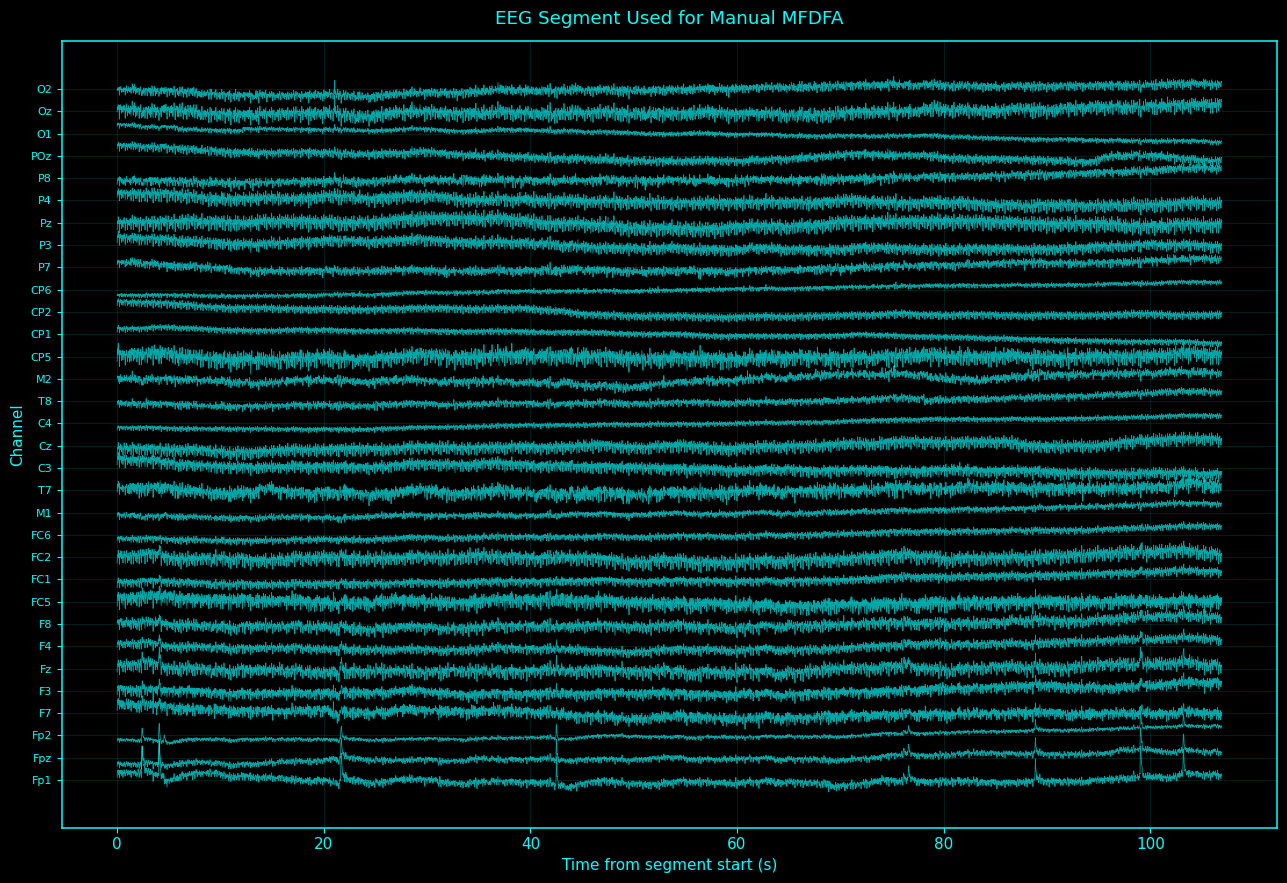

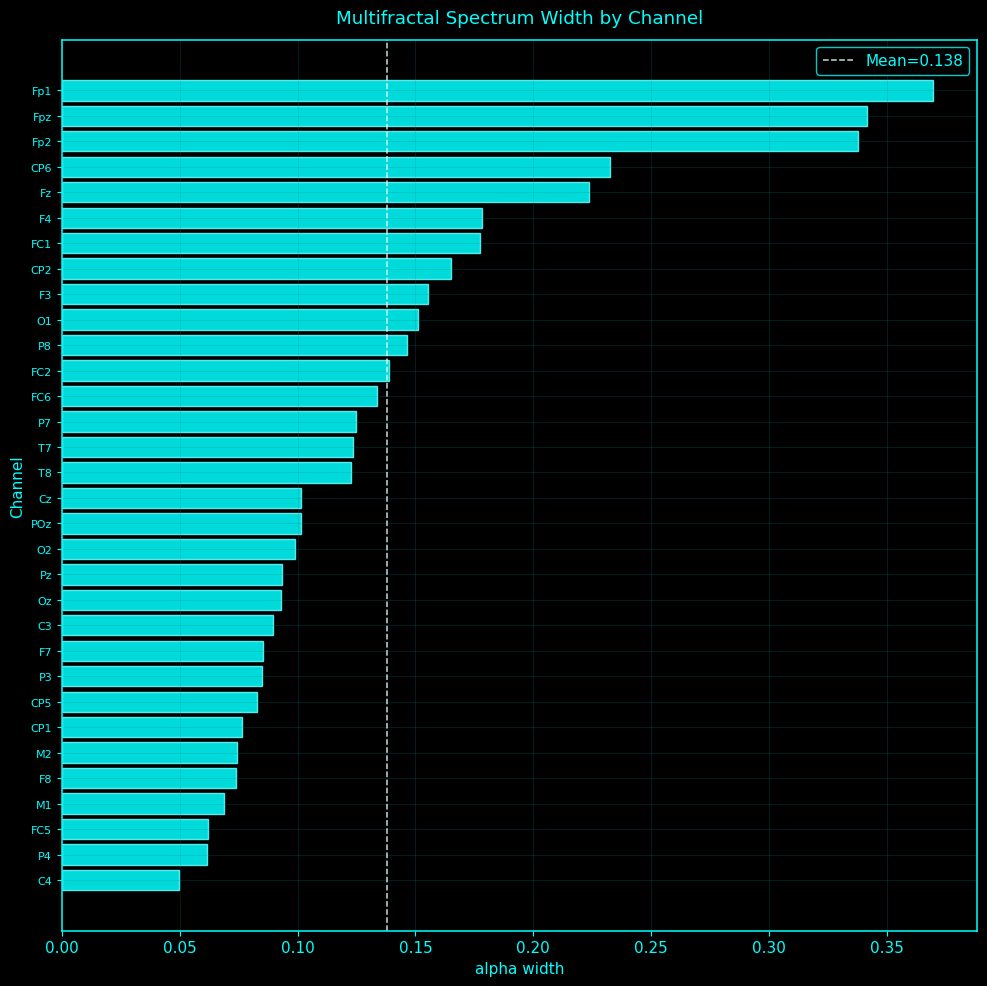

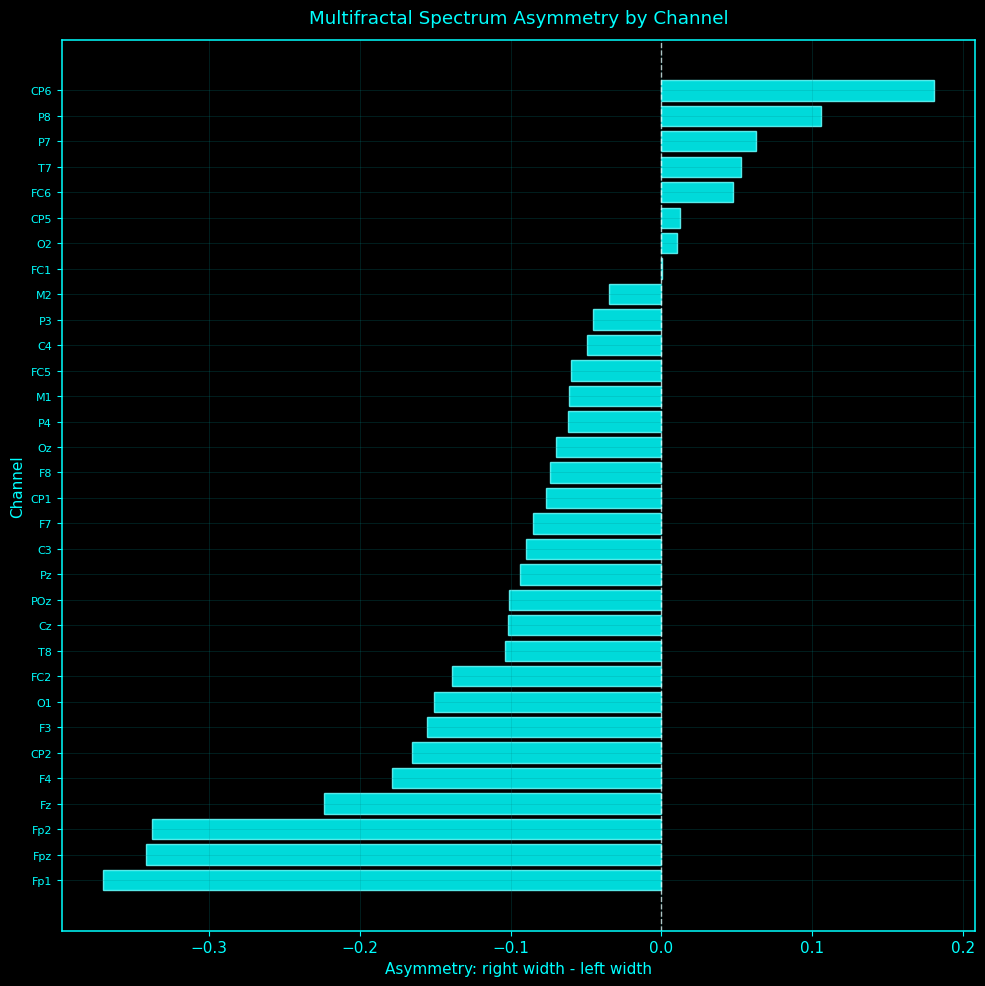

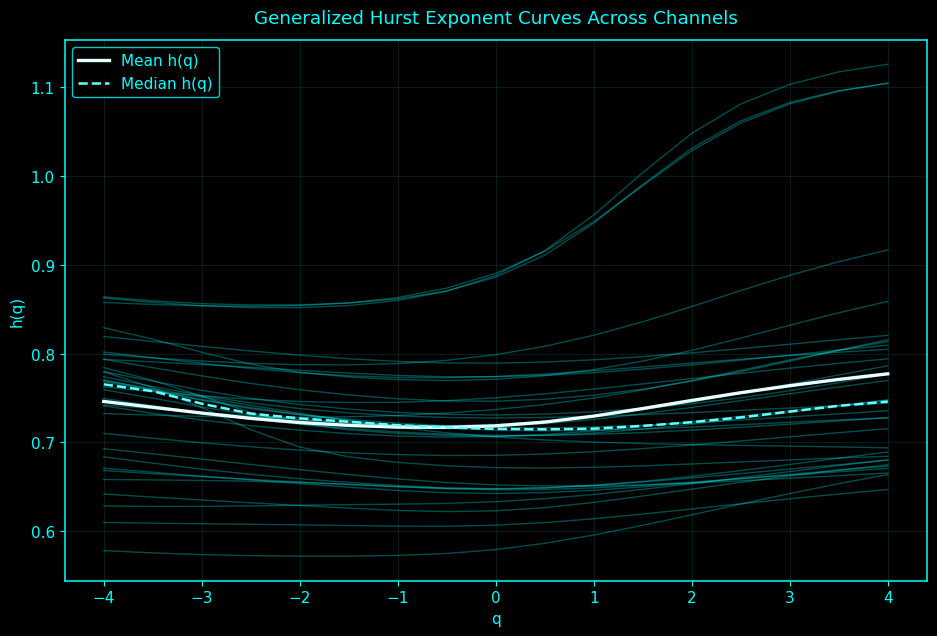

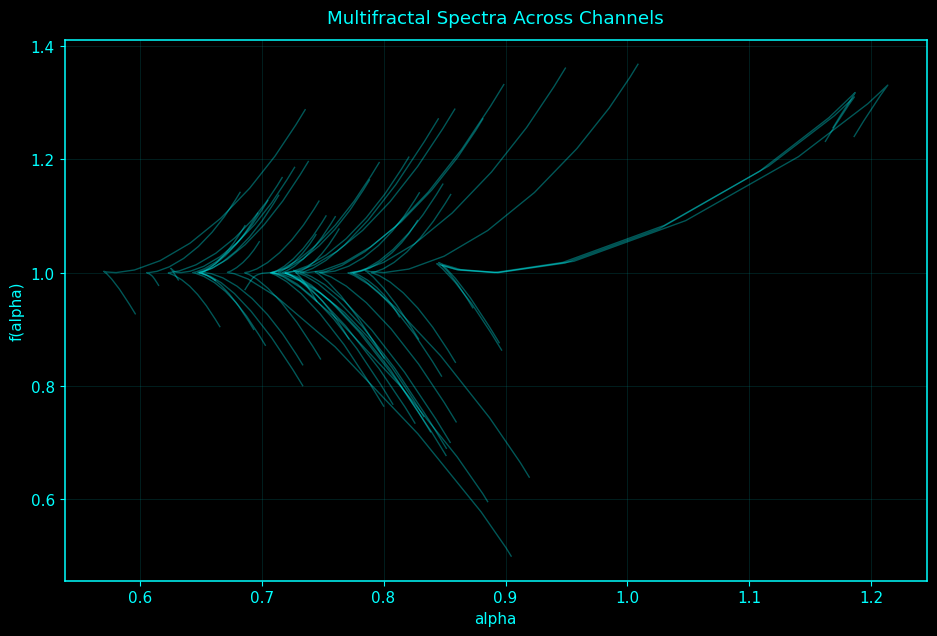

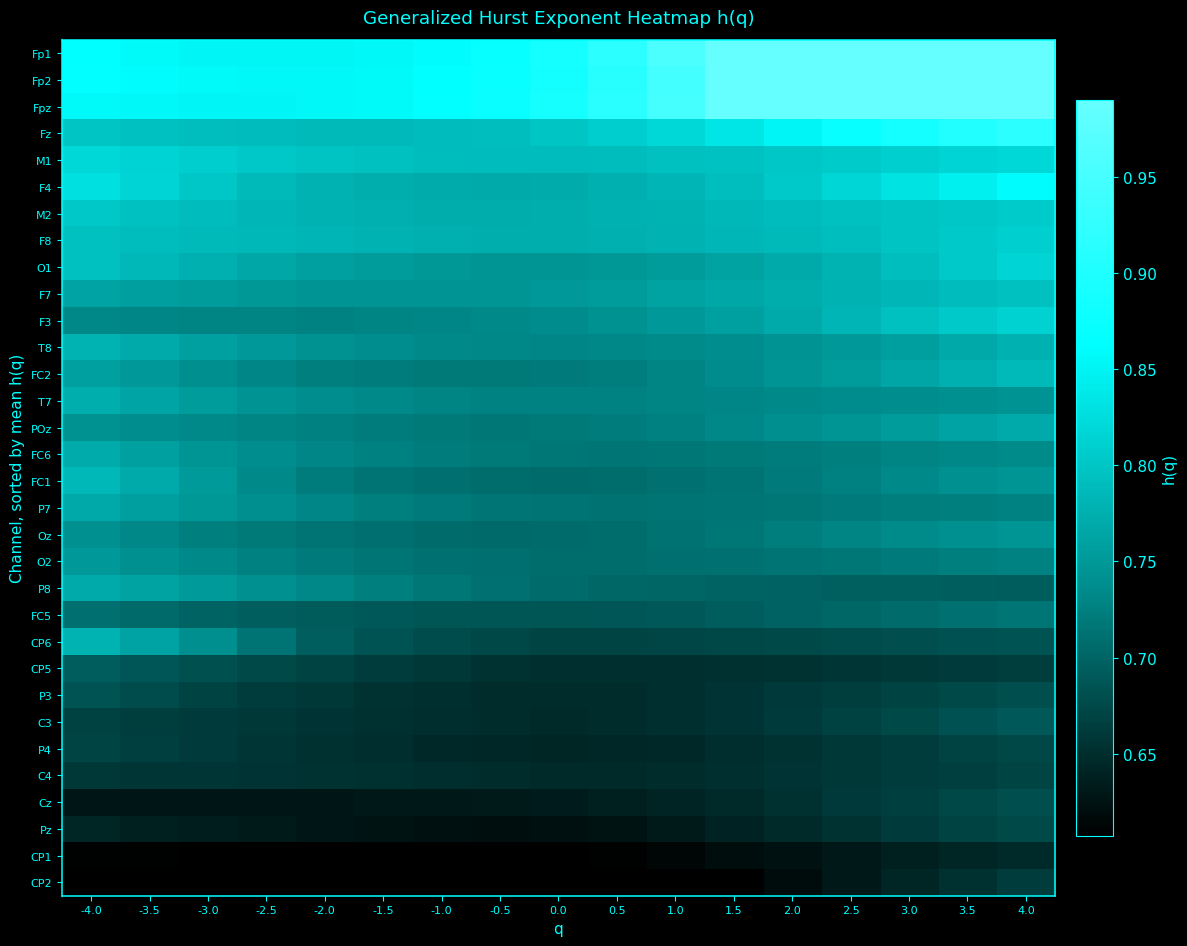

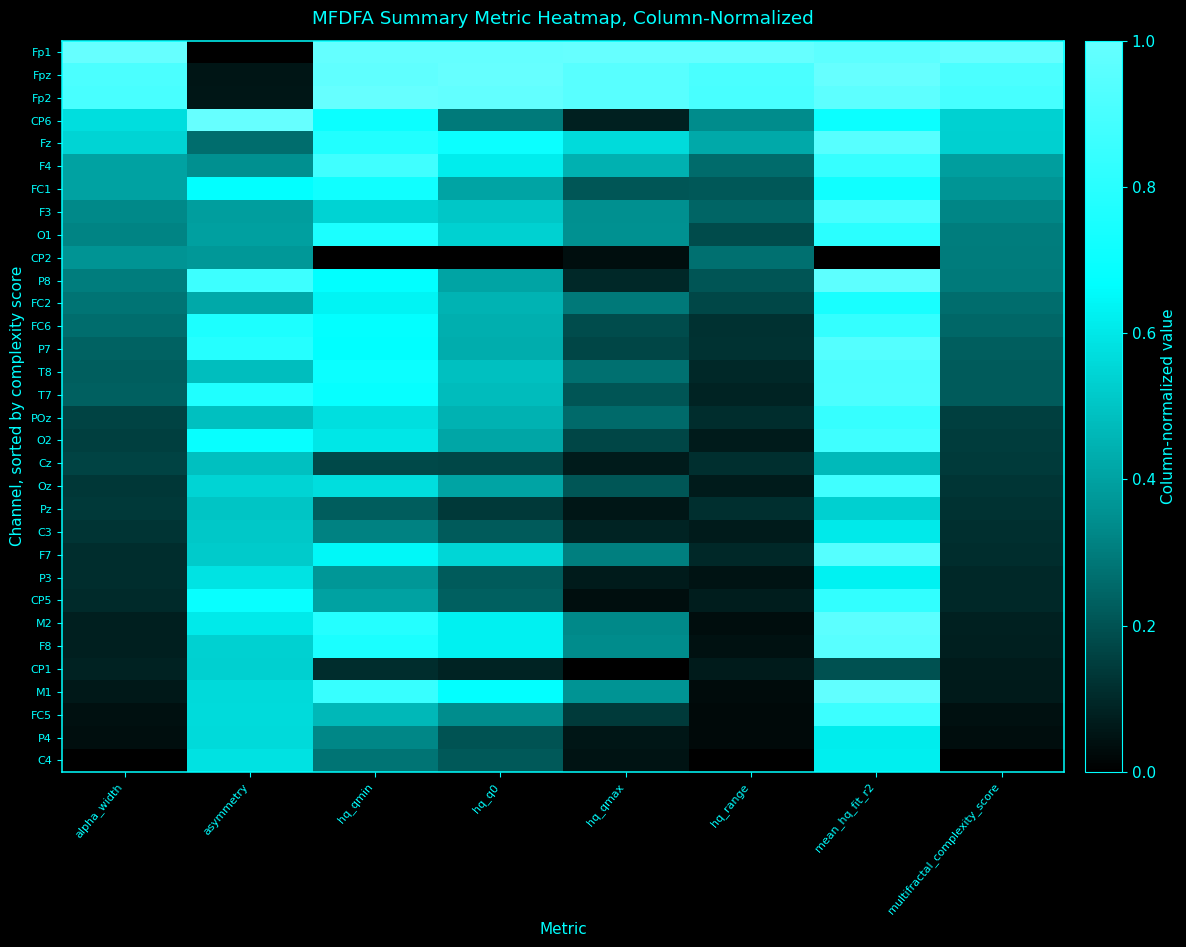

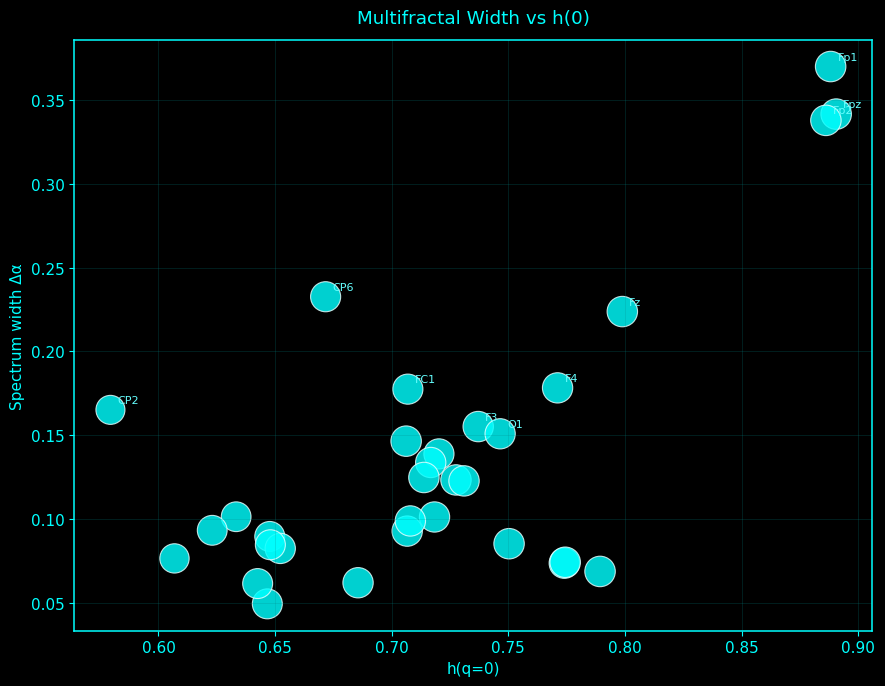

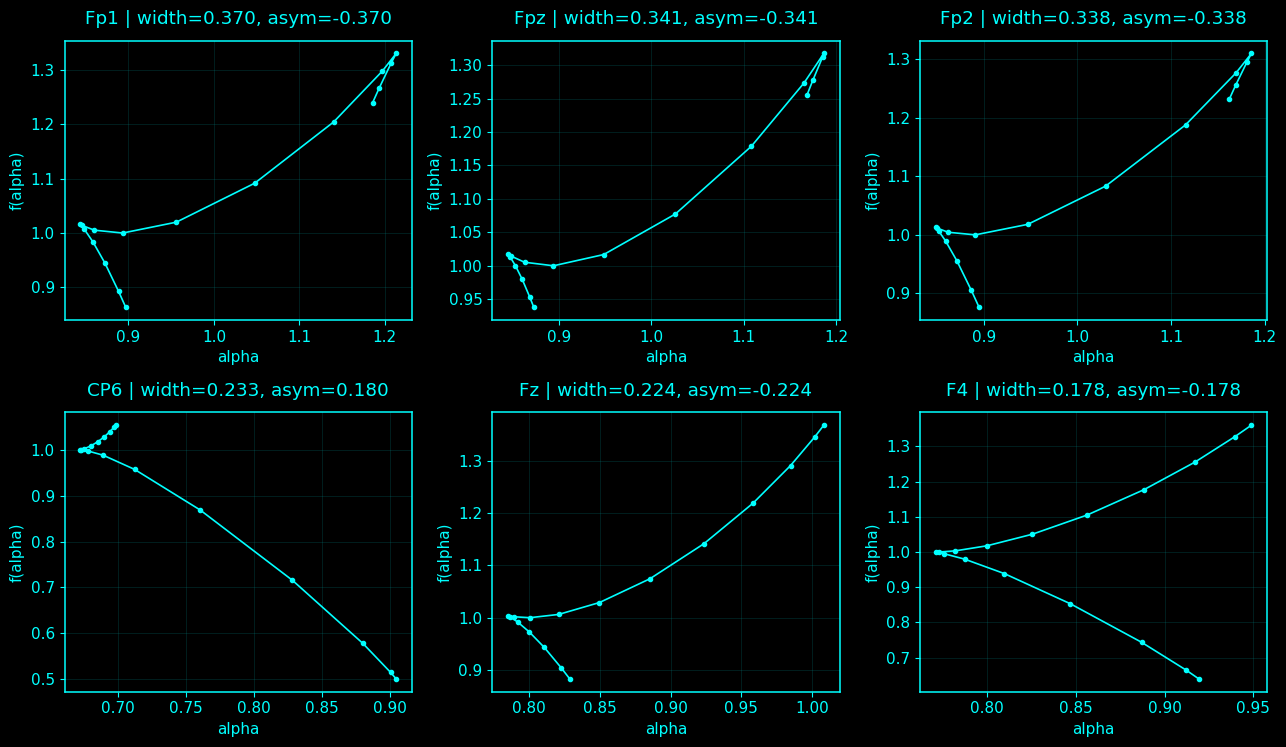

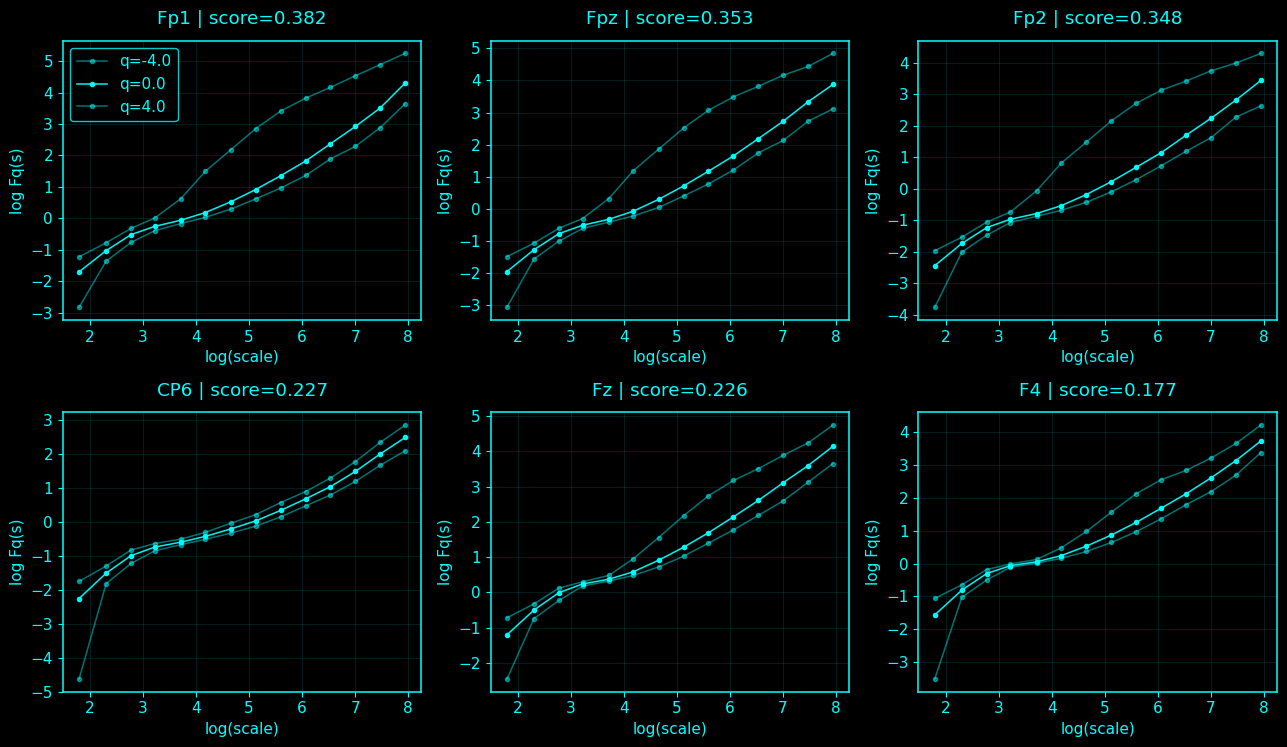

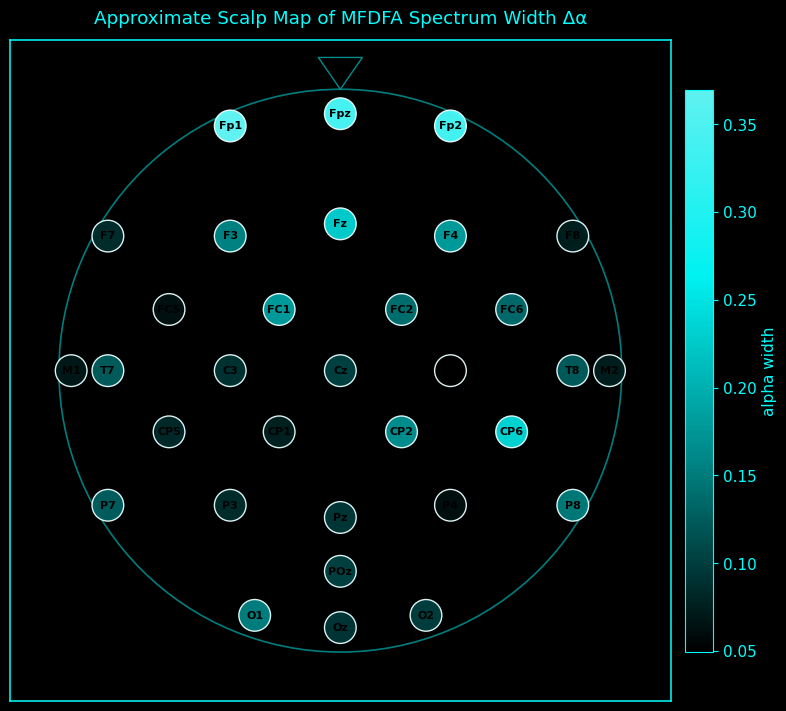

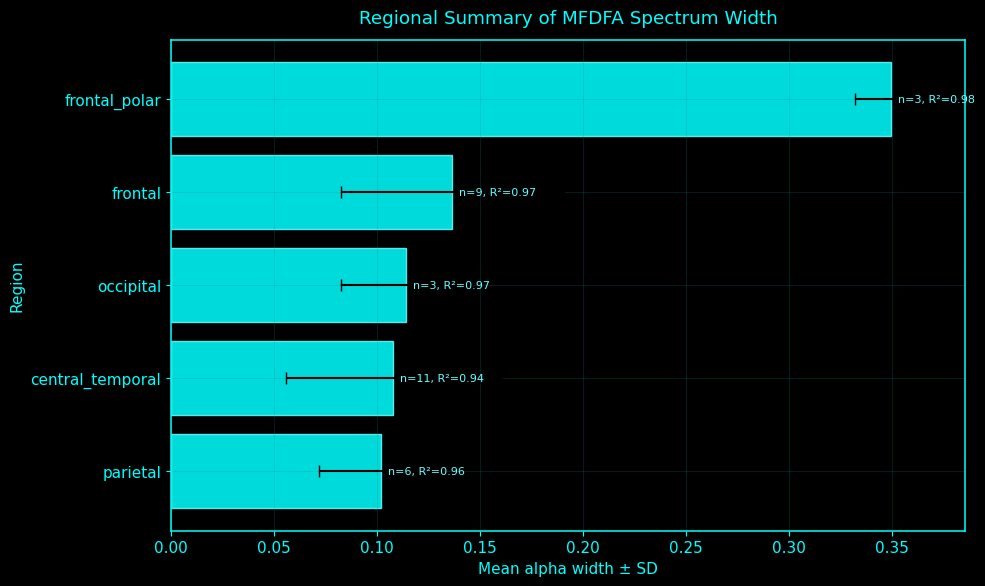

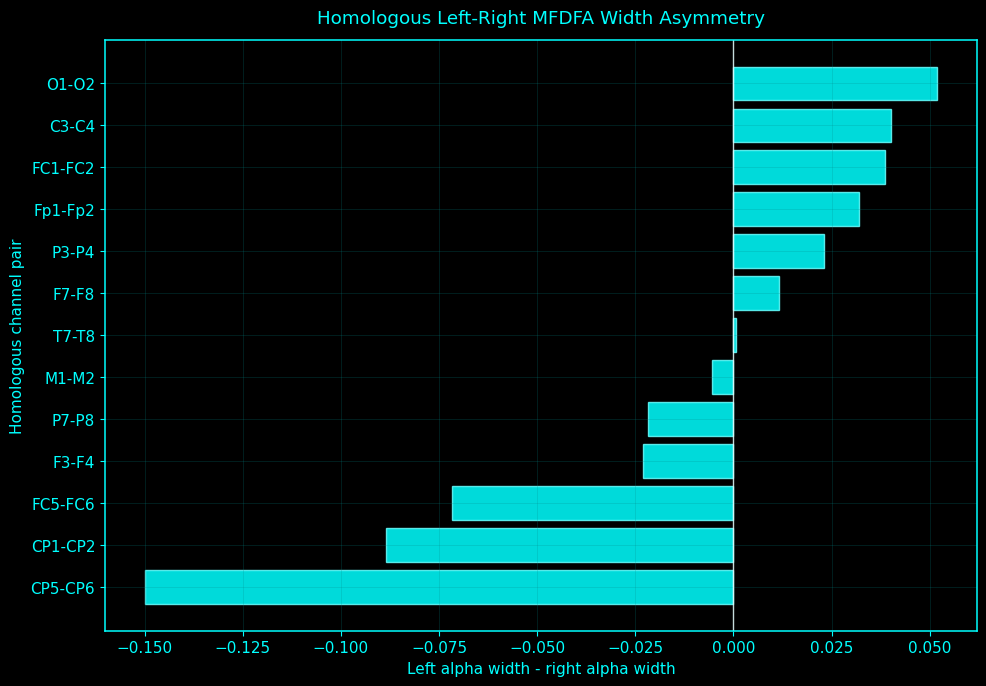


MANUAL EXPERT MFDFA ANALYSIS SUMMARY
FAST_OPTION: ultra
Rows computed: 32
Channels analyzed: 32
Scales used: 14
q values used: 17
Mean alpha width: 0.138133
Median alpha width: 0.112151
Mean h(q=0): 0.718706
Mean h(q) fit R²: 0.958709
Total elapsed: 0.23 min

Top 15 channels by multifractal complexity score:
channel  alpha_width  asymmetry  hq_qmin    hq_q0  hq_qmax  mean_hq_fit_r2  multifractal_complexity_score hemisphere           region
    Fp1     0.369818  -0.369818 0.862622 0.888154 1.125833        0.979719                       0.382417       left    frontal_polar
    Fpz     0.341461  -0.341461 0.857638 0.890523 1.104632        0.982953                       0.352831    midline    frontal_polar
    Fp2     0.337733  -0.337733 0.863890 0.886121 1.104393        0.979767                       0.347663      right    frontal_polar
    CP6     0.232611   0.180424 0.779566 0.671661 0.684475        0.950185                       0.227005      right central_temporal
     Fz     0.22375

In [1]:
import os
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

try:
    from IPython.display import display
    _HAVE_IPYTHON_DISPLAY = True
except Exception:
    display = None
    _HAVE_IPYTHON_DISPLAY = False


base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "results", "mfdfa_manual_expert_fast")
plots_dir = os.path.join(out_dir, "plots")
per_channel_dir = os.path.join(plots_dir, "per_channel")
gallery_dir = os.path.join(plots_dir, "galleries")

os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)
os.makedirs(per_channel_dir, exist_ok=True)
os.makedirs(gallery_dir, exist_ok=True)


FAST_OPTION = "ultra"   # options: "ultra", "fast", "balanced", "full"

if FAST_OPTION == "ultra":
    scale_min_power = 0.8
    scale_max_power = 3.45
    n_scales = 14
    q_vals = np.linspace(-4, 4, 17)
    poly_order = 1
    max_channels = None
    raw_plot_max_points = 4000
    save_per_channel_plots = False
    show_per_channel_plots = False
    per_channel_plot_top_n = 0
    spectrum_gallery_top_n = 6
    fq_gallery_top_n = 6
    run_temporal_stability = False
    temporal_windows = 4
    temporal_q_vals = np.array([-4, 0, 4], dtype=float)
    save_Fq_long_csv = True

elif FAST_OPTION == "fast":
    scale_min_power = 0.7
    scale_max_power = 3.75
    n_scales = 20
    q_vals = np.linspace(-5, 5, 25)
    poly_order = 1
    max_channels = None
    raw_plot_max_points = 10000
    save_per_channel_plots = True
    show_per_channel_plots = False
    per_channel_plot_top_n = None
    spectrum_gallery_top_n = 9
    fq_gallery_top_n = 9
    run_temporal_stability = True
    temporal_windows = 6
    temporal_q_vals = np.array([-5, 0, 5], dtype=float)
    save_Fq_long_csv = True

elif FAST_OPTION == "balanced":
    scale_min_power = 0.7
    scale_max_power = 4.0
    n_scales = 30
    q_vals = np.linspace(-5, 5, 41)
    poly_order = 1
    max_channels = None
    raw_plot_max_points = 20000
    save_per_channel_plots = True
    show_per_channel_plots = False
    per_channel_plot_top_n = None
    spectrum_gallery_top_n = 12
    fq_gallery_top_n = 12
    run_temporal_stability = True
    temporal_windows = 10
    temporal_q_vals = np.array([-5, -2, 0, 2, 5], dtype=float)
    save_Fq_long_csv = True

elif FAST_OPTION == "full":
    scale_min_power = 0.7
    scale_max_power = 4.0
    n_scales = 36
    q_vals = np.linspace(-6, 6, 49)
    poly_order = 2
    max_channels = None
    raw_plot_max_points = None
    save_per_channel_plots = True
    show_per_channel_plots = False
    per_channel_plot_top_n = None
    spectrum_gallery_top_n = 16
    fq_gallery_top_n = 16
    run_temporal_stability = True
    temporal_windows = 16
    temporal_q_vals = np.array([-6, -3, 0, 3, 6], dtype=float)
    save_Fq_long_csv = True

else:
    raise ValueError("FAST_OPTION must be one of: 'ultra', 'fast', 'balanced', 'full'.")


sampling_rate = 1000
start_time = 814.571
end_time = 921.515
start_idx = int(start_time * sampling_rate)
end_idx = int(end_time * sampling_rate)

SHOW_PLOTS_IN_NOTEBOOK = True
SAVE_PLOTS_TO_DISK = True
STANDARDIZE_SIGNAL = True

ACCENT = "#00FFFF"
ACCENT_SOFT = "#66FFFF"
ACCENT_DIM = "#008B8B"
WHITE = "#E8FFFF"
BLACK = "#000000"
eps = 1e-12

eeg_channels = [
    "Fp1", "Fpz", "Fp2", "F7", "F3", "Fz", "F4", "F8", "FC5", "FC1", "FC2", "FC6",
    "M1", "T7", "C3", "Cz", "C4", "T8", "M2", "CP5", "CP1", "CP2", "CP6",
    "P7", "P3", "Pz", "P4", "P8", "POz", "O1", "Oz", "O2"
]

if max_channels is not None:
    eeg_channels = eeg_channels[:max_channels]

left_channels = ["Fp1", "F7", "F3", "FC5", "FC1", "M1", "T7", "C3", "CP5", "CP1", "P7", "P3", "O1"]
right_channels = ["Fp2", "F8", "F4", "FC2", "FC6", "M2", "T8", "C4", "CP2", "CP6", "P8", "P4", "O2"]
midline_channels = ["Fpz", "Fz", "Cz", "Pz", "POz", "Oz"]

electrode_xy = {
    "Fp1": (-0.45, 1.00), "Fpz": (0.00, 1.05), "Fp2": (0.45, 1.00),
    "F7": (-0.95, 0.55), "F3": (-0.45, 0.55), "Fz": (0.00, 0.60), "F4": (0.45, 0.55), "F8": (0.95, 0.55),
    "FC5": (-0.70, 0.25), "FC1": (-0.25, 0.25), "FC2": (0.25, 0.25), "FC6": (0.70, 0.25),
    "M1": (-1.10, 0.00), "T7": (-0.95, 0.00), "C3": (-0.45, 0.00), "Cz": (0.00, 0.00), "C4": (0.45, 0.00), "T8": (0.95, 0.00), "M2": (1.10, 0.00),
    "CP5": (-0.70, -0.25), "CP1": (-0.25, -0.25), "CP2": (0.25, -0.25), "CP6": (0.70, -0.25),
    "P7": (-0.95, -0.55), "P3": (-0.45, -0.55), "Pz": (0.00, -0.60), "P4": (0.45, -0.55), "P8": (0.95, -0.55),
    "POz": (0.00, -0.82), "O1": (-0.35, -1.00), "Oz": (0.00, -1.05), "O2": (0.35, -1.00),
}

CYAN_DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "cyan_diverging",
    [ACCENT_DIM, BLACK, ACCENT_SOFT],
    N=256,
)

CYAN_SEQUENTIAL_CMAP = LinearSegmentedColormap.from_list(
    "cyan_sequential",
    [BLACK, ACCENT_DIM, ACCENT, ACCENT_SOFT],
    N=256,
)

plt.rcParams.update({
    "figure.facecolor": BLACK,
    "axes.facecolor": BLACK,
    "savefig.facecolor": BLACK,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT_DIM,
    "grid.alpha": 0.25,
    "legend.facecolor": BLACK,
    "legend.edgecolor": ACCENT,
    "legend.labelcolor": ACCENT,
    "font.size": 11,
})


def style_ax(ax, title=None, xlabel=None, ylabel=None, grid=True):
    ax.set_facecolor(BLACK)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
        spine.set_linewidth(1.1)
    ax.tick_params(axis="x", colors=ACCENT, labelcolor=ACCENT)
    ax.tick_params(axis="y", colors=ACCENT, labelcolor=ACCENT)
    if title is not None:
        ax.set_title(title, color=ACCENT, pad=12)
    if xlabel is not None:
        ax.set_xlabel(xlabel, color=ACCENT)
    if ylabel is not None:
        ax.set_ylabel(ylabel, color=ACCENT)
    if grid:
        ax.grid(True, alpha=0.22, color=ACCENT_DIM, linewidth=0.7)
    else:
        ax.grid(False)


def save_fig(fig, path, show=True):
    fig.tight_layout()
    if SAVE_PLOTS_TO_DISK and path is not None:
        fig.savefig(path, dpi=220, bbox_inches="tight", facecolor=BLACK)
    if SHOW_PLOTS_IN_NOTEBOOK and show and _HAVE_IPYTHON_DISPLAY:
        display(fig)
    plt.close(fig)


def short_label(x, max_len=24):
    x = str(x)
    return x if len(x) <= max_len else x[:max_len - 1] + "…"


def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")
    if x.shape[1] == n_channels_expected:
        return x
    if x.shape[0] == n_channels_expected:
        return x.T
    if x.shape[1] >= n_channels_expected:
        return x[:, :n_channels_expected]
    if x.shape[0] >= n_channels_expected:
        return x.T[:, :n_channels_expected]
    raise ValueError(f"Unexpected EEG shape: {x.shape}")


def safe_zscore_1d(x):
    x = np.asarray(x, dtype=float).reshape(-1)
    x = np.where(np.isfinite(x), x, np.nan)
    if np.any(~np.isfinite(x)):
        med = np.nanmedian(x)
        if not np.isfinite(med):
            med = 0.0
        x = np.nan_to_num(x, nan=med, posinf=med, neginf=med)
    return (x - np.mean(x)) / (np.std(x) + eps)


def downsample_for_plot(X, max_points=None):
    X = np.asarray(X)
    if max_points is None or X.shape[0] <= max_points:
        return X, np.arange(X.shape[0])
    step = int(np.ceil(X.shape[0] / max_points))
    idx = np.arange(0, X.shape[0], step)
    return X[idx], idx


def add_channel_metadata(df):
    df = df.copy()
    hemisphere = []
    region = []

    for ch in df["channel"]:
        if ch in left_channels:
            hemisphere.append("left")
        elif ch in right_channels:
            hemisphere.append("right")
        elif ch in midline_channels:
            hemisphere.append("midline")
        else:
            hemisphere.append("unknown")

        if ch.startswith("Fp"):
            region.append("frontal_polar")
        elif ch.startswith("F") or ch.startswith("FC"):
            region.append("frontal")
        elif ch.startswith("C") or ch.startswith("T") or ch.startswith("M"):
            region.append("central_temporal")
        elif ch.startswith("CP") or ch.startswith("P"):
            region.append("parietal")
        elif ch.startswith("PO") or ch.startswith("O"):
            region.append("occipital")
        else:
            region.append("unknown")

    df["hemisphere"] = hemisphere
    df["region"] = region
    return df


def make_scales(num_timepoints):
    lag = np.logspace(scale_min_power, scale_max_power, n_scales).astype(int)
    lag = np.unique(lag)
    lag = lag[(lag > poly_order + 2) & (lag < num_timepoints // 4)]
    lag = lag[lag >= 4]
    if len(lag) < 5:
        raise ValueError("Too few valid MFDFA scales after filtering. Increase segment length or reduce scale_min/scale_max.")
    return lag.astype(int)


_projection_cache = {}

def detrend_segments_matrix(segments, order):
    segments = np.asarray(segments, dtype=float)
    nseg, s = segments.shape
    key = (s, order)

    if key not in _projection_cache:
        t = np.linspace(-1, 1, s)
        design_cols = [t ** k for k in range(order + 1)]
        design = np.column_stack(design_cols)
        pinv = np.linalg.pinv(design)
        projection = design @ pinv
        _projection_cache[key] = projection

    P = _projection_cache[key]
    trend = segments @ P.T
    resid = segments - trend

    return resid


def mfdfa_manual_fast(x, scales, q_vals, order=1):
    x = np.asarray(x, dtype=float).reshape(-1)

    if STANDARDIZE_SIGNAL:
        x = safe_zscore_1d(x)
    else:
        x = x - np.mean(x)

    N = len(x)
    profile = np.cumsum(x - np.mean(x))
    Fq = np.full((len(scales), len(q_vals)), np.nan, dtype=float)
    segment_counts = np.zeros(len(scales), dtype=int)

    for si, s in enumerate(scales):
        s = int(s)
        Ns = N // s

        if Ns < 2 or s <= order + 2:
            continue

        forward = profile[:Ns * s].reshape(Ns, s)
        backward = profile[N - Ns * s:].reshape(Ns, s)

        segments = np.vstack([forward, backward])
        resid = detrend_segments_matrix(segments, order=order)

        F2_segments = np.mean(resid ** 2, axis=1)
        F2_segments = np.maximum(F2_segments, eps)
        segment_counts[si] = len(F2_segments)

        log_F2_mean = np.mean(np.log(F2_segments))

        for qi, q in enumerate(q_vals):
            if np.isclose(q, 0.0):
                Fq[si, qi] = np.exp(0.5 * log_F2_mean)
            else:
                Fq[si, qi] = (np.mean(F2_segments ** (q / 2.0))) ** (1.0 / q)

    return np.asarray(scales, dtype=float), Fq, segment_counts


def estimate_hq(scales, Fq, min_points=5):
    scales = np.asarray(scales, dtype=float)
    Fq = np.asarray(Fq, dtype=float)

    log_s = np.log(scales)
    hq = np.full(Fq.shape[1], np.nan, dtype=float)
    intercepts = np.full(Fq.shape[1], np.nan, dtype=float)
    fit_r2 = np.full(Fq.shape[1], np.nan, dtype=float)
    fit_points = np.zeros(Fq.shape[1], dtype=int)

    for qi in range(Fq.shape[1]):
        y = Fq[:, qi]
        mask = np.isfinite(y) & (y > 0) & np.isfinite(log_s)

        if np.sum(mask) >= min_points:
            x_fit = log_s[mask]
            y_fit = np.log(y[mask])

            coef = np.polyfit(x_fit, y_fit, 1)
            y_hat = coef[0] * x_fit + coef[1]

            ss_res = np.sum((y_fit - y_hat) ** 2)
            ss_tot = np.sum((y_fit - np.mean(y_fit)) ** 2)

            hq[qi] = coef[0]
            intercepts[qi] = coef[1]
            fit_r2[qi] = 1.0 - ss_res / (ss_tot + eps)
            fit_points[qi] = int(np.sum(mask))

    return hq, intercepts, fit_r2, fit_points


def multifractal_spectrum_from_hq(q_vals, hq):
    q_vals = np.asarray(q_vals, dtype=float)
    hq = np.asarray(hq, dtype=float)

    tau = np.full_like(q_vals, np.nan, dtype=float)
    alpha = np.full_like(q_vals, np.nan, dtype=float)
    f_alpha = np.full_like(q_vals, np.nan, dtype=float)

    mask = np.isfinite(hq) & np.isfinite(q_vals)

    if np.sum(mask) < 3:
        return tau, alpha, f_alpha

    qv = q_vals[mask]
    hv = hq[mask]

    tau_v = qv * hv - 1.0
    alpha_v = np.gradient(tau_v, qv)
    f_v = qv * alpha_v - tau_v

    tau[mask] = tau_v
    alpha[mask] = alpha_v
    f_alpha[mask] = f_v

    return tau, alpha, f_alpha


def summarize_spectrum(alpha, f_alpha, hq, hq_r2, q_vals):
    mask = np.isfinite(alpha) & np.isfinite(f_alpha)

    def nearest_h(q_target):
        idx = int(np.argmin(np.abs(q_vals - q_target)))
        return float(hq[idx]) if np.isfinite(hq[idx]) else np.nan

    q_min = float(np.nanmin(q_vals))
    q_max = float(np.nanmax(q_vals))

    summary = {
        "hq_qmin": nearest_h(q_min),
        "hq_q0": nearest_h(0.0),
        "hq_qmax": nearest_h(q_max),
        "mean_hq_fit_r2": float(np.nanmean(hq_r2)) if np.any(np.isfinite(hq_r2)) else np.nan,
        "min_hq_fit_r2": float(np.nanmin(hq_r2)) if np.any(np.isfinite(hq_r2)) else np.nan,
        "hq_range": float(np.nanmax(hq) - np.nanmin(hq)) if np.sum(np.isfinite(hq)) >= 2 else np.nan,
    }

    if np.sum(mask) < 3:
        summary.update({
            "alpha_min": np.nan,
            "alpha_max": np.nan,
            "alpha_width": np.nan,
            "alpha_at_peak": np.nan,
            "f_peak": np.nan,
            "asymmetry": np.nan,
            "left_width": np.nan,
            "right_width": np.nan,
            "multifractal_complexity_score": np.nan,
        })
        return summary

    a = alpha[mask]
    f = f_alpha[mask]

    alpha_min = float(np.min(a))
    alpha_max = float(np.max(a))
    alpha_width = float(alpha_max - alpha_min)

    peak_idx = int(np.argmax(f))
    alpha_at_peak = float(a[peak_idx])
    f_peak = float(f[peak_idx])

    left_width = float(alpha_at_peak - alpha_min)
    right_width = float(alpha_max - alpha_at_peak)
    asymmetry = float(right_width - left_width)

    score = (
        alpha_width
        * max(summary["mean_hq_fit_r2"], 0.0)
        * (1.0 + 0.15 * abs(asymmetry))
    )

    summary.update({
        "alpha_min": alpha_min,
        "alpha_max": alpha_max,
        "alpha_width": alpha_width,
        "alpha_at_peak": alpha_at_peak,
        "f_peak": f_peak,
        "asymmetry": asymmetry,
        "left_width": left_width,
        "right_width": right_width,
        "multifractal_complexity_score": float(score),
    })

    return summary


def compute_mfdfa_for_channel(x, scales, q_vals, order):
    scales_out, Fq, segment_counts = mfdfa_manual_fast(x, scales, q_vals, order=order)
    hq, hq_intercepts, hq_r2, hq_fit_points = estimate_hq(scales_out, Fq)
    tau_q, alpha_q, f_alpha_q = multifractal_spectrum_from_hq(q_vals, hq)
    spec_summary = summarize_spectrum(alpha_q, f_alpha_q, hq, hq_r2, q_vals)

    return {
        "scales": scales_out,
        "q_vals": q_vals,
        "Fq": Fq,
        "segment_counts": segment_counts,
        "hq": hq,
        "hq_intercepts": hq_intercepts,
        "hq_r2": hq_r2,
        "hq_fit_points": hq_fit_points,
        "tau_q": tau_q,
        "alpha_q": alpha_q,
        "f_alpha_q": f_alpha_q,
        "summary": spec_summary,
    }


def compute_temporal_mfdfa(EEG_segment, channel_names, scales_base, q_vals_temporal, n_windows=6):
    n = EEG_segment.shape[0]
    window_len = max(int(np.max(scales_base) * 5), n // max(n_windows, 1), 2048)

    rows = []

    for w in range(n_windows):
        s0 = w * window_len
        e0 = min(n, s0 + window_len)

        if e0 - s0 < 2048:
            continue

        local_scales = scales_base[scales_base < (e0 - s0) // 4]

        if len(local_scales) < 5:
            continue

        for ch_idx, ch in enumerate(channel_names):
            try:
                x = EEG_segment[s0:e0, ch_idx]
                res = compute_mfdfa_for_channel(x, local_scales, q_vals_temporal, poly_order)
                summary = res["summary"]

                rows.append({
                    "window": w + 1,
                    "channel": ch,
                    "start_sample": s0,
                    "end_sample": e0,
                    "start_sec_relative": s0 / sampling_rate,
                    "end_sec_relative": e0 / sampling_rate,
                    "alpha_width": summary["alpha_width"],
                    "asymmetry": summary["asymmetry"],
                    "hq_q0": summary["hq_q0"],
                    "mean_hq_fit_r2": summary["mean_hq_fit_r2"],
                    "multifractal_complexity_score": summary["multifractal_complexity_score"],
                    "status": "ok",
                    "error": "",
                })

            except Exception as e:
                rows.append({
                    "window": w + 1,
                    "channel": ch,
                    "start_sample": s0,
                    "end_sample": e0,
                    "start_sec_relative": s0 / sampling_rate,
                    "end_sec_relative": e0 / sampling_rate,
                    "alpha_width": np.nan,
                    "asymmetry": np.nan,
                    "hq_q0": np.nan,
                    "mean_hq_fit_r2": np.nan,
                    "multifractal_complexity_score": np.nan,
                    "status": "error",
                    "error": f"{type(e).__name__}: {e}",
                })

    return pd.DataFrame(rows)


def plot_raw_eeg_offset(EEG_segment, channel_names):
    Xp, idx = downsample_for_plot(EEG_segment, raw_plot_max_points)
    t = idx / sampling_rate
    Xz = np.column_stack([safe_zscore_1d(Xp[:, i]) for i in range(Xp.shape[1])])
    offset = 5.0

    fig_height = min(10.5, max(6.0, 0.28 * len(channel_names)))
    fig, ax = plt.subplots(figsize=(13, fig_height))

    for i, ch in enumerate(channel_names):
        ax.plot(t, Xz[:, i] + i * offset, color=ACCENT, linewidth=0.55, alpha=0.65)

    ax.set_yticks(np.arange(len(channel_names)) * offset)
    ax.set_yticklabels(channel_names, color=ACCENT, fontsize=8)

    style_ax(
        ax,
        title="EEG Segment Used for Manual MFDFA",
        xlabel="Time from segment start (s)",
        ylabel="Channel",
    )

    path = os.path.join(plots_dir, f"00_raw_eeg_segment_offset_{FAST_OPTION}.png")
    save_fig(fig, path)
    return path


def plot_per_channel_original_style(channel_name, x, res):
    if not save_per_channel_plots:
        return []

    paths = []

    scales_out = res["scales"]
    Fq = res["Fq"]
    hq = res["hq"]
    alpha_q = res["alpha_q"]
    f_alpha_q = res["f_alpha_q"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor=BLACK)
    ax1, ax2 = axes

    Xp, idx = downsample_for_plot(x, raw_plot_max_points)
    ax1.plot(idx, safe_zscore_1d(Xp), color=ACCENT, linewidth=0.9, alpha=0.85)
    style_ax(ax1, title=f"{channel_name}: EEG Segment", xlabel="Samples", ylabel="Z-scored amplitude")

    for qi in range(len(q_vals)):
        y = Fq[:, qi]
        mask = np.isfinite(y) & (y > 0)
        if np.sum(mask) >= 2:
            alpha = 0.18 if qi not in [0, len(q_vals) // 2, len(q_vals) - 1] else 0.75
            lw = 0.8 if alpha < 0.5 else 1.4
            ax2.loglog(scales_out[mask], y[mask], color=ACCENT, alpha=alpha, linewidth=lw)

    style_ax(
        ax2,
        title=f"{channel_name}: Manual MFDFA Fq(s)",
        xlabel="Scale",
        ylabel="Fq(s)",
    )

    path1 = os.path.join(per_channel_dir, f"{channel_name}_signal_and_Fq_{FAST_OPTION}.png")
    save_fig(fig, path1, show=show_per_channel_plots)
    paths.append(path1)

    fig, ax = plt.subplots(figsize=(5.5, 4.3), facecolor=BLACK)
    ax.plot(q_vals, hq, marker="o", color=ACCENT, linewidth=1.3, markersize=3)
    style_ax(
        ax,
        title=f"{channel_name}: h(q)",
        xlabel="q",
        ylabel="Generalized Hurst exponent",
    )
    path2 = os.path.join(per_channel_dir, f"{channel_name}_hq_{FAST_OPTION}.png")
    save_fig(fig, path2, show=show_per_channel_plots)
    paths.append(path2)

    fig, ax = plt.subplots(figsize=(5.5, 4.3), facecolor=BLACK)
    mask = np.isfinite(alpha_q) & np.isfinite(f_alpha_q)
    ax.plot(alpha_q[mask], f_alpha_q[mask], marker="o", color=ACCENT, linewidth=1.3, markersize=3)
    style_ax(
        ax,
        title=f"{channel_name}: Multifractal Spectrum",
        xlabel="alpha",
        ylabel="f(alpha)",
    )
    path3 = os.path.join(per_channel_dir, f"{channel_name}_multifractal_spectrum_{FAST_OPTION}.png")
    save_fig(fig, path3, show=show_per_channel_plots)
    paths.append(path3)

    return paths


def plot_alpha_width_bar(summary_df):
    plot_df = summary_df.sort_values("alpha_width", ascending=True, na_position="first")

    fig, ax = plt.subplots(figsize=(10, 10))

    y = np.arange(len(plot_df))

    ax.barh(
        y,
        plot_df["alpha_width"].fillna(0.0).values,
        color=ACCENT,
        edgecolor=ACCENT_SOFT,
        alpha=0.86,
    )

    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["channel"].values, color=ACCENT, fontsize=8)

    mean_val = plot_df["alpha_width"].mean()
    ax.axvline(mean_val, color=WHITE, linestyle="--", linewidth=1.1, alpha=0.85, label=f"Mean={mean_val:.3f}")

    style_ax(
        ax,
        title="Multifractal Spectrum Width by Channel",
        xlabel="alpha width",
        ylabel="Channel",
    )

    leg = ax.legend(loc="best", frameon=True)
    for text in leg.get_texts():
        text.set_color(ACCENT)

    path = os.path.join(plots_dir, f"01_mfdfa_alpha_width_barh_{FAST_OPTION}.png")
    save_fig(fig, path)
    return path


def plot_asymmetry_bar(summary_df):
    plot_df = summary_df.sort_values("asymmetry", ascending=True, na_position="first")

    fig, ax = plt.subplots(figsize=(10, 10))

    y = np.arange(len(plot_df))

    ax.barh(
        y,
        plot_df["asymmetry"].fillna(0.0).values,
        color=ACCENT,
        edgecolor=ACCENT_SOFT,
        alpha=0.86,
    )

    ax.axvline(0.0, color=WHITE, linestyle="--", linewidth=1.0, alpha=0.75)

    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["channel"].values, color=ACCENT, fontsize=8)

    style_ax(
        ax,
        title="Multifractal Spectrum Asymmetry by Channel",
        xlabel="Asymmetry: right width - left width",
        ylabel="Channel",
    )

    path = os.path.join(plots_dir, f"02_mfdfa_asymmetry_barh_{FAST_OPTION}.png")
    save_fig(fig, path)
    return path


def plot_hq_all_channels(mfdfa_results):
    fig, ax = plt.subplots(figsize=(9.5, 6.5))

    for item in mfdfa_results:
        mask = np.isfinite(item["hq"])
        if np.sum(mask) >= 2:
            ax.plot(q_vals[mask], item["hq"][mask], color=ACCENT, alpha=0.30, linewidth=1.0)

    hq_stack = np.array([item["hq"] for item in mfdfa_results], dtype=float)

    mean_hq = np.nanmean(hq_stack, axis=0)
    med_hq = np.nanmedian(hq_stack, axis=0)

    ax.plot(q_vals, mean_hq, color=WHITE, linewidth=2.4, label="Mean h(q)")
    ax.plot(q_vals, med_hq, color=ACCENT_SOFT, linewidth=1.8, linestyle="--", label="Median h(q)")

    style_ax(
        ax,
        title="Generalized Hurst Exponent Curves Across Channels",
        xlabel="q",
        ylabel="h(q)",
    )

    leg = ax.legend(loc="best", frameon=True)
    for text in leg.get_texts():
        text.set_color(ACCENT)

    path = os.path.join(plots_dir, f"03_mfdfa_hq_all_channels_{FAST_OPTION}.png")
    save_fig(fig, path)
    return path


def plot_spectra_all_channels(mfdfa_results):
    fig, ax = plt.subplots(figsize=(9.5, 6.5))

    for item in mfdfa_results:
        a = item["alpha_q"]
        f = item["f_alpha_q"]
        mask = np.isfinite(a) & np.isfinite(f)
        if np.sum(mask) >= 2:
            ax.plot(a[mask], f[mask], color=ACCENT, alpha=0.34, linewidth=1.0)

    style_ax(
        ax,
        title="Multifractal Spectra Across Channels",
        xlabel="alpha",
        ylabel="f(alpha)",
    )

    path = os.path.join(plots_dir, f"04_mfdfa_spectra_all_channels_{FAST_OPTION}.png")
    save_fig(fig, path)
    return path


def plot_hq_heatmap(hq_df):
    pivot = hq_df.pivot_table(index="channel", columns="q", values="hq", aggfunc="mean")

    if pivot.empty:
        return None

    order = pivot.mean(axis=1).sort_values(ascending=False).index
    pivot = pivot.loc[order]

    M = pivot.to_numpy(dtype=float)

    fig_height = min(10.5, max(7.0, 0.30 * len(pivot.index)))
    fig, ax = plt.subplots(figsize=(12, fig_height))

    finite = M[np.isfinite(M)]
    vmin = np.nanpercentile(finite, 3) if finite.size else 0
    vmax = np.nanpercentile(finite, 97) if finite.size else 1

    im = ax.imshow(
        M,
        aspect="auto",
        interpolation="nearest",
        cmap=CYAN_SEQUENTIAL_CMAP,
        vmin=vmin,
        vmax=vmax,
    )

    q_labels = [f"{q:.1f}" if i % max(1, len(pivot.columns) // 10) == 0 else "" for i, q in enumerate(pivot.columns)]

    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels(q_labels, color=ACCENT, fontsize=8)

    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index, color=ACCENT, fontsize=8)

    style_ax(
        ax,
        title="Generalized Hurst Exponent Heatmap h(q)",
        xlabel="q",
        ylabel="Channel, sorted by mean h(q)",
        grid=False,
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.set_label("h(q)", color=ACCENT)

    path = os.path.join(plots_dir, f"05_hq_heatmap_{FAST_OPTION}.png")
    save_fig(fig, path)
    return path


def plot_summary_metric_heatmap(summary_df):
    metric_cols = [
        "alpha_width",
        "asymmetry",
        "hq_qmin",
        "hq_q0",
        "hq_qmax",
        "hq_range",
        "mean_hq_fit_r2",
        "multifractal_complexity_score",
    ]

    metric_cols = [c for c in metric_cols if c in summary_df.columns]

    df = summary_df.copy()
    df = df.sort_values("multifractal_complexity_score", ascending=False)

    M = df[metric_cols].to_numpy(dtype=float)
    M_norm = np.zeros_like(M, dtype=float)

    for j in range(M.shape[1]):
        col = M[:, j]
        finite = col[np.isfinite(col)]

        if finite.size == 0 or np.nanmax(finite) == np.nanmin(finite):
            continue

        M_norm[:, j] = (col - np.nanmin(finite)) / (np.nanmax(finite) - np.nanmin(finite) + eps)

    fig_height = min(10.5, max(7.0, 0.30 * len(df)))
    fig, ax = plt.subplots(figsize=(12, fig_height))

    im = ax.imshow(
        M_norm,
        aspect="auto",
        interpolation="nearest",
        cmap=CYAN_SEQUENTIAL_CMAP,
        vmin=0,
        vmax=1,
    )

    ax.set_xticks(np.arange(len(metric_cols)))
    ax.set_xticklabels(metric_cols, rotation=50, ha="right", color=ACCENT, fontsize=8)

    ax.set_yticks(np.arange(len(df)))
    ax.set_yticklabels(df["channel"], color=ACCENT, fontsize=8)

    style_ax(
        ax,
        title="MFDFA Summary Metric Heatmap, Column-Normalized",
        xlabel="Metric",
        ylabel="Channel, sorted by complexity score",
        grid=False,
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.set_label("Column-normalized value", color=ACCENT)

    path = os.path.join(plots_dir, f"06_mfdfa_summary_metric_heatmap_{FAST_OPTION}.png")
    save_fig(fig, path)
    return path


def plot_width_vs_hq0(summary_df):
    df = summary_df.copy()
    df = df[np.isfinite(df["alpha_width"]) & np.isfinite(df["hq_q0"])]

    if df.empty:
        return None

    fig, ax = plt.subplots(figsize=(9, 7))

    sizes = 70 + 420 * np.clip(df["mean_hq_fit_r2"].fillna(0).to_numpy(dtype=float), 0, 1)

    ax.scatter(
        df["hq_q0"],
        df["alpha_width"],
        s=sizes,
        c=ACCENT,
        edgecolors=WHITE,
        linewidths=0.8,
        alpha=0.82,
    )

    for _, row in df.sort_values("multifractal_complexity_score", ascending=False).head(10).iterrows():
        ax.annotate(
            row["channel"],
            (row["hq_q0"], row["alpha_width"]),
            xytext=(5, 5),
            textcoords="offset points",
            color=ACCENT_SOFT,
            fontsize=8,
        )

    style_ax(
        ax,
        title="Multifractal Width vs h(0)",
        xlabel="h(q=0)",
        ylabel="Spectrum width Δα",
    )

    path = os.path.join(plots_dir, f"07_width_vs_hq0_scatter_{FAST_OPTION}.png")
    save_fig(fig, path)
    return path


def plot_spectrum_gallery(mfdfa_results, summary_df):
    df = summary_df.copy()
    df = df[np.isfinite(df["alpha_width"])]
    df = df.sort_values("alpha_width", ascending=False).head(spectrum_gallery_top_n)

    if df.empty:
        return None

    result_map = {item["channel"]: item for item in mfdfa_results}

    n = len(df)
    ncols = 3
    nrows = int(math.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.8 * nrows), squeeze=False)
    fig.patch.set_facecolor(BLACK)

    for ax in axes.ravel():
        ax.set_facecolor(BLACK)
        ax.axis("off")

    for ax, (_, row) in zip(axes.ravel(), df.iterrows()):
        ax.axis("on")
        item = result_map.get(row["channel"], None)

        if item is None:
            continue

        a = item["alpha_q"]
        f = item["f_alpha_q"]
        mask = np.isfinite(a) & np.isfinite(f)

        ax.plot(a[mask], f[mask], marker="o", color=ACCENT, linewidth=1.2, markersize=3)

        style_ax(
            ax,
            title=f"{row['channel']} | width={row['alpha_width']:.3f}, asym={row['asymmetry']:.3f}",
            xlabel="alpha",
            ylabel="f(alpha)",
        )

    path = os.path.join(gallery_dir, f"08_spectrum_gallery_top_width_{FAST_OPTION}.png")
    save_fig(fig, path)
    return path


def plot_fq_scaling_gallery(mfdfa_results, summary_df):
    df = summary_df.copy()
    df = df[np.isfinite(df["multifractal_complexity_score"])]
    df = df.sort_values("multifractal_complexity_score", ascending=False).head(fq_gallery_top_n)

    if df.empty:
        return None

    result_map = {item["channel"]: item for item in mfdfa_results}

    q_targets = [float(np.nanmin(q_vals)), 0.0, float(np.nanmax(q_vals))]
    q_indices = [int(np.argmin(np.abs(q_vals - qt))) for qt in q_targets]

    n = len(df)
    ncols = 3
    nrows = int(math.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.8 * nrows), squeeze=False)
    fig.patch.set_facecolor(BLACK)

    for ax in axes.ravel():
        ax.set_facecolor(BLACK)
        ax.axis("off")

    for ax, (_, row) in zip(axes.ravel(), df.iterrows()):
        ax.axis("on")
        item = result_map.get(row["channel"], None)

        if item is None:
            continue

        scales = item["scales"]
        Fq = item["Fq"]

        for qi in q_indices:
            y = Fq[:, qi]
            mask = np.isfinite(y) & (y > 0)

            if np.sum(mask) >= 2:
                ax.plot(
                    np.log(scales[mask]),
                    np.log(y[mask]),
                    marker="o",
                    linewidth=1.1,
                    markersize=3,
                    color=ACCENT,
                    alpha=0.45 if qi != q_indices[1] else 0.95,
                    label=f"q={q_vals[qi]:.1f}",
                )

        style_ax(
            ax,
            title=f"{row['channel']} | score={row['multifractal_complexity_score']:.3f}",
            xlabel="log(scale)",
            ylabel="log Fq(s)",
        )

    handles, labels = axes.ravel()[0].get_legend_handles_labels()
    if handles:
        leg = axes.ravel()[0].legend(loc="best", frameon=True)
        for text in leg.get_texts():
            text.set_color(ACCENT)

    path = os.path.join(gallery_dir, f"09_fq_scaling_gallery_top_complexity_{FAST_OPTION}.png")
    save_fig(fig, path)
    return path


def plot_topographic_alpha_width(summary_df):
    df = summary_df.copy()
    df = df[np.isfinite(df["alpha_width"])]

    xs = []
    ys = []
    vals = []
    labels = []

    for _, row in df.iterrows():
        ch = row["channel"]
        if ch in electrode_xy:
            x, y = electrode_xy[ch]
            xs.append(x)
            ys.append(y)
            vals.append(row["alpha_width"])
            labels.append(ch)

    if len(vals) == 0:
        return None

    xs = np.asarray(xs)
    ys = np.asarray(ys)
    vals = np.asarray(vals)

    fig, ax = plt.subplots(figsize=(8, 8))

    head = plt.Circle((0, 0), 1.15, color=ACCENT_DIM, fill=False, linewidth=1.2, alpha=0.9)
    ax.add_patch(head)

    ax.plot([0.0, -0.09, 0.09, 0.0], [1.15, 1.28, 1.28, 1.15], color=ACCENT_DIM, linewidth=1.0)

    sc = ax.scatter(
        xs,
        ys,
        c=vals,
        s=520,
        cmap=CYAN_SEQUENTIAL_CMAP,
        edgecolors=WHITE,
        linewidths=1.0,
        alpha=0.95,
    )

    for x, y, ch in zip(xs, ys, labels):
        ax.text(x, y, ch, ha="center", va="center", color=BLACK, fontsize=8, fontweight="bold")

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-1.35, 1.35)
    ax.set_ylim(-1.35, 1.35)
    ax.set_xticks([])
    ax.set_yticks([])

    style_ax(
        ax,
        title="Approximate Scalp Map of MFDFA Spectrum Width Δα",
        xlabel="",
        ylabel="",
        grid=False,
    )

    cbar = fig.colorbar(sc, ax=ax, fraction=0.040, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.set_label("alpha width", color=ACCENT)

    path = os.path.join(plots_dir, f"10_topographic_alpha_width_{FAST_OPTION}.png")
    save_fig(fig, path)
    return path


def plot_region_summary(summary_df):
    df = summary_df.copy()
    df = df[np.isfinite(df["alpha_width"])]

    if df.empty:
        return None

    grouped = (
        df.groupby("region")
        .agg(
            mean_alpha_width=("alpha_width", "mean"),
            std_alpha_width=("alpha_width", "std"),
            mean_asymmetry=("asymmetry", "mean"),
            mean_hq0=("hq_q0", "mean"),
            mean_r2=("mean_hq_fit_r2", "mean"),
            n=("channel", "count"),
        )
        .reset_index()
        .sort_values("mean_alpha_width", ascending=True)
    )

    fig, ax = plt.subplots(figsize=(10, 6))

    y = np.arange(len(grouped))

    ax.barh(
        y,
        grouped["mean_alpha_width"],
        xerr=grouped["std_alpha_width"].fillna(0.0),
        color=ACCENT,
        edgecolor=ACCENT_SOFT,
        alpha=0.86,
        capsize=4,
    )

    ax.set_yticks(y)
    ax.set_yticklabels(grouped["region"], color=ACCENT)

    for yi, (_, row) in zip(y, grouped.iterrows()):
        ax.text(
            row["mean_alpha_width"],
            yi,
            f"  n={int(row['n'])}, R²={row['mean_r2']:.2f}",
            va="center",
            color=ACCENT_SOFT,
            fontsize=8,
        )

    style_ax(
        ax,
        title="Regional Summary of MFDFA Spectrum Width",
        xlabel="Mean alpha width ± SD",
        ylabel="Region",
    )

    path = os.path.join(plots_dir, f"11_region_alpha_width_summary_{FAST_OPTION}.png")
    save_fig(fig, path)
    return path


def plot_hemisphere_asymmetry(summary_df):
    df = summary_df.copy()

    homolog_pairs = [
        ("Fp1", "Fp2"), ("F7", "F8"), ("F3", "F4"), ("FC5", "FC6"), ("FC1", "FC2"),
        ("M1", "M2"), ("T7", "T8"), ("C3", "C4"), ("CP5", "CP6"), ("CP1", "CP2"),
        ("P7", "P8"), ("P3", "P4"), ("O1", "O2"),
    ]

    value_map = dict(zip(df["channel"], df["alpha_width"]))
    rows = []

    for l, r in homolog_pairs:
        if l in value_map and r in value_map and np.isfinite(value_map[l]) and np.isfinite(value_map[r]):
            rows.append({
                "pair": f"{l}-{r}",
                "left_channel": l,
                "right_channel": r,
                "left_alpha_width": value_map[l],
                "right_alpha_width": value_map[r],
                "left_minus_right_alpha_width": value_map[l] - value_map[r],
            })

    asym_df = pd.DataFrame(rows)

    if asym_df.empty:
        return None

    asym_csv = os.path.join(out_dir, f"mfdfa_homolog_alpha_width_asymmetry_{FAST_OPTION}.csv")
    asym_df.to_csv(asym_csv, index=False)

    plot_df = asym_df.sort_values("left_minus_right_alpha_width", ascending=True)

    fig, ax = plt.subplots(figsize=(10, 7))

    y = np.arange(len(plot_df))

    ax.barh(
        y,
        plot_df["left_minus_right_alpha_width"],
        color=ACCENT,
        edgecolor=ACCENT_SOFT,
        alpha=0.86,
    )

    ax.axvline(0, color=WHITE, linewidth=1.0, alpha=0.85)

    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["pair"], color=ACCENT)

    style_ax(
        ax,
        title="Homologous Left-Right MFDFA Width Asymmetry",
        xlabel="Left alpha width - right alpha width",
        ylabel="Homologous channel pair",
    )

    path = os.path.join(plots_dir, f"12_hemisphere_alpha_width_asymmetry_{FAST_OPTION}.png")
    save_fig(fig, path)
    return path


def plot_temporal_stability(temporal_df):
    if temporal_df.empty:
        return None

    grouped = (
        temporal_df.groupby("window")
        .agg(
            mean_alpha_width=("alpha_width", "mean"),
            std_alpha_width=("alpha_width", "std"),
            mean_hq0=("hq_q0", "mean"),
            mean_r2=("mean_hq_fit_r2", "mean"),
            n=("channel", "count"),
        )
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(11, 7))

    ax.plot(
        grouped["window"],
        grouped["mean_alpha_width"],
        marker="o",
        color=ACCENT,
        linewidth=2.0,
        label="Mean alpha width",
    )

    ax.fill_between(
        grouped["window"],
        grouped["mean_alpha_width"] - grouped["std_alpha_width"],
        grouped["mean_alpha_width"] + grouped["std_alpha_width"],
        color=ACCENT,
        alpha=0.12,
        label="±1 SD",
    )

    ax.plot(
        grouped["window"],
        grouped["mean_hq0"],
        marker="s",
        color=ACCENT_SOFT,
        linewidth=1.6,
        alpha=0.9,
        label="Mean h(q=0)",
    )

    ax.plot(
        grouped["window"],
        grouped["mean_r2"],
        marker="^",
        color=WHITE,
        linewidth=1.4,
        alpha=0.85,
        label="Mean fit R²",
    )

    style_ax(
        ax,
        title="Temporal Stability of MFDFA Metrics",
        xlabel="Window",
        ylabel="Mean metric value",
    )

    leg = ax.legend(loc="best", frameon=True)
    for text in leg.get_texts():
        text.set_color(ACCENT)

    path = os.path.join(plots_dir, f"13_temporal_mfdfa_stability_{FAST_OPTION}.png")
    save_fig(fig, path)
    return path


def plot_temporal_channel_heatmap(temporal_df):
    if temporal_df.empty:
        return None

    pivot = temporal_df.pivot_table(index="channel", columns="window", values="alpha_width", aggfunc="mean")

    if pivot.empty:
        return None

    order = pivot.mean(axis=1).sort_values(ascending=False).index
    pivot = pivot.loc[order]

    M = pivot.to_numpy(dtype=float)
    finite = M[np.isfinite(M)]

    fig_height = min(10.5, max(7.0, 0.30 * len(pivot.index)))
    fig, ax = plt.subplots(figsize=(10, fig_height))

    im = ax.imshow(
        M,
        aspect="auto",
        interpolation="nearest",
        cmap=CYAN_SEQUENTIAL_CMAP,
        vmin=np.nanpercentile(finite, 3) if finite.size else 0,
        vmax=np.nanpercentile(finite, 97) if finite.size else 1,
    )

    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, color=ACCENT)

    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index, color=ACCENT, fontsize=8)

    style_ax(
        ax,
        title="Temporal MFDFA Alpha-Width Heatmap by Channel",
        xlabel="Window",
        ylabel="Channel, sorted by mean alpha width",
        grid=False,
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.set_label("alpha width", color=ACCENT)

    path = os.path.join(plots_dir, f"14_temporal_channel_alpha_width_heatmap_{FAST_OPTION}.png")
    save_fig(fig, path)
    return path


start_all = time.perf_counter()

print("Running manual expert MFDFA analysis", flush=True)
print(f"FAST_OPTION: {FAST_OPTION}", flush=True)
print(f"EEG path: {eeg_path}", flush=True)
print(f"q values: {q_vals.min()} to {q_vals.max()} ({len(q_vals)} values)", flush=True)
print(f"scale powers: {scale_min_power} to {scale_max_power} ({n_scales} requested)", flush=True)
print(f"poly_order: {poly_order}", flush=True)
print(f"save_per_channel_plots: {save_per_channel_plots}", flush=True)
print(f"run_temporal_stability: {run_temporal_stability}", flush=True)

EEG_data = np.load(eeg_path, allow_pickle=True)
EEG_data = ensure_time_channel_layout(EEG_data, len(eeg_channels))
EEG_segment = EEG_data[start_idx:end_idx, :len(eeg_channels)]

num_timepoints, num_channels = EEG_segment.shape
scales = make_scales(num_timepoints)

print(f"Loaded EEG segment: {num_timepoints} samples x {num_channels} channels", flush=True)
print(f"Segment: [{start_time}, {end_time}] sec", flush=True)
print(f"Using scales: {scales.tolist()}", flush=True)

mfdfa_results = []
summary_rows = []
hq_rows = []
Fq_rows = []
per_channel_plot_paths = []

for ch in range(num_channels):
    channel_name = eeg_channels[ch]
    x = EEG_segment[:, ch].astype(float)

    t0 = time.perf_counter()

    try:
        res = compute_mfdfa_for_channel(x, scales, q_vals, poly_order)
        elapsed = time.perf_counter() - t0

        summary = {
            "channel": channel_name,
            "mean_signal": float(np.mean(x)),
            "std_signal": float(np.std(x)),
            "n_scales": int(len(res["scales"])),
            "n_q": int(len(q_vals)),
            "poly_order": int(poly_order),
            "elapsed_sec": float(elapsed),
            "status": "ok",
            "error": "",
        }

        summary.update(res["summary"])

        mfdfa_results.append({
            "channel": channel_name,
            "scales": res["scales"],
            "q_vals": q_vals,
            "Fq": res["Fq"],
            "segment_counts": res["segment_counts"],
            "hq": res["hq"],
            "hq_intercepts": res["hq_intercepts"],
            "hq_r2": res["hq_r2"],
            "hq_fit_points": res["hq_fit_points"],
            "tau_q": res["tau_q"],
            "alpha_q": res["alpha_q"],
            "f_alpha_q": res["f_alpha_q"],
        })

        summary_rows.append(summary)

        for qi, q in enumerate(q_vals):
            hq_rows.append({
                "channel": channel_name,
                "q": float(q),
                "hq": float(res["hq"][qi]) if np.isfinite(res["hq"][qi]) else np.nan,
                "hq_intercept": float(res["hq_intercepts"][qi]) if np.isfinite(res["hq_intercepts"][qi]) else np.nan,
                "hq_fit_r2": float(res["hq_r2"][qi]) if np.isfinite(res["hq_r2"][qi]) else np.nan,
                "hq_fit_points": int(res["hq_fit_points"][qi]),
                "tau_q": float(res["tau_q"][qi]) if np.isfinite(res["tau_q"][qi]) else np.nan,
                "alpha_q": float(res["alpha_q"][qi]) if np.isfinite(res["alpha_q"][qi]) else np.nan,
                "f_alpha_q": float(res["f_alpha_q"][qi]) if np.isfinite(res["f_alpha_q"][qi]) else np.nan,
            })

        if save_Fq_long_csv:
            for si, s in enumerate(res["scales"]):
                for qi, q in enumerate(q_vals):
                    Fq_rows.append({
                        "channel": channel_name,
                        "scale": float(s),
                        "q": float(q),
                        "Fq": float(res["Fq"][si, qi]) if np.isfinite(res["Fq"][si, qi]) else np.nan,
                        "segment_count": int(res["segment_counts"][si]),
                    })

        if save_per_channel_plots:
            if per_channel_plot_top_n is None or ch < per_channel_plot_top_n:
                per_channel_plot_paths.extend(plot_per_channel_original_style(channel_name, x, res))

        print(
            f"Done {channel_name}: width={summary['alpha_width']:.5f}, "
            f"asym={summary['asymmetry']:.5f}, h0={summary['hq_q0']:.5f}, "
            f"R²={summary['mean_hq_fit_r2']:.4f}, {elapsed:.2f}s",
            flush=True,
        )

    except Exception as e:
        elapsed = time.perf_counter() - t0

        summary_rows.append({
            "channel": channel_name,
            "mean_signal": float(np.mean(x)) if len(x) else np.nan,
            "std_signal": float(np.std(x)) if len(x) else np.nan,
            "n_scales": int(len(scales)),
            "n_q": int(len(q_vals)),
            "poly_order": int(poly_order),
            "elapsed_sec": float(elapsed),
            "status": "error",
            "error": f"{type(e).__name__}: {e}",
            "alpha_width": np.nan,
            "asymmetry": np.nan,
            "hq_q0": np.nan,
            "mean_hq_fit_r2": np.nan,
            "multifractal_complexity_score": np.nan,
        })

        print(f"ERROR {channel_name}: {type(e).__name__}: {e}", flush=True)


summary_df = pd.DataFrame(summary_rows)
summary_df = add_channel_metadata(summary_df)

hq_df = pd.DataFrame(hq_rows)
Fq_df = pd.DataFrame(Fq_rows)

if run_temporal_stability:
    print("\nComputing temporal MFDFA stability windows...", flush=True)
    temporal_df = compute_temporal_mfdfa(
        EEG_segment,
        eeg_channels[:num_channels],
        scales,
        temporal_q_vals,
        n_windows=temporal_windows,
    )
else:
    temporal_df = pd.DataFrame()


summary_csv = os.path.join(out_dir, f"mfdfa_summary_{FAST_OPTION}.csv")
hq_csv = os.path.join(out_dir, f"mfdfa_hq_tau_alpha_falpha_{FAST_OPTION}.csv")
Fq_csv = os.path.join(out_dir, f"mfdfa_Fq_values_{FAST_OPTION}.csv")
temporal_csv = os.path.join(out_dir, f"mfdfa_temporal_stability_{FAST_OPTION}.csv")
npz_path = os.path.join(out_dir, f"mfdfa_results_{FAST_OPTION}.npz")
summary_txt = os.path.join(out_dir, f"mfdfa_summary_{FAST_OPTION}.txt")

summary_df.to_csv(summary_csv, index=False)
hq_df.to_csv(hq_csv, index=False)

if save_Fq_long_csv and not Fq_df.empty:
    Fq_df.to_csv(Fq_csv, index=False)

if not temporal_df.empty:
    temporal_df.to_csv(temporal_csv, index=False)

np.savez_compressed(
    npz_path,
    eeg_segment=EEG_segment,
    eeg_channels=np.array(eeg_channels[:num_channels], dtype=object),
    scales=scales,
    q_vals=q_vals,
    poly_order=poly_order,
    FAST_OPTION=FAST_OPTION,
    results=np.array(mfdfa_results, dtype=object),
)

with open(summary_txt, "w") as f:
    f.write("Manual Expert MFDFA Summary\n")
    f.write("==========================\n\n")
    f.write(f"EEG path: {eeg_path}\n")
    f.write(f"Segment: [{start_time}, {end_time}] sec\n")
    f.write(f"Sampling rate: {sampling_rate} Hz\n")
    f.write(f"FAST_OPTION: {FAST_OPTION}\n")
    f.write(f"Poly order: {poly_order}\n")
    f.write(f"Scales used: {scales.tolist()}\n")
    f.write(f"q values: from {q_vals.min()} to {q_vals.max()} ({len(q_vals)} values)\n")
    f.write(f"Standardize signal before MFDFA: {STANDARDIZE_SIGNAL}\n")
    f.write(f"Temporal stability enabled: {run_temporal_stability}\n")
    f.write(f"Temporal windows: {temporal_windows}\n\n")

    f.write("Per-channel spectrum summary:\n")
    for _, row in summary_df.iterrows():
        if row.get("status", "") == "ok":
            f.write(
                f"{row['channel']}: "
                f"alpha_min={row['alpha_min']:.6f}, "
                f"alpha_max={row['alpha_max']:.6f}, "
                f"width={row['alpha_width']:.6f}, "
                f"alpha_peak={row['alpha_at_peak']:.6f}, "
                f"f_peak={row['f_peak']:.6f}, "
                f"asymmetry={row['asymmetry']:.6f}, "
                f"h0={row['hq_q0']:.6f}, "
                f"mean_hq_R2={row['mean_hq_fit_r2']:.6f}, "
                f"score={row['multifractal_complexity_score']:.6f}, "
                f"region={row['region']}, "
                f"hemisphere={row['hemisphere']}\n"
            )
        else:
            f.write(f"{row['channel']}: ERROR -> {row.get('error', 'unknown')}\n")

    f.write("\nTop channels by multifractal complexity score:\n")
    top = summary_df.sort_values("multifractal_complexity_score", ascending=False).head(20)
    for _, row in top.iterrows():
        f.write(
            f"{row['channel']}: score={row['multifractal_complexity_score']:.6f}, "
            f"width={row['alpha_width']:.6f}, asym={row['asymmetry']:.6f}, "
            f"h0={row['hq_q0']:.6f}, R2={row['mean_hq_fit_r2']:.6f}\n"
        )


print("\nGenerating global expert black/cyan plots...", flush=True)

plot_paths = []

plot_paths.append(plot_raw_eeg_offset(EEG_segment, eeg_channels[:num_channels]))
plot_paths.append(plot_alpha_width_bar(summary_df))
plot_paths.append(plot_asymmetry_bar(summary_df))
plot_paths.append(plot_hq_all_channels(mfdfa_results))
plot_paths.append(plot_spectra_all_channels(mfdfa_results))
plot_paths.append(plot_hq_heatmap(hq_df))
plot_paths.append(plot_summary_metric_heatmap(summary_df))
plot_paths.append(plot_width_vs_hq0(summary_df))
plot_paths.append(plot_spectrum_gallery(mfdfa_results, summary_df))
plot_paths.append(plot_fq_scaling_gallery(mfdfa_results, summary_df))
plot_paths.append(plot_topographic_alpha_width(summary_df))
plot_paths.append(plot_region_summary(summary_df))
plot_paths.append(plot_hemisphere_asymmetry(summary_df))

if not temporal_df.empty:
    plot_paths.append(plot_temporal_stability(temporal_df))
    plot_paths.append(plot_temporal_channel_heatmap(temporal_df))

plot_paths.extend(per_channel_plot_paths)
plot_paths = [p for p in plot_paths if p is not None]

elapsed_all = time.perf_counter() - start_all

print("\n" + "=" * 92)
print("MANUAL EXPERT MFDFA ANALYSIS SUMMARY")
print("=" * 92)
print(f"FAST_OPTION: {FAST_OPTION}")
print(f"Rows computed: {len(summary_df)}")
print(f"Channels analyzed: {summary_df['channel'].nunique()}")
print(f"Scales used: {len(scales)}")
print(f"q values used: {len(q_vals)}")
print(f"Mean alpha width: {summary_df['alpha_width'].mean():.6f}")
print(f"Median alpha width: {summary_df['alpha_width'].median():.6f}")
print(f"Mean h(q=0): {summary_df['hq_q0'].mean():.6f}")
print(f"Mean h(q) fit R²: {summary_df['mean_hq_fit_r2'].mean():.6f}")
print(f"Total elapsed: {elapsed_all / 60:.2f} min")

print("\nTop 15 channels by multifractal complexity score:")
cols = [
    "channel",
    "alpha_width",
    "asymmetry",
    "hq_qmin",
    "hq_q0",
    "hq_qmax",
    "mean_hq_fit_r2",
    "multifractal_complexity_score",
    "hemisphere",
    "region",
]
cols = [c for c in cols if c in summary_df.columns]
print(summary_df.sort_values("multifractal_complexity_score", ascending=False)[cols].head(15).to_string(index=False))

print("\nTop 15 channels by alpha width:")
print(summary_df.sort_values("alpha_width", ascending=False)[cols].head(15).to_string(index=False))

print("\nRegional summary:")
regional_summary = (
    summary_df.groupby("region")
    .agg(
        mean_alpha_width=("alpha_width", "mean"),
        std_alpha_width=("alpha_width", "std"),
        mean_asymmetry=("asymmetry", "mean"),
        mean_hq0=("hq_q0", "mean"),
        mean_r2=("mean_hq_fit_r2", "mean"),
        n=("channel", "count"),
    )
    .reset_index()
)
print(regional_summary.to_string(index=False))

print("\nSaved outputs:")
print(f"Summary CSV: {summary_csv}")
print(f"h(q)/tau/alpha/f(alpha) CSV: {hq_csv}")
if save_Fq_long_csv and not Fq_df.empty:
    print(f"Fq CSV: {Fq_csv}")
if not temporal_df.empty:
    print(f"Temporal CSV: {temporal_csv}")
print(f"NPZ: {npz_path}")
print(f"Summary TXT: {summary_txt}")

print("\nSaved plots:")
for p in plot_paths:
    print(p)

print("\nDone.")

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm, colors

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
mfdfa_dir = os.path.join(base_dir, "results", "mfdfa_manual")
npz_path = os.path.join(mfdfa_dir, "mfdfa_results.npz")

out_dir = os.path.join(mfdfa_dir, "plots", "per_channel_all_41_Fq")
os.makedirs(out_dir, exist_ok=True)

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# LOAD SAVED RESULTS
# -------------------------------------------------------
if not os.path.exists(npz_path):
    raise FileNotFoundError(f"Missing saved MFDFA results: {npz_path}")

data = np.load(npz_path, allow_pickle=True)

results = data["results"]
q_vals = np.asarray(data["q_vals"], dtype=float)
scales_global = np.asarray(data["scales"], dtype=float)

print(f"Loaded {len(results)} channel results")
print(f"q range: {q_vals.min()} to {q_vals.max()} ({len(q_vals)} values)")
print(f"Saved plots to: {out_dir}")

# -------------------------------------------------------
# COLORMAP FOR q
# -------------------------------------------------------
cmap = cm.get_cmap("viridis", len(q_vals))
norm = colors.Normalize(vmin=q_vals.min(), vmax=q_vals.max())

# -------------------------------------------------------
# ONE FULL 41-CURVE PLOT PER CHANNEL
# -------------------------------------------------------
for item in results:
    # item is a saved dict-like object
    if isinstance(item, np.ndarray) and item.shape == ():
        item = item.item()

    channel = item["channel"]
    scales = np.asarray(item["scales"], dtype=float)
    Fq = np.asarray(item["Fq"], dtype=float)

    fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
    style_ax(ax)

    for qi, q in enumerate(q_vals):
        y = Fq[:, qi]
        mask = np.isfinite(y) & (y > 0) & np.isfinite(scales) & (scales > 0)

        if np.sum(mask) >= 2:
            ax.loglog(
                scales[mask],
                y[mask],
                color=cmap(qi),
                linewidth=1.1,
                alpha=0.95
            )

    ax.set_title(f"{channel}: All 41 MFDFA Fluctuation Curves")
    ax.set_xlabel("Scale s")
    ax.set_ylabel("Fq(s)")

    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label("q", color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT)
    for label in cbar.ax.get_yticklabels():
        label.set_color(ACCENT)

    out_path = os.path.join(out_dir, f"{channel}_all_41_Fq_curves.png")
    plt.tight_layout()
    plt.savefig(out_path, dpi=180, bbox_inches="tight")
    plt.close()

    print(f"Saved: {out_path}")

# -------------------------------------------------------
# OPTIONAL: CONTACT SHEET WITH SMALL MULTIPLES
# -------------------------------------------------------
n_channels = len(results)
ncols = 4
nrows = int(np.ceil(n_channels / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows), facecolor=BG)
axes = np.atleast_1d(axes).ravel()

for ax in axes:
    style_ax(ax)

for idx, item in enumerate(results):
    if isinstance(item, np.ndarray) and item.shape == ():
        item = item.item()

    channel = item["channel"]
    scales = np.asarray(item["scales"], dtype=float)
    Fq = np.asarray(item["Fq"], dtype=float)

    ax = axes[idx]

    for qi, q in enumerate(q_vals):
        y = Fq[:, qi]
        mask = np.isfinite(y) & (y > 0) & np.isfinite(scales) & (scales > 0)

        if np.sum(mask) >= 2:
            ax.loglog(
                scales[mask],
                y[mask],
                color=cmap(qi),
                linewidth=0.7,
                alpha=0.8
            )

    ax.set_title(channel, fontsize=10)
    ax.set_xlabel("s")
    ax.set_ylabel("Fq")

for j in range(n_channels, len(axes)):
    axes[j].axis("off")

fig.suptitle("Per-Channel MFDFA Fluctuation Curves (All 41 q Values)", color=ACCENT, fontsize=16)

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.tolist(), fraction=0.015, pad=0.01)
cbar.set_label("q", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

contact_path = os.path.join(out_dir, "all_channels_all_41_Fq_contact_sheet.png")
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(contact_path, dpi=180, bbox_inches="tight")
plt.close()

print(f"\nSaved contact sheet: {contact_path}")
print(f"Done. Individual channel plots are in: {out_dir}")

Loaded 32 channel results
q range: -5.0 to 5.0 (41 values)
Saved plots to: /home/a/projects/Complete-Neural-Signal-Analysis/results/mfdfa_manual/plots/per_channel_all_41_Fq


/tmp/ipykernel_11943/2911271481.py:63: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis", len(q_vals))


Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/mfdfa_manual/plots/per_channel_all_41_Fq/Fp1_all_41_Fq_curves.png
Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/mfdfa_manual/plots/per_channel_all_41_Fq/Fpz_all_41_Fq_curves.png
Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/mfdfa_manual/plots/per_channel_all_41_Fq/Fp2_all_41_Fq_curves.png
Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/mfdfa_manual/plots/per_channel_all_41_Fq/F7_all_41_Fq_curves.png
Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/mfdfa_manual/plots/per_channel_all_41_Fq/F3_all_41_Fq_curves.png
Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/mfdfa_manual/plots/per_channel_all_41_Fq/Fz_all_41_Fq_curves.png
Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/mfdfa_manual/plots/per_channel_all_41_Fq/F4_all_41_Fq_curves.png
Saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/mfdfa_manual/plots/per_channel

/tmp/ipykernel_11943/2911271481.py:169: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.98])



Saved contact sheet: /home/a/projects/Complete-Neural-Signal-Analysis/results/mfdfa_manual/plots/per_channel_all_41_Fq/all_channels_all_41_Fq_contact_sheet.png
Done. Individual channel plots are in: /home/a/projects/Complete-Neural-Signal-Analysis/results/mfdfa_manual/plots/per_channel_all_41_Fq
